<a href="https://colab.research.google.com/github/EnnyaGoc/2026_1-Impacto-de-Indices-de-Instabilidade-Atmosferica-no-Desempenho-de-Modelos-de-Aprendizado-de-M./blob/main/TCC2_Parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TCC2 - Parte 1


In [ ]:
# conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# entrar na pasta do projeto
%cd /content/drive/MyDrive/atmoseer

# permitir importar código do projeto
import sys
sys.path.append('/content/drive/MyDrive/atmoseer')

# conferir arquivos
!ls

Mounted at /content/drive
/content/drive/MyDrive/atmoseer
catboost_info
data
data_igra
distribuicao_erros_regressao.png
distribuicao_rain_1h.png
distribuicao_target_intensidade.png
distribuicao_target_regressao.png
figures
goes_radiossonda
importance_goes_websirene_catboost.png
importance_igra_catboost_categorias.png
importance_igra_catboost.png
importance_uow_websirene_catboost.png
matriz_confusao_rf_uow_multiclasse.png
matriz_confusao_rf_websirene+igra_multiclasse.png
radiossonda_teste.csv
resultados_roc
resultados_websirene_recorte_goes_binario.csv
resultados_websirene_recorte_goes_multiclasse.csv
resultados_websirene_recorte_goes_regressao.csv
roc_baseline_vs_igra.png
roc_igra_rf_catboost.png
src
TCC2-Parte1.ipynb
TCC-Parte2.ipynb
Untitled-1.ipynb
websirene_animation.html


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
import catboost
print(catboost.__version__)

1.2.10


## Lendo dados do WEBSIRENE

###retrieve_ws_websirene.py
downloader consolidado (Parquet/CSV, rate limit, resume)

In [ ]:
!python src/surface_stations/retrieve_ws_websirene.py --start-date "01/01/2022 00:00" --end-date "31/12/2024 23:59" --stations all --output-dir data/ws/full --format parquet --rate-per-second 2.5 --block-size-days 3 --ignore-months "6,7,8"  --resume


Period: 01/01/2022 00:00 to 31/12/2024 23:59
Processing block 2022-01-01 00:00:00+00:00 -> 2022-01-04 00:00:00+00:00 (83 stations)
Processing block 2022-01-04 00:00:00+00:00 -> 2022-01-07 00:00:00+00:00 (83 stations)
Processing block 2022-01-07 00:00:00+00:00 -> 2022-01-10 00:00:00+00:00 (83 stations)
Processing block 2022-01-10 00:00:00+00:00 -> 2022-01-13 00:00:00+00:00 (83 stations)
Processing block 2022-01-13 00:00:00+00:00 -> 2022-01-16 00:00:00+00:00 (83 stations)
Processing block 2022-01-16 00:00:00+00:00 -> 2022-01-19 00:00:00+00:00 (83 stations)
Processing block 2022-01-19 00:00:00+00:00 -> 2022-01-22 00:00:00+00:00 (83 stations)
Processing block 2022-01-22 00:00:00+00:00 -> 2022-01-25 00:00:00+00:00 (83 stations)
Processing block 2022-01-25 00:00:00+00:00 -> 2022-01-28 00:00:00+00:00 (83 stations)
Processing block 2022-01-28 00:00:00+00:00 -> 2022-01-31 00:00:00+00:00 (83 stations)
Processing block 2022-01-31 00:00:00+00:00 -> 2022-02-03 00:00:00+00:00 (83 stations)
Processin

In [ ]:
import pandas as pd

df = pd.read_csv("data/ws/full/index.csv", parse_dates=["first_obs", "last_obs", "last_request_dt"])


print(df.head(20))

    station_id                 first_obs                  last_obs  \
0            1 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
1            2 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
2            3 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
3            4 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
4            5 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
5            6 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
6            7 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
7            8 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
8            9 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
9           11 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
10          14 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
11          15 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
12          16 2012-01-01 00:00:00+00:00 2025-12-01 00:00:00+00:00   
13          17 2012-

### Vendo as estações (export_station_series.py)
exporta a série de uma estação em um intervalo para CSV/Parquet

In [ ]:
import pandas as pd
from pathlib import Path

base_dir = Path("data/ws/full")

# listar pastas de estações
stations = [p.name for p in base_dir.iterdir() if p.is_dir()]
print(len(stations), "estações")
print(stations[:30])



83 estações
['station_id=1', 'station_id=11', 'station_id=12', 'station_id=10', 'station_id=13', 'station_id=15', 'station_id=14', 'station_id=16', 'station_id=17', 'station_id=19', 'station_id=18', 'station_id=2', 'station_id=20', 'station_id=21', 'station_id=22', 'station_id=25', 'station_id=24', 'station_id=23', 'station_id=26', 'station_id=27', 'station_id=31', 'station_id=30', 'station_id=29', 'station_id=3', 'station_id=33', 'station_id=28', 'station_id=34', 'station_id=32', 'station_id=4', 'station_id=35']


### Exportando e visualizando os dados só da estação do galeão

In [ ]:
!python src/surface_stations/export_station_series.py  --station-id 1 --start-date "01/01/2019 00:00" --end-date "31/12/2024 23:59" --format csv --output data/ws/export/station_15_20190101_20191231.csv

Saved 62974 rows to data\ws\export\station_15_20190101_20191231.csv


In [ ]:
import pandas as pd

df = pd.read_csv("data/ws/export/station_15_20190101_20191231.csv")


print(df.head(10))

   id     nome type  latitude  longitude  rains   m5  m15  h01  h04  h24  h96  \
0   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
5   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
6   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
7   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
8   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
9   1  Adeus 1  plv  -22.8636   -43.2636    0.0  0.0  0.0  0.0  0.0  0.0  0.0   

    mes       observation_datetime           request_datetime  year  
0  44.4  2019-01-01 00:00:00+00:00  20

In [ ]:
import pandas as pd

# Garantir que m15 está como número
df["m15"] = pd.to_numeric(df["m15"], errors="coerce")

# Filtrar casos com m15 maior que 50 mm
m15_maior_50 = df[df["m15"] > 50].copy()

# Ordenar do maior para o menor
m15_maior_50 = m15_maior_50.sort_values("m15", ascending=False)


m15_maior_50.head(50)

,id,nome,type,latitude,longitude,rains,m5,m15,h01,h04,h24,h96,mes,observation_datetime,request_datetime,year


### Animação do mapa do websirene (animate_ws_websirene.py)
animação Folium com colormap e marcadores de referência

In [ ]:
!pip install folium



In [ ]:
!python -m surface_stations.animate_ws_websirene --start-date "01/01/2019 00:00" --end-date "31/12/2024 00:00" --bbox -23.0 -44.5 -22.0 -42.5 --accum-field m15 --frame-duration-ms 1000 --hide-zeros --output-html websirene_animation.html

C:\Users\Marcia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe: Error while finding module specification for 'surface_stations.animate_ws_websirene' (ModuleNotFoundError: No module named 'surface_stations')


### Vendo as infos da estação X no ano Y

In [ ]:
import pandas as pd

df = pd.read_parquet("data/ws/full/station_id=5/year=2015/data.parquet")
df.head()
df.info()
print(df.head(50))
df.loc[46]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25692 entries, 0 to 25691
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   id                    25692 non-null  int64              
 1   nome                  25692 non-null  object             
 2   type                  25692 non-null  object             
 3   latitude              25692 non-null  float64            
 4   longitude             25692 non-null  float64            
 5   rains                 25692 non-null  float64            
 6   m5                    25692 non-null  float64            
 7   m15                   25262 non-null  float64            
 8   h01                   25181 non-null  float64            
 9   h04                   25011 non-null  float64            
 10  h24                   25581 non-null  float64            
 11  h96                   25603 non-null  float64            
 12  mes 

,46
id,5
nome,BarÃ£o 1
type,plv
latitude,-22.9023
longitude,-43.3434
rains,0.0
m5,0.0
m15,0.0
h01,0.0
h04,0.0


# DATASET WEBSIRENE

## Juntando os dados do Websirene

In [ ]:
!python src/sounding/juntar_websirene.py


Total de arquivos encontrados: 1158
Lendo: data/ws/full/station_id=1/year=2015/data.parquet
Lendo: data/ws/full/station_id=1/year=2012/data.parquet
Lendo: data/ws/full/station_id=1/year=2019/data.parquet
Lendo: data/ws/full/station_id=1/year=2022/data.parquet
Lendo: data/ws/full/station_id=1/year=2013/data.parquet
Lendo: data/ws/full/station_id=1/year=2017/data.parquet
Lendo: data/ws/full/station_id=1/year=2018/data.parquet
Lendo: data/ws/full/station_id=1/year=2023/data.parquet
Lendo: data/ws/full/station_id=1/year=2016/data.parquet
Lendo: data/ws/full/station_id=1/year=2014/data.parquet
Lendo: data/ws/full/station_id=1/year=2024/data.parquet
Lendo: data/ws/full/station_id=1/year=2021/data.parquet
Lendo: data/ws/full/station_id=1/year=2020/data.parquet
Lendo: data/ws/full/station_id=1/year=2025/data.parquet
Lendo: data/ws/full/station_id=11/year=2012/data.parquet
Lendo: data/ws/full/station_id=11/year=2014/data.parquet
Lendo: data/ws/full/station_id=11/year=2015/data.parquet
Lendo: da

In [ ]:
import pandas as pd

df = pd.read_parquet("data/ws/full/station_id=83/year=2025/data.parquet")

# Filtra só valores onde rains > 0
chuva_2022 = df[df["m15"] > 50]

print("Total de registros com chuva em 2022:", len(chuva_2022))
chuva_2022.head(20)


Total de registros com chuva em 2022: 1213


,id,nome,type,latitude,longitude,rains,m5,m15,h01,h04,h24,h96,mes,observation_datetime,request_datetime,year
295,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,2025-01-03 01:10:00+00:00,2025-01-03 01:10:00+00:00,2025
296,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.2,0.2,0.6,0.6,0.6,0.6,0.6,0.6,2025-01-03 01:20:00+00:00,2025-01-03 01:20:00+00:00,2025
297,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.0,0.0,0.4,0.8,0.8,0.8,0.8,0.8,2025-01-03 01:30:00+00:00,2025-01-03 01:30:00+00:00,2025
298,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.0,0.0,0.2,1.0,1.0,1.0,1.0,1.0,2025-01-03 01:40:00+00:00,2025-01-03 01:40:00+00:00,2025
301,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.0,0.0,0.2,1.0,1.2,1.2,1.2,1.2,2025-01-03 02:10:00+00:00,2025-01-03 02:10:00+00:00,2025
361,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.0,0.0,0.2,0.2,0.2,1.4,1.4,1.4,2025-01-03 12:10:00+00:00,2025-01-03 12:10:00+00:00,2025
872,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.4,0.4,0.6,0.6,0.6,0.6,1.4,2.0,2025-01-07 01:20:00+00:00,2025-01-07 01:20:00+00:00,2025
873,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.4,0.4,1.2,1.4,1.4,1.4,2.0,2.8,2025-01-07 01:30:00+00:00,2025-01-07 01:30:00+00:00,2025
874,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.2,0.2,0.6,1.6,1.6,1.6,2.0,3.0,2025-01-07 01:40:00+00:00,2025-01-07 01:40:00+00:00,2025
875,83,Vila Pereira da Silva 1,plv,-22.9307,-43.1914,0.0,0.0,0.4,1.8,1.8,1.8,2.2,3.2,2025-01-07 01:50:00+00:00,2025-01-07 01:50:00+00:00,2025


In [ ]:
import pandas as pd

df = pd.read_parquet("data/ws/websirene_ALL_NOVO.parquet.gzip")
df.head(40)

#df = pd.read_parquet("data/datasets/dataset_A_IGRA_NOVO.parquet.gzip")

#df["observation_datetime"].dt.year.value_counts().sort_index()


,id,observation_datetime,m15,latitude,longitude
25072797,7,2012-01-01 00:00:00+00:00,0.0,-22.9315,-43.2515
17699209,38,2012-01-01 00:00:00+00:00,0.4,-22.9046,-43.2640
26076,1,2012-01-01 00:00:00+00:00,0.4,-22.8636,-43.2636
14070992,44,2012-01-01 00:00:00+00:00,0.4,-22.9295,-43.2654
13616738,43,2012-01-01 00:00:00+00:00,0.4,-22.8645,-43.2756
16226607,47,2012-01-01 00:00:00+00:00,0.2,-22.8641,-43.2830
28397376,79,2012-01-01 00:00:00+00:00,0.6,-22.9974,-43.2422
1876466,15,2012-01-01 00:00:00+00:00,0.8,-22.9901,-43.2325
4048511,2,2012-01-01 00:00:00+00:00,0.0,-22.8547,-43.2725
7901859,30,2012-01-01 00:00:00+00:00,0.2,-22.8598,-43.2795


In [ ]:
maiorq50 = df[df["m15"] > 50]


maiorq50.head(20)

,id,observation_datetime,m15
27665412,78,2012-04-07 12:15:00+00:00,86.0
16614948,50,2012-04-09 20:30:00+00:00,360.8
16614949,50,2012-04-09 20:45:00+00:00,362.8
16614953,50,2012-04-09 21:45:00+00:00,363.0
7719852,29,2012-04-22 23:30:00+00:00,86.8
7719853,29,2012-04-23 00:00:00+00:00,87.0
7719854,29,2012-04-23 00:15:00+00:00,87.2
7719879,29,2012-04-23 07:30:00+00:00,88.8
7720000,29,2012-04-24 17:45:00+00:00,89.0
378740,10,2012-09-27 19:45:00+00:00,767.4


In [ ]:
!python src/sounding/process_websirene.py

Registros com m15 > 50: 171
✔ Labels salvas!
(7178691, 7)
   id observation_datetime  rain_mm  ...  longitude  rain_next_1h_mm  rain_1h
0   1  2012-01-01 00:00:00      1.0  ...   -43.2636              0.8        0
1   1  2012-01-01 01:00:00      0.8  ...   -43.2636              0.6        0
2   1  2012-01-01 02:00:00      0.6  ...   -43.2636              0.4        0
3   1  2012-01-01 03:00:00      0.4  ...   -43.2636              0.0        0
4   1  2012-01-01 04:00:00      0.0  ...   -43.2636              0.0        0

[5 rows x 7 columns]


In [ ]:
df = pd.read_parquet(
    "data/ws/websirene_ALL_NOVO.parquet.gzip",
    columns=["id", "observation_datetime", "m15", "latitude", "longitude"]
)

print(df.shape)
print(df.memory_usage(deep=True).sum() / 1024**3, "GB")

(30475491, 5)
1.3623606115579605 GB


In [ ]:
import pandas as pd

labels = pd.read_parquet(
    "data/ws/websirene_labels_1h_NOVO_VERSAOATUALIZADA.parquet.gzip"
)

print(labels.head())

print(labels.isna().sum())

print(labels["rain_1h"].value_counts())

print(labels[labels["rain_mm"] > 50].head())

   id observation_datetime  rain_mm  latitude  longitude  rain_next_1h_mm  \
0   1  2012-01-01 00:00:00      1.0  -22.8636   -43.2636              0.8   
1   1  2012-01-01 01:00:00      0.8  -22.8636   -43.2636              0.6   
2   1  2012-01-01 02:00:00      0.6  -22.8636   -43.2636              0.4   
3   1  2012-01-01 03:00:00      0.4  -22.8636   -43.2636              0.0   
4   1  2012-01-01 04:00:00      0.0  -22.8636   -43.2636              0.0   

   rain_1h  
0        0  
1        0  
2        0  
3        0  
4        0  
id                      0
observation_datetime    0
rain_mm                 0
latitude                0
longitude               0
rain_next_1h_mm         0
rain_1h                 0
dtype: int64
rain_1h
0    7131899
1      46792
Name: count, dtype: int64
        id observation_datetime  rain_mm  latitude  longitude  \
12420    1  2014-01-16 21:00:00     53.6  -22.8636   -43.2636   
76478    1  2024-01-21 05:00:00     77.4  -22.8636   -43.2636   
77079    

In [ ]:
df_ws = pd.read_parquet("data/ws/websirene_labels_1h_NOVO_VERSAOATUALIZADA.parquet.gzip")

print(df_ws.columns)
print(df_ws.head())

Index(['id', 'observation_datetime', 'rain_mm', 'latitude', 'longitude',
       'rain_next_1h_mm', 'rain_1h'],
      dtype='object')
   id observation_datetime  rain_mm  latitude  longitude  rain_next_1h_mm  \
0   1  2012-01-01 00:00:00      1.0  -22.8636   -43.2636              0.8   
1   1  2012-01-01 01:00:00      0.8  -22.8636   -43.2636              0.6   
2   1  2012-01-01 02:00:00      0.6  -22.8636   -43.2636              0.4   
3   1  2012-01-01 03:00:00      0.4  -22.8636   -43.2636              0.0   
4   1  2012-01-01 04:00:00      0.0  -22.8636   -43.2636              0.0   

   rain_1h  
0        0  
1        0  
2        0  
3        0  
4        0  


In [ ]:

import pandas as pd

# Carrega o WebSirene
df_ws = pd.read_parquet("data/ws/websirene_labels_1h_NOVO_VERSAOATUALIZADA.parquet.gzip")


# Agora 'observation_datetime' é uma coluna normal, podemos fazer a conversão para datetime
df_ws["observation_datetime"] = pd.to_datetime(df_ws["observation_datetime"])


# Salvar o dataset filtrado em um novo arquivo
df_ws.to_parquet("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip", compression="gzip")


print(f"Total de registros: {len(df_ws)}")
print(df_ws.head(40))

# Verificar as primeiras linhas
print(df_ws.head())

print(df_ws.tail(1))

Total de registros: 7178691
    id observation_datetime  rain_mm  latitude  longitude  rain_next_1h_mm  \
0    1  2012-01-01 00:00:00      1.0  -22.8636   -43.2636              0.8   
1    1  2012-01-01 01:00:00      0.8  -22.8636   -43.2636              0.6   
2    1  2012-01-01 02:00:00      0.6  -22.8636   -43.2636              0.4   
3    1  2012-01-01 03:00:00      0.4  -22.8636   -43.2636              0.0   
4    1  2012-01-01 04:00:00      0.0  -22.8636   -43.2636              0.0   
5    1  2012-01-01 05:00:00      0.0  -22.8636   -43.2636              0.2   
6    1  2012-01-01 06:00:00      0.2  -22.8636   -43.2636              0.2   
7    1  2012-01-01 07:00:00      0.2  -22.8636   -43.2636              0.6   
8    1  2012-01-01 08:00:00      0.6  -22.8636   -43.2636              0.4   
9    1  2012-01-01 09:00:00      0.4  -22.8636   -43.2636              0.2   
10   1  2012-01-01 10:00:00      0.2  -22.8636   -43.2636              0.0   
11   1  2012-01-01 11:00:00      0.0

In [ ]:
import pandas as pd

df = pd.read_parquet("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip")

print(df.head(20))

    id observation_datetime  rain_mm  latitude  longitude  rain_next_1h_mm  \
0    1  2012-01-01 00:00:00      1.0  -22.8636   -43.2636              0.8   
1    1  2012-01-01 01:00:00      0.8  -22.8636   -43.2636              0.6   
2    1  2012-01-01 02:00:00      0.6  -22.8636   -43.2636              0.4   
3    1  2012-01-01 03:00:00      0.4  -22.8636   -43.2636              0.0   
4    1  2012-01-01 04:00:00      0.0  -22.8636   -43.2636              0.0   
5    1  2012-01-01 05:00:00      0.0  -22.8636   -43.2636              0.2   
6    1  2012-01-01 06:00:00      0.2  -22.8636   -43.2636              0.2   
7    1  2012-01-01 07:00:00      0.2  -22.8636   -43.2636              0.6   
8    1  2012-01-01 08:00:00      0.6  -22.8636   -43.2636              0.4   
9    1  2012-01-01 09:00:00      0.4  -22.8636   -43.2636              0.2   
10   1  2012-01-01 10:00:00      0.2  -22.8636   -43.2636              0.0   
11   1  2012-01-01 11:00:00      0.0  -22.8636   -43.2636       

# IGRA

In [ ]:
#   IGRA

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)     # Exibe todas as linhas
pd.set_option('display.max_colwidth', None)

igra = pd.read_parquet(
    "./data/as/BRM00083746_2012-01-01_2024-12-31_IGRA_LIMPO.parquet.gzip"
)

print(igra.head())

        time  pressure     gph  temperature  rhumi  dewpoint_depression  \
0 2012-01-01    1000.0    74.0        25.45    NaN                  3.4   
1 2012-01-01     925.0   757.0        21.65    NaN                  2.4   
2 2012-01-01     850.0  1489.0        18.25    NaN                  3.4   
3 2012-01-01     700.0  3125.0         8.25    NaN                  3.6   
4 2012-01-01     500.0  5830.0        -6.25    NaN                  0.4   

   windd  winds  flag_int  numlev      lat    lon  dewpoint  
0  100.0    5.7       0.0      83 -22.8167 -43.25     22.05  
1   80.0    5.7       0.0      83 -22.8167 -43.25     19.25  
2   25.0    2.1       0.0      83 -22.8167 -43.25     14.85  
3   10.0    6.7       0.0      83 -22.8167 -43.25      4.65  
4  335.0   12.3       0.0      83 -22.8167 -43.25     -6.65  


In [ ]:
#   IGRA

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)     # Exibe todas as linhas
pd.set_option('display.max_colwidth', None)

igra = pd.read_parquet(
    "./data/as/BRM00083746_2012-01-01_2024-12-31_IGRA_LIMPO_INDICES.parquet.gzip"
)

print("Colunas do IGRA:", igra.columns.tolist())
print("IGRA time min:", pd.to_datetime(igra["time"]).min())
print("IGRA time max:", pd.to_datetime(igra["time"]).max())

print(igra.head(70))



Colunas do IGRA: ['time', 'pressure', 'gph', 'temperature', 'rhumi', 'dewpoint_depression', 'windd', 'winds', 'flag_int', 'numlev', 'lat', 'lon', 'dewpoint', 'cape', 'cin', 'lifted_index', 'lcl_height', 'pwat', 'freezing_level', 'shear_0_3km', 'shear_0_6km', 'rh_850', 'rh_700', 'rh_500']
IGRA time min: 2012-01-01 00:00:00
IGRA time max: 2024-11-27 00:00:00
                   time  pressure      gph  temperature  rhumi  \
0   2012-01-01 00:00:00    1000.0     74.0        25.45    NaN   
1   2012-01-01 00:00:00     925.0    757.0        21.65    NaN   
2   2012-01-01 00:00:00     850.0   1489.0        18.25    NaN   
3   2012-01-01 00:00:00     700.0   3125.0         8.25    NaN   
4   2012-01-01 00:00:00     500.0   5830.0        -6.25    NaN   
5   2012-01-01 00:00:00     400.0   7550.0       -15.65    NaN   
6   2012-01-01 00:00:00     300.0   9660.0       -31.45    NaN   
7   2012-01-01 00:00:00     250.0  10920.0       -42.65    NaN   
8   2012-01-01 00:00:00     200.0  12390.0     

## Voltando...

In [ ]:
# junçao do igra + websirene
!python src/sounding/dataset_A.py

WebSirene: (7178691, 8)
Columns: ['index', 'id', 'observation_datetime', 'rain_mm', 'latitude', 'longitude', 'rain_next_1h_mm', 'rain_1h']
IGRA: (114849, 24)
/content/drive/MyDrive/atmoseer/src/sounding/dataset_A.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("12H")    # Tolerância de 12 horas
Merged: (6087544, 32)
Dataset final: (6081797, 18)
Saved to: data/datasets/dataset_A_IGRA_NOVAS_COLUNAS.parquet.gzip
Final shape: (6081797, 18)


Graficos de distribuiçao das variaveis alvo

In [ ]:
import pandas as pd

df = pd.read_parquet(
    "data/datasets/dataset_A_IGRA_NOVAS_COLUNAS.parquet.gzip"
)

indices = ["cape", "pwat", "lifted_index"]

tabela = (
    df.groupby("rain_1h")[indices]
      .quantile([0.25, 0.50, 0.75])
      .unstack()
)

print(tabela)

              cape                                pwat                        \
              0.25        0.50         0.75       0.25       0.50       0.75   
rain_1h                                                                        
0         0.949134  169.762268   777.957786  32.238147  41.369994  48.965917   
1        79.835918  480.657086  1125.803808  45.876735  51.598508  56.729311   

        lifted_index                      
                0.25      0.50      0.75  
rain_1h                                   
0          -2.335700 -0.391094  2.268668  
1          -3.250639 -1.815914 -0.076695  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/datasets/dataset_A_IGRA_NOVAS_COLUNAS.parquet.gzip")

print(df.head())

   id observation_datetime  rain_mm  rain_next_1h_mm  rain_1h        cape  \
0   1           2012-01-01      1.0              0.8        0  894.731908   
1  74           2012-01-01      1.0              1.4        0  894.731908   
2   8           2012-01-01      2.0              0.6        0  894.731908   
3  48           2012-01-01      0.8              0.6        0  894.731908   
4  49           2012-01-01      1.0              1.0        0  894.731908   

         cin  lifted_index  lcl_height       pwat  freezing_level  \
0 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
1 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
2 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
3 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
4 -40.446386     -2.785464    0.529274  56.769913     4664.051724   

   shear_0_3km  shear_0_6km     rh_850     rh_700     rh_500  \
0          0.0          0.0  80.565186  78.034057  96.9807

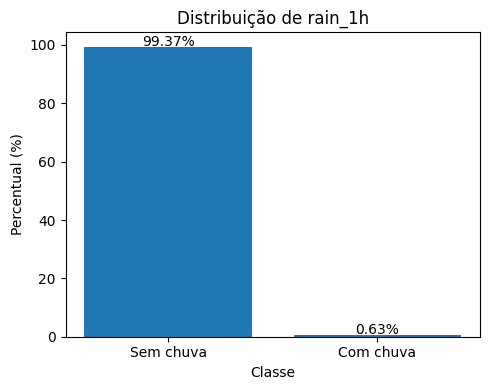

In [ ]:
#binaria
counts = df["rain_1h"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(5,4))
plt.bar(["Sem chuva", "Com chuva"], counts.values)
plt.ylabel("Percentual (%)")
plt.xlabel("Classe")
plt.title("Distribuição de rain_1h")

for i, v in enumerate(counts.values):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("distribuicao_rain_1h.png", dpi=300)
plt.show()

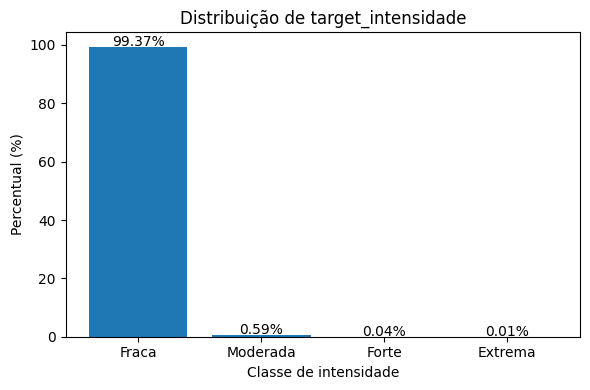

In [ ]:
#intensidade
labels = [
    "Fraca",
    "Moderada",
    "Forte",
    "Extrema"
]

counts = df["target_intensidade"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6,4))
plt.bar(labels, counts.values)
plt.ylabel("Percentual (%)")
plt.xlabel("Classe de intensidade")
plt.title("Distribuição de target_intensidade")

for i, v in enumerate(counts.values):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("distribuicao_target_intensidade.png", dpi=300)
plt.show()

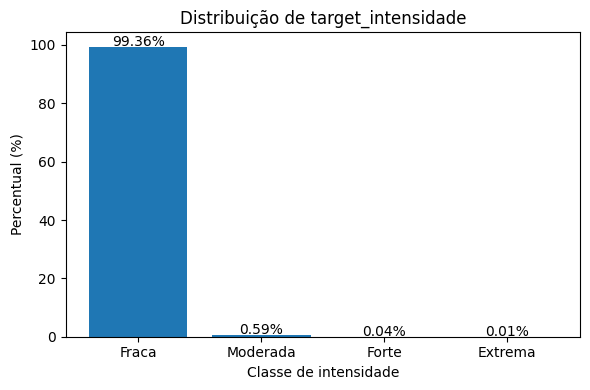

Soma exibida: 100.0


In [ ]:
# intensidade
labels = [
    "Fraca",
    "Moderada",
    "Forte",
    "Extrema"
]

counts = df["target_intensidade"].value_counts(normalize=True).sort_index() * 100

# Arredonda para 2 casas
counts_plot = counts.round(2)

# Corrige diferença causada pelo arredondamento
diff = 100 - counts_plot.sum()

# Aplica a diferença na maior classe
idx_maior = counts_plot.idxmax()
counts_plot.loc[idx_maior] = counts_plot.loc[idx_maior] + diff

plt.figure(figsize=(6,4))
plt.bar(labels, counts_plot.values)

plt.ylabel("Percentual (%)")
plt.xlabel("Classe de intensidade")
plt.title("Distribuição de target_intensidade")

for i, v in enumerate(counts_plot.values):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("distribuicao_target_intensidade.png", dpi=300)
plt.show()

print("Soma exibida:", counts_plot.sum())

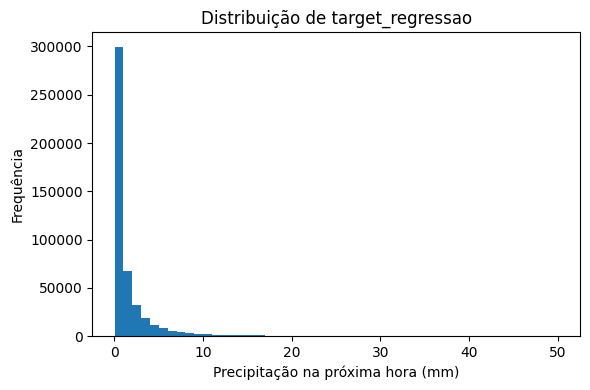

In [ ]:
#regressao
chuva = df[df["target_regressao"] > 0]["target_regressao"]

plt.figure(figsize=(6,4))
plt.hist(chuva[chuva <= 50], bins=50)

plt.xlabel("Precipitação na próxima hora (mm)")
plt.ylabel("Frequência")
plt.title("Distribuição de target_regressao")

plt.tight_layout()
plt.savefig("distribuicao_target_regressao.png", dpi=300)
plt.show()

In [ ]:
limite = df["target_regressao"].quantile(0.9999)

df["target_regressao_clip"] = (
    df["target_regressao"]
    .clip(upper=limite)
)

In [ ]:
#ver questao dos outliers

df.loc[
    df["target_regressao"] > 200,
    [
        "id",
        "observation_datetime",
        "rain_mm",
        "rain_next_1h_mm"
    ]
]

,id,observation_datetime,rain_mm,rain_next_1h_mm


In [ ]:
print((df["target_regressao"] > 100).sum())
print((df["target_regressao"] > 200).sum())

9
0


In [ ]:
data_a = pd.read_parquet("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip")

# print(data_a.columns)
# print(data_a[["rain_mm", "rain_1h", "target_intensidade", "target_regressao"]].head(20))
# print(data_a["target_intensidade"].value_counts().sort_index())

data_a.head(20)

,id,observation_datetime,rain_mm,latitude,longitude,rain_next_1h_mm,rain_1h
0,1,2012-01-01 00:00:00,1.0,-22.8636,-43.2636,0.8,0
1,1,2012-01-01 01:00:00,0.8,-22.8636,-43.2636,0.6,0
2,1,2012-01-01 02:00:00,0.6,-22.8636,-43.2636,0.4,0
3,1,2012-01-01 03:00:00,0.4,-22.8636,-43.2636,0.0,0
4,1,2012-01-01 04:00:00,0.0,-22.8636,-43.2636,0.0,0
5,1,2012-01-01 05:00:00,0.0,-22.8636,-43.2636,0.2,0
6,1,2012-01-01 06:00:00,0.2,-22.8636,-43.2636,0.2,0
7,1,2012-01-01 07:00:00,0.2,-22.8636,-43.2636,0.6,0
8,1,2012-01-01 08:00:00,0.6,-22.8636,-43.2636,0.4,0
9,1,2012-01-01 09:00:00,0.4,-22.8636,-43.2636,0.2,0


In [ ]:
print(data_a["observation_datetime"].min())
print(data_a["observation_datetime"].max())
print(
    data_a["observation_datetime"]
    .drop_duplicates()
    .sort_values()
    .head(20)
)

2012-01-01 00:00:00
2024-11-27 12:00:00
0      2012-01-01 00:00:00
54     2012-01-01 01:00:00
108    2012-01-01 02:00:00
162    2012-01-01 03:00:00
216    2012-01-01 04:00:00
270    2012-01-01 05:00:00
324    2012-01-01 06:00:00
378    2012-01-01 07:00:00
432    2012-01-01 08:00:00
486    2012-01-01 09:00:00
540    2012-01-01 10:00:00
594    2012-01-01 11:00:00
648    2012-01-01 12:00:00
702    2012-01-01 13:00:00
756    2012-01-01 14:00:00
810    2012-01-01 15:00:00
864    2012-01-01 16:00:00
918    2012-01-01 17:00:00
972    2012-01-01 18:00:00
1026   2012-01-01 19:00:00
Name: observation_datetime, dtype: datetime64[ns]


In [ ]:
print(
    data_a[[
        "id",
        "observation_datetime",
        "rain_mm",
        "rain_next_1h_mm",
        "rain_1h"
    ]].head(20)
)

    id observation_datetime  rain_mm  rain_next_1h_mm  rain_1h
0    1           2012-01-01      1.0              0.8        0
1    9           2012-01-01      0.6              0.8        0
2   61           2012-01-01      0.8              1.0        0
3   15           2012-01-01      1.4              0.8        0
4   51           2012-01-01      1.0              1.2        0
5   48           2012-01-01      0.8              0.6        0
6   38           2012-01-01      1.2              1.2        0
7   43           2012-01-01      0.8              1.0        0
8   46           2012-01-01      0.8              0.8        0
9   70           2012-01-01      0.8              0.8        0
10  19           2012-01-01      0.8              0.6        0
11   3           2012-01-01      0.8              0.6        0
12  28           2012-01-01      1.2              0.8        0
13  37           2012-01-01      1.8              1.0        0
14  80           2012-01-01      0.6              0.8  

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)     # Exibe todas as linhas
pd.set_option('display.max_colwidth', None)
data_a = pd.read_parquet("data/datasets/dataset_A_IGRA_NOVAS_COLUNAS.parquet.gzip")

# data_filtered = data_a.loc["2024-01-01":"2025-12-05"]

# # Filtra os registros onde a quantidade de chuva (rain_mm) é maior que 0
rain_filtered = data_a[
    (data_a["rain_mm"] != 0.0) &
    (data_a["id"] == 1) &
    (data_a["observation_datetime"] >= "2024-01-04") &
    (data_a["observation_datetime"] <= "2024-01-05")
].sort_values("observation_datetime")


# # Verifica o total de registros com chuva
# print(f"Total de registros com chuva: {len(rain_filtered)}")

# Mostra as primeiras 10 linhas de dados filtrados
#print(rain_filtered.head(20))


rain_filtered.head(20)

# Se no right (df_igra) existirem múltiplas linhas com o MESMO time, o pandas:
# usa a ÚLTIMA linha válida naquele timestamp
# Isso é comportamento documentado do merge_asof.



# Em cada linha do seu dataset final você tem:
# id
# → identifica qual estação do WebSirene (das 83)

# observation_datetime
# → a hora da observação de chuva daquela estação
# → estrutura do dataset é horária

# rain_mm
# → chuva acumulada naquela hora

# rain_1h
# → rótulo binário (0 / 1)
# → vai chover ou não naquela hora

# Índices atmosféricos (CAPE, CIN, LI, PWAT, etc.)
# → representam o estado da atmosfera associado àquela hora

# A tabela final resultante da integração temporal possui estrutura horária, seguindo as observações de precipitação das estações do WebSirene. Para cada estação e horário, são associados os índices atmosféricos derivados da radiossonda mais recente disponível. Como um mesmo sounding representa as condições atmosféricas por várias horas consecutivas, os valores dos índices atmosféricos se repetem ao longo dessas horas, o que é fisicamente consistente. Esses valores são atualizados apenas quando ocorre um novo lançamento de radiossonda ou quando se excede a janela temporal de tolerância adotada.”

# nessa tabela eu tenho os ids das estaçoes do websirene, as horas de acordo com o websirene para cada estaçao, o rain mm, o rain1h, os indices atmosfericos, eles se repetem pq estao no mesmo horario ou horarios proximos entao se referem ao msm sounding q tem a mesma condiçao aatmosferica, isso iria mudar depois de 12h por exemplo

,id,observation_datetime,rain_mm,rain_next_1h_mm,rain_1h,cape,cin,lifted_index,lcl_height,pwat,freezing_level,shear_0_3km,shear_0_6km,rh_850,rh_700,rh_500,target_intensidade,target_regressao
8607494,1,2024-01-04 00:00:00,3.2,5.4,1,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,1,5.4
8607540,1,2024-01-04 01:00:00,5.4,7.0,1,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,1,7.0
8607663,1,2024-01-04 02:00:00,7.0,4.4,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,4.4
8607772,1,2024-01-04 03:00:00,4.4,1.8,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,1.8
8607785,1,2024-01-04 04:00:00,1.8,1.6,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,1.6
8607900,1,2024-01-04 05:00:00,1.6,0.6,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,0.6
8608009,1,2024-01-04 06:00:00,0.6,0.2,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,0.2
8608103,1,2024-01-04 07:00:00,0.2,2.0,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,2.0
8608143,1,2024-01-04 08:00:00,2.0,4.0,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,4.0
8608259,1,2024-01-04 09:00:00,4.0,2.6,0,633.272696,-48.967911,-3.411534,0.369787,66.819097,4831.624161,0.0,0.0,94.493105,97.997281,94.795465,0,2.6


In [ ]:

df_no_rain = data_a[data_a["rain_1h"] == 0]
df_rain    = data_a[data_a["rain_1h"] == 1]

df_no_rain["cape"].describe()



,cape
count,8.417732e+06
mean,3.744284e+02
std,5.825860e+02
min,-3.885888e+02
25%,0.000000e+00
50%,6.113244e+01
75%,5.696387e+02
max,4.613194e+03


In [ ]:
df_rain["lifted_index"].describe()


,lifted_index
count,38456.000000
mean,-1.496382
std,2.425686
min,-8.719904
25%,-3.250639
50%,-1.815914
75%,-0.076695
max,11.763012


In [ ]:
!pip install seaborn


In [ ]:
df.columns

Index(['id', 'nome', 'type', 'latitude', 'longitude', 'rains', 'm5', 'm15',
       'h01', 'h04', 'h24', 'h96', 'mes', 'observation_datetime',
       'request_datetime', 'year'],
      dtype='object')

In [ ]:
print(data_a.head())

   id observation_datetime  rain_mm  rain_1h        cape        cin  \
0   1           2012-01-01      1.0        0  894.731908 -40.446386   
1   9           2012-01-01      0.6        0  894.731908 -40.446386   
2  61           2012-01-01      0.8        0  894.731908 -40.446386   
3  15           2012-01-01      1.4        0  894.731908 -40.446386   
4  51           2012-01-01      1.0        0  894.731908 -40.446386   

   lifted_index  lcl_height       pwat  freezing_level  shear_0_3km  \
0     -2.785464    0.529274  56.769913     4664.051724          0.0   
1     -2.785464    0.529274  56.769913     4664.051724          0.0   
2     -2.785464    0.529274  56.769913     4664.051724          0.0   
3     -2.785464    0.529274  56.769913     4664.051724          0.0   
4     -2.785464    0.529274  56.769913     4664.051724          0.0   

   shear_0_6km     rh_850     rh_700     rh_500  
0          0.0  80.565186  78.034057  96.980708  
1          0.0  80.565186  78.034057  96.98070

In [ ]:
#Exibir apenas algumas colunas
columns_to_show = ["id", "observation_datetime", "rain_mm", "rain_1h", "pressure", "pressure_diff"]
print(data_a[columns_to_show].head(50))
print(data_a[columns_to_show].tail())

print(data_a.head())

KeyError: "['pressure', 'pressure_diff'] not in index"

In [ ]:
# data_a_clean = data_a.dropna()

# y = data_a_clean["rain_1h"]

# X = data_a_clean.drop(columns=[
#     "rain_1h",
#     "rain_mm",
#     "rain_now"
# ])

# print(X.shape)
# print(y.shape)


(7534, 11)
(7534,)


### Separando X e y

In [ ]:
import pandas as pd

df = pd.read_parquet("data/datasets/dataset_A_IGRA_NOVAS_COLUNAS.parquet.gzip")

y_binario = df["rain_1h"]
y_intensidade = df["target_intensidade"]
y_regressao = df["target_regressao"]

#usa só as outras colunas como entrada
X_radio = df.drop(columns=[
    "id",
    "rain_1h",
    "rain_next_1h_mm",
    "observation_datetime",
    "target_intensidade",
    "target_regressao",
    "rain_mm"
])

print(X_radio.head())

         cape        cin  lifted_index  lcl_height       pwat  freezing_level  \
0  894.731908 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
1  894.731908 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
2  894.731908 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
3  894.731908 -40.446386     -2.785464    0.529274  56.769913     4664.051724   
4  894.731908 -40.446386     -2.785464    0.529274  56.769913     4664.051724   

   shear_0_3km  shear_0_6km     rh_850     rh_700     rh_500  
0          0.0          0.0  80.565186  78.034057  96.980708  
1          0.0          0.0  80.565186  78.034057  96.980708  
2          0.0          0.0  80.565186  78.034057  96.980708  
3          0.0          0.0  80.565186  78.034057  96.980708  
4          0.0          0.0  80.565186  78.034057  96.980708  


## Formando o vetor final de entrada IGRA

### Dividindo treino, validação e teste

In [ ]:
df["observation_datetime"].min(), df["observation_datetime"].max()


(Timestamp('2012-01-01 00:00:00'), Timestamp('2024-11-27 12:00:00'))

In [ ]:
# split_date = "2022-01-01"

# X_train = X_radio[df["observation_datetime"] < split_date]
# y_train = y[df["observation_datetime"] < split_date]

# X_test = X_radio[df["observation_datetime"] >= split_date]
# y_test = y[df["observation_datetime"] >= split_date]

# print("X_train:", X_train.shape)
# print("y_train:", y_train.shape)

# print("X_test:", X_test.shape)
# print("y_test:", y_test.shape)

# print(df.loc[X_train.index, "observation_datetime"].min(),
#       df.loc[X_train.index, "observation_datetime"].max())

# print(df.loc[X_test.index, "observation_datetime"].min(),
#       df.loc[X_test.index, "observation_datetime"].max())



#INCLUINDO OS DADOS DE VALIDAÇAO

#y = y_binario
y = y_intensidade
#y = y_regressao

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = df["observation_datetime"] < train_end
mask_val = (df["observation_datetime"] >= train_end) & (df["observation_datetime"] < val_end)
mask_test = df["observation_datetime"] >= val_end

X_train = X_radio[mask_train]
y_train = y[mask_train]

X_val = X_radio[mask_val]
y_val = y[mask_val]

X_test = X_radio[mask_test]
y_test = y[mask_test]



## Treinando o modelo Random Forest e CatBoost

### Hiperparâmetros iniciais

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss
)


In [ ]:

# rf_radio = RandomForestClassifier(
#     n_estimators=200,
#     random_state=42,
#     class_weight="balanced",
#     n_jobs=-1
# )

# rf_radio.fit(X_train, y_train)
from sklearn.model_selection import train_test_split

#binario
# rf_radio = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=15,
#     min_samples_leaf=20,
#     random_state=42,
#     class_weight="balanced",
#     n_jobs=4
# )

rf_radio = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    #class_weight="balanced_subsample",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)



### Avaliando o modelo (Só radiossonda)

#### Vendo os melhores hiperparametros com dados de validaçao

In [ ]:
from sklearn.metrics import average_precision_score

# Treinar (binário)
rf_radio.fit(X_train, y_train)

# Probabilidades
y_val_prob = rf_radio.predict_proba(X_val)[:, 1]

# Decisão com threshold ajustado
y_val_pred = (y_val_prob >= 0.5).astype(int)


# Avaliação na validação
print(classification_report(y_val, y_val_pred))

print("AUC VAL:", roc_auc_score(y_val, y_val_prob))
print("Brier VAL:", brier_score_loss(y_val, y_val_prob))

print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)



              precision    recall  f1-score   support

           0       0.99      0.86      0.92    958762
           1       0.01      0.32      0.03      6304

    accuracy                           0.85    965066
   macro avg       0.50      0.59      0.47    965066
weighted avg       0.99      0.85      0.91    965066

AUC VAL: 0.7213245641498903
Brier VAL: 0.10485036663085022
PR AUC: 0.015148173957525015


#### Treinando de fato com dados de teste

In [ ]:
best_threshold = 0.5

y_test_prob = rf_radio.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred))

print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92    945723
           1       0.03      0.52      0.05      7440

    accuracy                           0.86    953163
   macro avg       0.51      0.69      0.49    953163
weighted avg       0.99      0.86      0.91    953163

AUC TEST: 0.7956913911679951
Brier TEST: 0.09926343277661848


In [ ]:
print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)

PR AUC: 0.11091537878059476


PR AUC: 0.030665456696160148


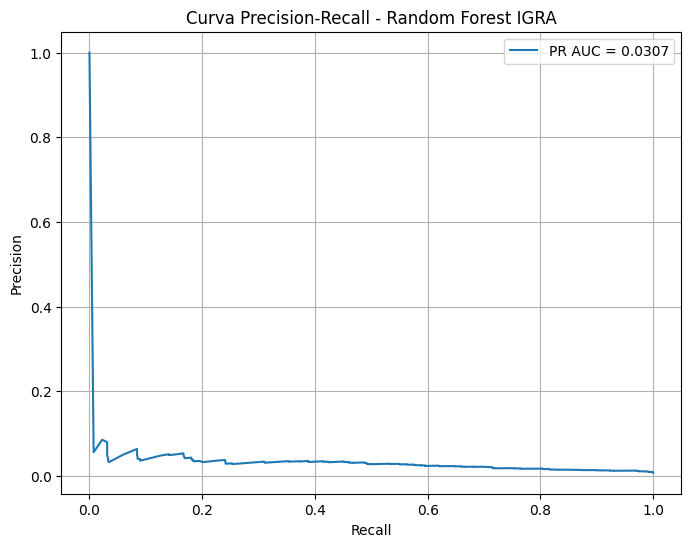

In [ ]:

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

# PR AUC / Average Precision
pr_auc = average_precision_score(y_test, y_test_prob)

print("PR AUC:", pr_auc)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Random Forest IGRA")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Treinar (multiclasse)
rf_radio.fit(X_train, y_train)

# Probabilidades na validação
y_val_prob = rf_radio.predict_proba(X_val)

# Predição na validação
y_val_pred = rf_radio.predict(X_val)

# Avaliação na validação
print("=== VALIDAÇÃO ===")
print(classification_report(y_val, y_val_pred, zero_division=0))

print(
    "AUC VAL:",
    roc_auc_score(
        y_val,
        y_val_prob,
        multi_class="ovr",
        average="macro"
    )
)

=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       0.99      0.90      0.95    956506
           1       0.01      0.22      0.03      5867
           2       0.00      0.00      0.00       394
           3       0.00      0.00      0.00        27

    accuracy                           0.90    962794
   macro avg       0.25      0.28      0.24    962794
weighted avg       0.99      0.90      0.94    962794

AUC VAL: 0.7621991515283487


In [ ]:
y_test_prob = rf_radio.predict_proba(X_test)
y_test_pred = rf_radio.predict(X_test)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))

print(
    "AUC TEST:",
    roc_auc_score(
        y_test,
        y_test_prob,
        multi_class="ovr",
        average="macro"
    )
)

=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    942439
           1       0.03      0.38      0.05      6804
           2       0.00      0.00      0.00       510
           3       0.00      0.00      0.00       104

    accuracy                           0.88    949857
   macro avg       0.25      0.32      0.25    949857
weighted avg       0.99      0.88      0.93    949857

AUC TEST: 0.8137323331281302


In [ ]:
print(X_train.shape)

(5811476, 11)


In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# treino
rf_reg.fit(X_train, y_train)

# previsão na validação
y_val_pred = rf_reg.predict(X_val)

# métricas validação
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

=== VALIDAÇÃO ===
MAE: 0.2901404831317519
RMSE: 1.2214853905491372
R²: -0.021464163598445607


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred = rf_reg.predict(X_test)

# métricas TESTE
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)

=== TESTE FINAL ===
MAE TEST: 0.311375896865488
RMSE TEST: 1.435097946543571
R² TEST: -0.00824135832896089


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calcula ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.2f})")

# Linha do acaso
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--",
         label="Classificador aleatório")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Modelo IGRA")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Salvar
plt.tight_layout()
plt.savefig("roc_igra.png", dpi=300)
plt.show()


NameError: name 'y_prob' is not defined

### CatBoost

In [ ]:
#INCLUINDO OS DADOS DE VALIDAÇAO

#y = y_binario
y = y_intensidade
#y = y_regressao

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = df["observation_datetime"] < train_end
mask_val = (df["observation_datetime"] >= train_end) & (df["observation_datetime"] < val_end)
mask_test = df["observation_datetime"] >= val_end

X_train = X_radio[mask_train]
y_train = y[mask_train]

X_val = X_radio[mask_val]
y_val = y[mask_val]

X_test = X_radio[mask_test]
y_test = y[mask_test]


In [ ]:
#CatBoost (binário)
#posso rodar varias vezes esse
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, average_precision_score

model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    # auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(X_train, y_train, eval_set=(X_val, y_val))



0:	test: 0.7083820	best: 0.7083820 (0)	total: 1.6s	remaining: 5m 17s
50:	test: 0.7168730	best: 0.7214313 (3)	total: 1m 15s	remaining: 3m 40s
100:	test: 0.7173438	best: 0.7214313 (3)	total: 2m 19s	remaining: 2m 16s
150:	test: 0.7136730	best: 0.7214313 (3)	total: 3m 23s	remaining: 1m 5s
199:	test: 0.7107789	best: 0.7214313 (3)	total: 4m 28s	remaining: 0us

bestTest = 0.7214313267
bestIteration = 3

Shrink model to first 4 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=200, learning_rate=0.03, loss_function='Logloss', random_seed=42, scale_pos_weight=70, verbose=50)

In [ ]:
# validação
prob_val = model.predict_proba(X_val)[:, 1]

threshold = 0.5
pred_val = (prob_val >= threshold).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val, pred_val))
print("AUC VAL:", roc_auc_score(y_val, prob_val))
print("Brier VAL:", brier_score_loss(y_val, prob_val))
print("PR AUC VAL:", average_precision_score(y_val, prob_val))

=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       0.99      0.86      0.93    958762
           1       0.02      0.34      0.03      6304

    accuracy                           0.86    965066
   macro avg       0.51      0.60      0.48    965066
weighted avg       0.99      0.86      0.92    965066

AUC VAL: 0.7214313266737371
Brier VAL: 0.20962109995905512
PR AUC VAL: 0.013679077741245067


In [ ]:
prob_test = model.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, pred_test))
print("AUC TEST:", roc_auc_score(y_test, prob_test))
print("Brier TEST:", brier_score_loss(y_test, prob_test))
print("PR AUC TEST:", average_precision_score(y_test, prob_test))


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    945723
           1       0.03      0.47      0.05      7440

    accuracy                           0.87    953163
   macro avg       0.51      0.67      0.49    953163
weighted avg       0.99      0.87      0.92    953163

AUC TEST: 0.7976692411150555
Brier TEST: 0.20836978437245587
PR AUC TEST: 0.03542143285863393


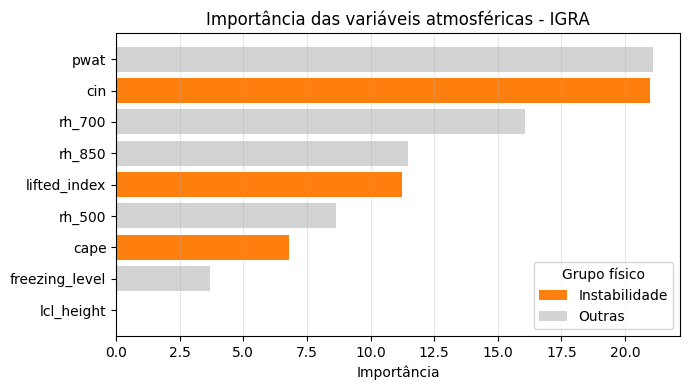

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

importances = model.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

category = {
    "cape": "Instabilidade",
    "cin": "Instabilidade",
    "lifted_index": "Instabilidade",
    "lcl_height": "Instabilidade",

    "pwat": "Outras",
    "rh_850": "Outras",
    "rh_700": "Outras",
    "rh_500": "Outras",
    "freezing_level": "Outras",
    "shear_0_3km": "Outras",
    "shear_0_6km": "Outras",
}

colors = {
    "Instabilidade": "tab:orange",
    "Outras": "lightgray",
}

df_importance["categoria"] = (
    df_importance["feature"]
    .map(category)
    .fillna("Outras")
)

top_n = 9
df_top = df_importance.head(top_n)

plt.figure(figsize=(7, 4))

plt.barh(
    df_top["feature"],
    df_top["importance"],
    color=df_top["categoria"].map(colors)
)

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.title("Importância das variáveis atmosféricas - IGRA")
plt.grid(axis="x", alpha=0.3)

legend_elements = [
    Patch(facecolor=colors["Instabilidade"], label="Instabilidade"),
    Patch(facecolor=colors["Outras"], label="Outras")
]

plt.legend(
    handles=legend_elements,
    title="Grupo físico",
    loc="lower right"
)

plt.tight_layout()
plt.savefig("importance_igra_catboost_categorias.png", dpi=300)
plt.show()

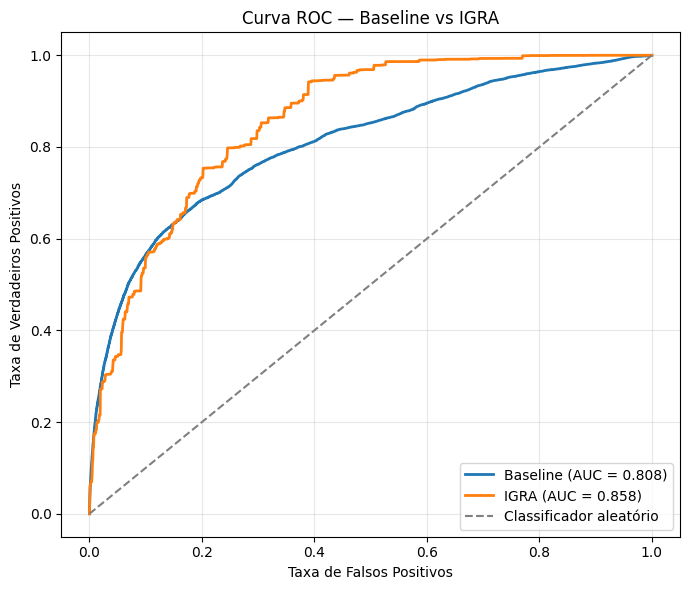

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Baseline
fpr_base, tpr_base, _ = roc_curve(
    y_test_baseline,
    prob_test_baseline
)
auc_base = auc(fpr_base, tpr_base)

# IGRA
fpr_igra, tpr_igra, _ = roc_curve(
    y_test,
    prob_test
)
auc_igra = auc(fpr_igra, tpr_igra)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_base,
    tpr_base,
    lw=2,
    label=f"Baseline (AUC = {auc_base:.3f})"
)

plt.plot(
    fpr_igra,
    tpr_igra,
    lw=2,
    label=f"IGRA (AUC = {auc_igra:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Baseline vs IGRA")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_baseline_vs_igra.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#CatBoost (multiclasse)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=200,
    depth=6,
    learning_rate=0.03,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred = model.predict(X_test).ravel()
y_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))



0:	learn: 0.4989574	test: 0.3620536	best: 0.3620536 (0)	total: 5.06s	remaining: 16m 47s
50:	learn: 0.6326786	test: 0.3970084	best: 0.4021250 (48)	total: 2m 18s	remaining: 6m 43s
100:	learn: 0.6554811	test: 0.3154572	best: 0.4021250 (48)	total: 4m 28s	remaining: 4m 23s
150:	learn: 0.6740437	test: 0.2779927	best: 0.4021250 (48)	total: 6m 31s	remaining: 2m 7s
199:	learn: 0.6819443	test: 0.2812233	best: 0.4021250 (48)	total: 8m 32s	remaining: 0us

bestTest = 0.4021250141
bestIteration = 48

Shrink model to first 49 iterations.
              precision    recall  f1-score   support

           0       1.00      0.63      0.77    942439
           1       0.02      0.56      0.04      6804
           2       0.00      0.45      0.00       510
           3       0.00      0.06      0.00       104

    accuracy                           0.63    949857
   macro avg       0.25      0.42      0.20    949857
weighted avg       0.99      0.63      0.76    949857



In [ ]:
from sklearn.metrics import f1_score, recall_score
print("F1 Macro:",
      f1_score(y_test, y_pred, average="macro"))

print("Recall Macro:",
      recall_score(y_test, y_pred, average="macro"))

print("AUC:",
      roc_auc_score(
          y_test,
          y_prob,
          multi_class="ovr",
          average="macro"
      ))

F1 Macro: 0.2027893879794698
Recall Macro: 0.4236559375776596
AUC: 0.8336409325596179


In [ ]:
#CatBoost (regressao)
from catboost import CatBoostRegressor
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# treino + validação
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred = model.predict(X_val)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)

mae_val = mean_absolute_error(
    y_val,
    y_val_pred
)

r2_val = r2_score(
    y_val,
    y_val_pred
)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)

0:	learn: 1.2022618	test: 1.2085753	best: 1.2085753 (0)	total: 470ms	remaining: 1m 10s
50:	learn: 1.1940391	test: 1.2043655	best: 1.2043655 (50)	total: 28.8s	remaining: 55.8s
100:	learn: 1.1890856	test: 1.2035748	best: 1.2034879 (94)	total: 57.1s	remaining: 27.7s
149:	learn: 1.1859600	test: 1.2038154	best: 1.2034879 (94)	total: 1m 27s	remaining: 0us

bestTest = 1.203487868
bestIteration = 94

Shrink model to first 95 iterations.
=== VALIDAÇÃO ===
RMSE VAL: 1.2034878683975896
MAE VAL: 0.27372677039192533
R² VAL: 0.008414849682952696


In [ ]:
# =========================================
# TESTE FINAL
# =========================================

y_test_pred = model.predict(X_test)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

mae_test = mean_absolute_error(
    y_test,
    y_test_pred
)

r2_test = r2_score(
    y_test,
    y_test_pred
)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)

=== TESTE FINAL ===
RMSE TEST: 1.417057532545101
MAE TEST: 0.2854745444520773
R² TEST: 0.016948232814130715


### Experimentos de ablaçao

### Modelo com os 2 (IGRA + WEBSIRENE)

In [ ]:
!python src/sounding/dataset_D.py

^C


In [ ]:
import pandas as pd

df_d = pd.read_parquet("data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip")

surface_cols = ["id", "observation_datetime", "h04", "h24", "h96", "latitude", "longitude", "mes"]
surface_feat = df_d[surface_cols].copy()


In [ ]:
df_b = pd.read_parquet("data/datasets/dataset_A_IGRA_NOVAS_COLUNAS.parquet.gzip")

# garantir que datetime é igual (sem tz)
df_b["observation_datetime"] = pd.to_datetime(df_b["observation_datetime"]).dt.tz_localize(None)
surface_feat["observation_datetime"] = pd.to_datetime(surface_feat["observation_datetime"]).dt.tz_localize(None)

df_int = pd.merge(
    df_b,
    surface_feat,
    on=["id", "observation_datetime"],
    how="inner"
)
print(df_int.shape)
print(df_int.columns)


(5839210, 24)
Index(['id', 'observation_datetime', 'rain_mm', 'rain_next_1h_mm', 'rain_1h',
       'cape', 'cin', 'lifted_index', 'lcl_height', 'pwat', 'freezing_level',
       'shear_0_3km', 'shear_0_6km', 'rh_850', 'rh_700', 'rh_500',
       'target_intensidade', 'target_regressao', 'h04', 'h24', 'h96',
       'latitude', 'longitude', 'mes'],
      dtype='object')


In [ ]:
y_binario = df_int["rain_1h"]
y_intensidade = df_int["target_intensidade"]
y_regressao = df_int["target_regressao"]

X = df_int.drop(columns=[
    "id",
    "rain_1h",
    "rain_next_1h_mm",
    "observation_datetime",
    "target_intensidade",
    "target_regressao",
    "latitude",
    "longitude"
])

print(X.head())


   rain_mm        cape        cin  lifted_index  lcl_height       pwat  \
0      0.0  242.940177 -83.185498     -1.931001    0.629153  39.170849   
1      0.0  242.940177 -83.185498     -1.931001    0.629153  39.170849   
2      0.0  242.940177 -83.185498     -1.931001    0.629153  39.170849   
3      0.0  242.940177 -83.185498     -1.931001    0.629153  39.170849   
4      0.0  242.940177 -83.185498     -1.931001    0.629153  39.170849   

   freezing_level  shear_0_3km  shear_0_6km    rh_850     rh_700     rh_500  \
0     4373.907186          0.0          0.0  55.29673  61.125243  86.041689   
1     4373.907186          0.0          0.0  55.29673  61.125243  86.041689   
2     4373.907186          0.0          0.0  55.29673  61.125243  86.041689   
3     4373.907186          0.0          0.0  55.29673  61.125243  86.041689   
4     4373.907186          0.0          0.0  55.29673  61.125243  86.041689   

   h04  h24  h96  mes  
0  0.0  0.0  0.0    1  
1  0.0  0.0  0.0    1  
2  0.0  

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import pandas as pd


#y = y_binario
y = y_intensidade
#y = y_regressao

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = df_int["observation_datetime"] < train_end
mask_val = (df_int["observation_datetime"] >= train_end) & (df_int["observation_datetime"] < val_end)
mask_test = df_int["observation_datetime"] >= val_end

X_train = X[mask_train]
y_train = y[mask_train]

X_val = X[mask_val]
y_val = y[mask_val]

X_test = X[mask_test]
y_test = y[mask_test]


print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)



Treino: (3996751, 16) (3996751,)
Validação: (935142, 16) (935142,)
Teste: (907317, 16) (907317,)


In [ ]:
#random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss


rf_int = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)



In [ ]:

from sklearn.metrics import average_precision_score

# Treinar (binário)
rf_int.fit(X_train, y_train)

# Probabilidades
y_val_prob = rf_int.predict_proba(X_val)[:, 1]

# Decisão com threshold ajustado
y_val_pred = (y_val_prob >= 0.5).astype(int)

# Avaliação na validação
print("=== INTEGRADO (IGRA + SUPERFÍCIE) ===")
print(classification_report(y_val, y_val_pred))

print("AUC VAL:", roc_auc_score(y_val, y_val_prob))
print("Brier VAL:", brier_score_loss(y_val, y_val_prob))

print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)


=== INTEGRADO (IGRA + SUPERFÍCIE) ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    929083
           1       0.06      0.70      0.11      6059

    accuracy                           0.93    935142
   macro avg       0.53      0.81      0.54    935142
weighted avg       0.99      0.93      0.96    935142

AUC VAL: 0.9082278469539039
Brier VAL: 0.06933934002541955
PR AUC: 0.11068531576033347


In [ ]:
best_threshold = 0.5

y_test_prob = rf_int.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred))

print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)


              precision    recall  f1-score   support

           0       1.00      0.93      0.96    900264
           1       0.07      0.75      0.14      7053

    accuracy                           0.93    907317
   macro avg       0.54      0.84      0.55    907317
weighted avg       0.99      0.93      0.95    907317

AUC TEST: 0.9230322970913991
Brier TEST: 0.07032593141334753
PR AUC: 0.11068531576033347


In [ ]:
# Treinar (multiclasse)
rf_int.fit(X_train, y_train)

# Probabilidades na validação
y_val_prob = rf_int.predict_proba(X_val)

# Predição na validação
y_val_pred = rf_int.predict(X_val)

# Avaliação na validação
print("=== VALIDAÇÃO ===")
print(classification_report(y_val, y_val_pred, zero_division=0))

print(
    "AUC VAL:",
    roc_auc_score(
        y_val,
        y_val_prob,
        multi_class="ovr",
        average="macro"
    )
)


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    929083
           1       0.06      0.73      0.11      5653
           2       0.00      0.00      0.00       380
           3       0.00      0.00      0.00        26

    accuracy                           0.93    935142
   macro avg       0.26      0.42      0.27    935142
weighted avg       0.99      0.93      0.96    935142

AUC VAL: 0.8781957771641988


In [ ]:
y_test_prob = rf_int.predict_proba(X_test)
y_test_pred = rf_int.predict(X_test)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))

print(
    "AUC TEST:",
    roc_auc_score(
        y_test,
        y_test_prob,
        multi_class="ovr",
        average="macro"
    )
)


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    900264
           1       0.08      0.73      0.14      6469
           2       0.00      0.02      0.01       486
           3       0.00      0.00      0.00        98

    accuracy                           0.93    907317
   macro avg       0.27      0.42      0.28    907317
weighted avg       0.99      0.93      0.96    907317

AUC TEST: 0.9157062097714852


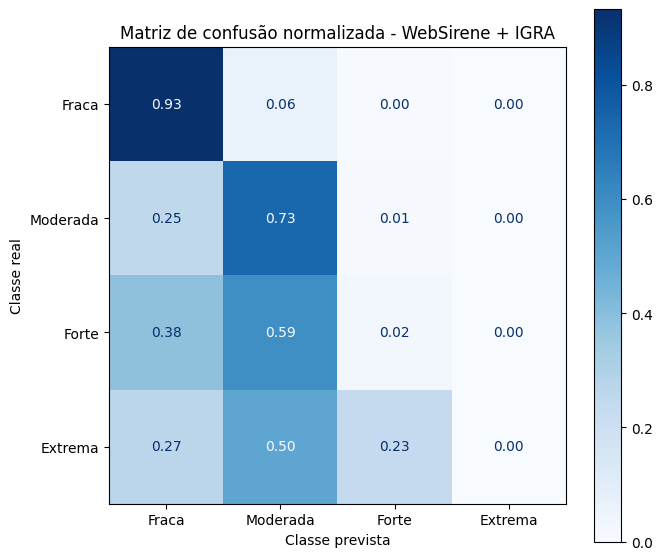

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# y_test_multiclass = valores reais
# y_pred_multiclass = previsões do modelo Random Forest + UOW

labels = [0, 1, 2, 3]

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=labels,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fraca", "Moderada", "Forte", "Extrema"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(
    ax=ax,
    values_format=".2f",
    cmap="Blues",
    colorbar=True
)

plt.title("Matriz de confusão normalizada - WebSirene + IGRA")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.savefig("matriz_confusao_rf_websirene+igra_multiclasse.png", dpi=300)
plt.show()

In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1

)

# treino
rf_reg.fit(X_train, y_train)

# previsão na validação
y_val_pred = rf_reg.predict(X_val)

# métricas validação
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)



=== VALIDAÇÃO ===
MAE: 0.19778532902167373
RMSE: 1.0894522617193096
R²: 0.18134609901242582


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred = rf_reg.predict(X_test)

# métricas TESTE
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
MAE TEST: 0.20897942489168822
RMSE TEST: 1.2981506676818324
R² TEST: 0.17002453315874388


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import pandas as pd


#y = y_binario
y = y_intensidade
#y = y_regressao

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = df_int["observation_datetime"] < train_end
mask_val = (df_int["observation_datetime"] >= train_end) & (df_int["observation_datetime"] < val_end)
mask_test = df_int["observation_datetime"] >= val_end

X_train = X[mask_train]
y_train = y[mask_train]

X_val = X[mask_val]
y_val = y[mask_val]

X_test = X[mask_test]
y_test = y[mask_test]


print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (3996751, 16) (3996751,)
Validação: (935142, 16) (935142,)
Teste: (907317, 16) (907317,)


In [ ]:
#CatBoost

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    # auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)



0:	test: 0.8919544	best: 0.8919544 (0)	total: 1.26s	remaining: 4m 10s
50:	test: 0.9118962	best: 0.9127538 (31)	total: 1m 2s	remaining: 3m 2s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.9127538384
bestIteration = 31

Shrink model to first 32 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=200, learning_rate=0.03, loss_function='Logloss', random_seed=42, scale_pos_weight=70, verbose=50)

In [ ]:
# validação
prob_val = model.predict_proba(X_val)[:, 1]

threshold = 0.5
pred_val = (prob_val >= threshold).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val, pred_val))
print("AUC VAL:", roc_auc_score(y_val, prob_val))
print("Brier VAL:", brier_score_loss(y_val, prob_val))
print("PR AUC VAL:", average_precision_score(y_val, prob_val))


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    929083
           1       0.08      0.72      0.14      6059

    accuracy                           0.94    935142
   macro avg       0.54      0.83      0.55    935142
weighted avg       0.99      0.94      0.96    935142

AUC VAL: 0.9127538383919684
Brier VAL: 0.07198094521844119
PR AUC VAL: 0.15622324036913954


In [ ]:
prob_test = model.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, pred_test))
print("AUC TEST:", roc_auc_score(y_test, prob_test))
print("Brier TEST:", brier_score_loss(y_test, prob_test))
print("PR AUC TEST:", average_precision_score(y_test, prob_test))


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    900264
           1       0.10      0.75      0.17      7053

    accuracy                           0.94    907317
   macro avg       0.55      0.85      0.57    907317
weighted avg       0.99      0.94      0.97    907317

AUC TEST: 0.9256972613080363
Brier TEST: 0.07070606682227397
PR AUC TEST: 0.2291211476896366


In [ ]:
#CatBoost (multiclasse)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=150,
    depth=6,
    learning_rate=0.03,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)


model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred = model.predict(X_test).ravel()
y_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))

print(
    "AUC:",
    roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr"
    )
)


0:	learn: 0.5418375	test: 0.3520293	best: 0.3520293 (0)	total: 4.21s	remaining: 10m 27s
50:	learn: 0.6726847	test: 0.4169626	best: 0.4376964 (6)	total: 2m 47s	remaining: 5m 24s
100:	learn: 0.7051636	test: 0.3767852	best: 0.4376964 (6)	total: 5m 30s	remaining: 2m 40s
149:	learn: 0.7223257	test: 0.3789466	best: 0.4376964 (6)	total: 8m 33s	remaining: 0us

bestTest = 0.4376963784
bestIteration = 6

Shrink model to first 7 iterations.
              precision    recall  f1-score   support

           0       1.00      0.77      0.87    900264
           1       0.06      0.49      0.11      6469
           2       0.00      0.42      0.01       486
           3       0.00      0.46      0.00        98

    accuracy                           0.77    907317
   macro avg       0.27      0.53      0.25    907317
weighted avg       0.99      0.77      0.86    907317

AUC: 0.8980087770929948


In [ ]:
#CatBoost (regressao)
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# treino + validação
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred = model.predict(X_val)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)

mae_val = mean_absolute_error(
    y_val,
    y_val_pred
)

r2_val = r2_score(
    y_val,
    y_val_pred
)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)


0:	learn: 1.1984871	test: 1.2021531	best: 1.2021531 (0)	total: 814ms	remaining: 2m 1s
50:	learn: 1.1415073	test: 1.1330151	best: 1.1330151 (50)	total: 30s	remaining: 58.1s
100:	learn: 1.1172417	test: 1.1044881	best: 1.1044881 (100)	total: 57.9s	remaining: 28.1s
149:	learn: 1.1059471	test: 1.0931016	best: 1.0931016 (149)	total: 1m 24s	remaining: 0us

bestTest = 1.093101598
bestIteration = 149

=== VALIDAÇÃO ===
RMSE VAL: 1.093101598574339
MAE VAL: 0.20640201739480774
R² VAL: 0.17585242546020297


In [ ]:
# =========================================
# TESTE FINAL
# =========================================

y_test_pred = model.predict(X_test)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

mae_test = mean_absolute_error(
    y_test,
    y_test_pred
)

r2_test = r2_score(
    y_test,
    y_test_pred
)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
RMSE TEST: 1.2956263019006706
MAE TEST: 0.21302649152224973
R² TEST: 0.17324931223662654


### Comparaçao direta ablaçao

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, brier_score_loss
import pandas as pd

f1_chuva_surface  = f1_score(y_test, y_pred_surface, pos_label=1)
f1_chuva_radio    = f1_score(y_test, y_pred_radio, pos_label=1)
f1_chuva_combined = f1_score(y_test, y_pred_combined, pos_label=1)

f1_macro_surface  = f1_score(y_test, y_pred_surface, average="macro")
f1_macro_radio    = f1_score(y_test, y_pred_radio, average="macro")
f1_macro_combined = f1_score(y_test, y_pred_combined, average="macro")

results = pd.DataFrame({
    "Modelo": ["Superfície", "Radiossonda (IGRA)", "Integrado"],
    "F1 Chuva": [f1_chuva_surface, f1_chuva_radio, f1_chuva_combined],
    "F1 Macro": [f1_macro_surface, f1_macro_radio, f1_macro_combined],
    "AUC": [
        roc_auc_score(y_test, y_prob_surface),
        roc_auc_score(y_test, y_prob_radio),
        roc_auc_score(y_test, y_prob_combined),
    ],
    "Brier": [
        brier_score_loss(y_test, y_prob_surface),
        brier_score_loss(y_test, y_prob_radio),
        brier_score_loss(y_test, y_prob_combined),
    ]
})

results

NameError: name 'y_pred_surface' is not defined

### Quantificação do ganho proporcionado pela integração

In [ ]:
ganho_auc = results.loc[results["Modelo"] == "Integrado", "AUC"].values[0] - \
            results.loc[results["Modelo"] == "Superfície", "AUC"].values[0]

ganho_f1 = results.loc[results["Modelo"] == "Integrado", "F1 (chuva)"].values[0] - \
           results.loc[results["Modelo"] == "Superfície", "F1 (chuva)"].values[0]

ganho_brier = results.loc[results["Modelo"] == "Superfície", "Brier"].values[0] - \
              results.loc[results["Modelo"] == "Integrado", "Brier"].values[0]

print("\nGanho da Integração (Superfície + Radiossonda) sobre Superfície:")
print(f"Ganho AUC: {ganho_auc:.4f}")
print(f"Ganho F1 (chuva): {ganho_f1:.4f}")
print(f"Ganho Brier: {ganho_brier:.4f}")



Ganho da Integração (Superfície + Radiossonda) sobre Superfície:
Ganho AUC: -0.1297
Ganho F1 (chuva): 0.0000
Ganho Brier: 0.0649


# UOW

In [ ]:
#   UOW

import pandas as pd

uow = pd.read_parquet(
    "./data/as/UOW_full_INDICES.parquet.gzip"
)

print("Colunas do UOW:", uow.columns.tolist())
print("UOW time min:", pd.to_datetime(uow["time"]).min())
print("UOW time max:", pd.to_datetime(uow["time"]).max())

print(uow.head(10))

KeyboardInterrupt: 

In [ ]:
!python src/sounding/dataset_B.py

WebSirene: (9995870, 6)
Columns WS: ['index', 'id', 'observation_datetime', 'rain_mm', 'rain_next_1h_mm', 'rain_1h']
UOW: (647257, 26)
Columns UOW: ['pressure', 'height', 'temperature', 'dewpoint', 'direction', 'speed', 'u_wind', 'v_wind', 'station', 'station_number', 'time', 'latitude', 'longitude', 'elevation', 'pw', 'cape', 'cin', 'lifted_index', 'lcl_height', 'pwat', 'freezing_level', 'shear_0_3km', 'shear_0_6km', 'rh_850', 'rh_700', 'rh_500']
Merged: (8307053, 32)
Dataset final UOW: (8254584, 18)
Saved to: data/datasets/dataset_B_UOW_NOVAS_COLUNAS.parquet.gzip
Final shape: (8254584, 18)


In [ ]:
import pandas as pd
data_b = pd.read_parquet("data/datasets/dataset_B_UOW_NOVAS_COLUNAS.parquet.gzip")


# Mostra as primeiras 10 linhas de dados filtrados
print(data_b.head(10))





   id observation_datetime  rain_mm  rain_next_1h_mm  rain_1h        cape  \
0   1           2012-01-01      1.0              0.8        0  867.195722   
1  44           2012-01-01      1.2              0.8        0  867.195722   
2  55           2012-01-01      1.0              0.6        0  867.195722   
3  56           2012-01-01      2.0              1.0        0  867.195722   
4   5           2012-01-01      1.2              1.0        0  867.195722   
5  34           2012-01-01      1.0              0.6        0  867.195722   
6  14           2012-01-01      1.2              1.0        0  867.195722   
7  30           2012-01-01      1.0              0.8        0  867.195722   
8  50           2012-01-01      1.0              0.8        0  867.195722   
9  81           2012-01-01      1.0              0.8        0  867.195722   

         cin  lifted_index  lcl_height       pwat  freezing_level  \
0 -42.381511     -2.619377    0.544165  58.201386     4535.307692   
1 -42.381511  

In [ ]:
data_b.columns
data_b["rain_1h"].value_counts()
data_b.isna().sum()


,0
id,0
observation_datetime,0
rain_mm,0
rain_1h,0
cape,0
cin,0
lifted_index,0
lcl_height,0
pwat,0
freezing_level,0


### Separando X e y

In [ ]:
import pandas as pd

df_b = pd.read_parquet("data/datasets/dataset_B_UOW_NOVAS_COLUNAS.parquet.gzip")


y_binario = df_b["rain_1h"]
y_intensidade = df_b["target_intensidade"]
y_regressao = df_b["target_regressao"]

#usa só as outras colunas como entrada
X_radio_b = df_b.drop(columns=[
    "id",
    "rain_1h",
    "rain_mm",
    "rain_next_1h_mm",
    "observation_datetime",
    "target_intensidade",
    "target_regressao",
    "latitude",
    "longitude"
])

print(X_radio_b.head())



         cape        cin  lifted_index  lcl_height       pwat  freezing_level  \
0  867.195722 -42.381511     -2.619377    0.544165  58.201386     4535.307692   
1  867.195722 -42.381511     -2.619377    0.544165  58.201386     4535.307692   
2  867.195722 -42.381511     -2.619377    0.544165  58.201386     4535.307692   
3  867.195722 -42.381511     -2.619377    0.544165  58.201386     4535.307692   
4  867.195722 -42.381511     -2.619377    0.544165  58.201386     4535.307692   

   shear_0_3km  shear_0_6km    rh_850     rh_700     rh_500  
0    16.917996    28.087715  80.55834  78.026214  96.979453  
1    16.917996    28.087715  80.55834  78.026214  96.979453  
2    16.917996    28.087715  80.55834  78.026214  96.979453  
3    16.917996    28.087715  80.55834  78.026214  96.979453  
4    16.917996    28.087715  80.55834  78.026214  96.979453  


### Dividindo treino e teste

In [ ]:
df_b["observation_datetime"].min(), df_b["observation_datetime"].max()


(Timestamp('2012-01-01 00:00:00'), Timestamp('2024-11-27 12:00:00'))

In [ ]:

#y_b = y_binario

#y_b = y_intensidade

y_b = y_regressao

train_end = pd.to_datetime("2021-01-01")
test_start = pd.to_datetime("2023-01-01")

dates = df_b["observation_datetime"]

mask_train = dates < train_end
mask_val = (dates >= train_end) & (dates < test_start)
mask_test = dates >= test_start

X_train_b = X_radio_b.loc[mask_train]
y_train_b = y_b.loc[mask_train]

X_val_b = X_radio_b.loc[mask_val]
y_val_b = y_b.loc[mask_val]

X_test_b = X_radio_b.loc[mask_test]
y_test_b = y_b.loc[mask_test]

print("Treino:", X_train_b.shape, y_train_b.shape)
print("Validação:", X_val_b.shape, y_val_b.shape)
print("Teste:", X_test_b.shape, y_test_b.shape)


Treino: (5590948, 11) (5590948,)
Validação: (1299614, 11) (1299614,)
Teste: (1364022, 11) (1364022,)


## Treinando o modelo Random Forest

### Hiperparâmetros iniciais

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss
)


In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

rf_radio_b = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)


### Avaliando o modelo (Só radiossonda)

In [ ]:
# Treinar (binário)
rf_radio_b.fit(X_train_b, y_train_b)

# Probabilidades
y_val_prob_b = rf_radio_b.predict_proba(X_val_b)[:, 1]

# Decisão com threshold ajustado
y_val_pred_b = (y_val_prob_b >= 0.5).astype(int)

# Avaliação
print(classification_report(y_val_b, y_val_pred_b))


print("AUC:", roc_auc_score(y_val_b, y_val_prob_b))
print("Brier:", brier_score_loss(y_val_b, y_val_prob_b))





              precision    recall  f1-score   support

           0       1.00      0.86      0.92   1293324
           1       0.02      0.45      0.03      6290

    accuracy                           0.85   1299614
   macro avg       0.51      0.66      0.47   1299614
weighted avg       0.99      0.85      0.92   1299614

AUC: 0.7881735703304708
Brier: 0.09863426911109396


NameError: name 'average_precision_score' is not defined

In [ ]:

print(
    "PR AUC:",
    average_precision_score(y_val_b, y_val_prob_b)
)

PR AUC: 0.015574132950440262


In [ ]:

best_threshold = 0.5

y_test_prob_b = rf_radio_b.predict_proba(X_test_b)[:, 1]
y_test_pred_b = (y_test_prob_b >= best_threshold).astype(int)

print(classification_report(y_test_b, y_test_pred_b))

print("AUC TEST:", roc_auc_score(y_test_b, y_test_prob_b))
print("Brier TEST:", brier_score_loss(y_test_b, y_test_prob_b))
print(
    "PR AUC:",
    average_precision_score(y_test_b, y_test_prob_b)
)


              precision    recall  f1-score   support

           0       1.00      0.84      0.91   1356455
           1       0.02      0.67      0.04      7567

    accuracy                           0.84   1364022
   macro avg       0.51      0.76      0.48   1364022
weighted avg       0.99      0.84      0.91   1364022

AUC TEST: 0.8585798612450926
Brier TEST: 0.10091814935761637


ValueError: Found input variables with inconsistent numbers of samples: [8254584, 1364022]

In [ ]:
print(
    "PR AUC:",
    average_precision_score(y_test_b, y_test_prob_b)
)

PR AUC: 0.027434649153408156


In [ ]:
# Treinar (multiclasse)
rf_radio_b.fit(X_train_b, y_train_b)

# Probabilidades na validação
y_val_prob_b = rf_radio_b.predict_proba(X_val_b)

# Predição na validação
y_val_pred_b = rf_radio_b.predict(X_val_b)

# Avaliação na validação
print("=== VALIDAÇÃO ===")
print(classification_report(y_val_b, y_val_pred_b, zero_division=0))

print(
    "AUC VAL:",
    roc_auc_score(
        y_val_b,
        y_val_prob_b,
        multi_class="ovr",
        average="macro"
    )
)

y_test_prob_b = rf_radio_b.predict_proba(X_test_b)
y_test_pred_b = rf_radio_b.predict(X_test_b)

print("=== TESTE FINAL ===")
print(classification_report(y_test_b, y_test_pred_b, zero_division=0))

print(
    "AUC TEST:",
    roc_auc_score(
        y_test_b,
        y_test_prob_b,
        multi_class="ovr",
        average="macro"
    )
)


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.90      0.95   1293324
           1       0.01      0.25      0.02      5860
           2       0.00      0.02      0.00       393
           3       0.00      0.00      0.00        37

    accuracy                           0.90   1299614
   macro avg       0.25      0.29      0.24   1299614
weighted avg       0.99      0.90      0.94   1299614

AUC VAL: 0.7897769006402119
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.90      0.95   1356455
           1       0.03      0.53      0.05      6943
           2       0.01      0.19      0.03       510
           3       0.00      0.00      0.00       114

    accuracy                           0.90   1364022
   macro avg       0.26      0.41      0.26   1364022
weighted avg       0.99      0.90      0.94   1364022

AUC TEST: 0.866991975033568


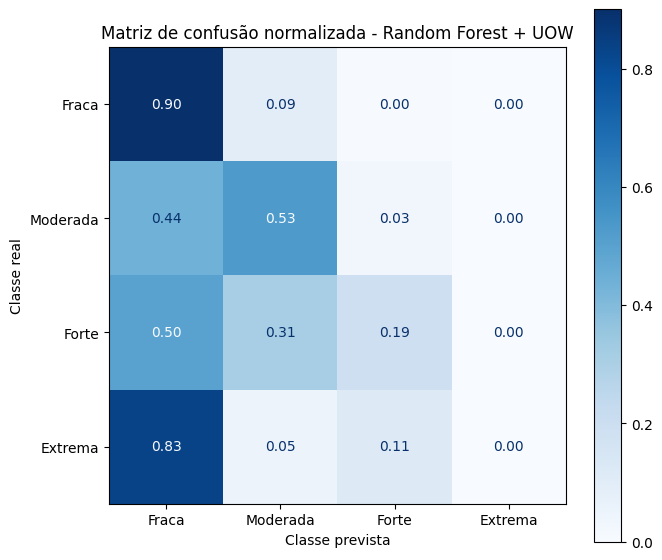

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# y_test_multiclass = valores reais
# y_pred_multiclass = previsões do modelo Random Forest + UOW

labels = [0, 1, 2, 3]

cm = confusion_matrix(
    y_test_b,
    y_test_pred_b,
    labels=labels,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fraca", "Moderada", "Forte", "Extrema"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(
    ax=ax,
    values_format=".2f",
    cmap="Blues",
    colorbar=True
)

plt.title("Matriz de confusão normalizada - UOW")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.savefig("matriz_confusao_rf_uow_multiclasse.png", dpi=300)
plt.show()

In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=15,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

# treino
rf_reg.fit(X_train_b, y_train_b)

# previsão na validação
y_val_pred_b = rf_reg.predict(X_val_b)

# métricas validação
mae = mean_absolute_error(y_val_b, y_val_pred_b)
rmse = np.sqrt(mean_squared_error(y_val_b, y_val_pred_b))
r2 = r2_score(y_val_b, y_val_pred_b)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


=== VALIDAÇÃO ===
MAE: 0.2481535392405583
RMSE: 1.3571098975436566
R²: -0.04845059819649822


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred_b = rf_reg.predict(X_test_b)

# métricas TESTE
mae_test = mean_absolute_error(y_test_b, y_test_pred_b)

rmse_test = np.sqrt(
    mean_squared_error(y_test_b, y_test_pred_b)
)

r2_test = r2_score(y_test_b, y_test_pred_b)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)



=== TESTE FINAL ===
MAE TEST: 0.26651076483198743
RMSE TEST: 1.2736008755905739
R² TEST: -0.06636723160364455


##Treinando CatBoost

In [ ]:
#CatBoost (binário)
#posso rodar varias vezes esse
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, average_precision_score

model_uow = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    # auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)



In [ ]:
model_uow.fit(X_train_b, y_train_b, eval_set=(X_val_b, y_val_b))

# validação
prob_val_b = model_uow.predict_proba(X_val_b)[:, 1]

threshold = 0.5
pred_val_b = (prob_val_b >= threshold).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val_b, pred_val_b))
print("AUC VAL:", roc_auc_score(y_val_b, prob_val_b))
print("Brier VAL:", brier_score_loss(y_val_b, prob_val_b))
print("PR AUC VAL:", average_precision_score(y_val_b, prob_val_b))


0:	test: 0.7946311	best: 0.7946311 (0)	total: 1.96s	remaining: 6m 30s
50:	test: 0.7997698	best: 0.7997698 (50)	total: 1m 20s	remaining: 3m 55s
100:	test: 0.7887713	best: 0.7997698 (50)	total: 2m 47s	remaining: 2m 44s
150:	test: 0.7829523	best: 0.7997698 (50)	total: 4m 4s	remaining: 1m 19s
199:	test: 0.7781388	best: 0.7997698 (50)	total: 5m 14s	remaining: 0us

bestTest = 0.7997698272
bestIteration = 50

Shrink model to first 51 iterations.
=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1293324
           1       0.02      0.33      0.03      6290

    accuracy                           0.91   1299614
   macro avg       0.51      0.62      0.49   1299614
weighted avg       0.99      0.91      0.95   1299614

AUC VAL: 0.7997698272073971
Brier VAL: 0.0690118056654789
PR AUC VAL: 0.01867718160403525


In [ ]:
prob_test_b = model_uow.predict_proba(X_test_b)[:, 1]
pred_test_b = (prob_test_b >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test_b, pred_test_b))
print("AUC TEST:", roc_auc_score(y_test_b, prob_test_b))
print("Brier TEST:", brier_score_loss(y_test_b, prob_test_b))
print("PR AUC TEST:", average_precision_score(y_test_b, prob_test_b))


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1356455
           1       0.03      0.51      0.06      7567

    accuracy                           0.91   1364022
   macro avg       0.51      0.71      0.51   1364022
weighted avg       0.99      0.91      0.95   1364022

AUC TEST: 0.8773555001254671
Brier TEST: 0.07232487641906446
PR AUC TEST: 0.04199113639441064


In [ ]:
#CatBoost (multiclasse)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score

model_uow = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=200,
    depth=6,
    learning_rate=0.03,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model_uow.fit(
    X_train_b, y_train_b,
    eval_set=(X_val_b, y_val_b)
)

y_pred_b = model_uow.predict(X_test_b).ravel()
y_prob_b = model_uow.predict_proba(X_test_b)

print(classification_report(y_test_b, y_pred_b))

print("F1 Macro:",
      f1_score(y_test_b, y_pred_b, average="macro"))

print("Recall Macro:",
      recall_score(y_test_b, y_pred_b, average="macro"))


print(
    "AUC:",
    roc_auc_score(
        y_test_b,
        y_prob_b,
        multi_class="ovr",
        average="macro"
    )
)


0:	learn: 0.4995556	test: 0.3582002	best: 0.3582002 (0)	total: 3.75s	remaining: 12m 26s
50:	learn: 0.6302698	test: 0.4394392	best: 0.4446021 (24)	total: 3m 11s	remaining: 9m 18s
100:	learn: 0.6508177	test: 0.3789677	best: 0.4446021 (24)	total: 6m 10s	remaining: 6m 3s
150:	learn: 0.6752655	test: 0.3714644	best: 0.4446021 (24)	total: 9m 13s	remaining: 2m 59s
199:	learn: 0.6965405	test: 0.3591716	best: 0.4446021 (24)	total: 12m 12s	remaining: 0us

bestTest = 0.4446021206
bestIteration = 24

Shrink model to first 25 iterations.
              precision    recall  f1-score   support

           0       1.00      0.65      0.78   1356455
           1       0.01      0.43      0.02      6943
           2       0.00      0.67      0.00       510
           3       0.00      0.07      0.00       114

    accuracy                           0.64   1364022
   macro avg       0.25      0.45      0.20   1364022
weighted avg       0.99      0.64      0.78   1364022

F1 Macro: 0.2031337002087561
Recall

In [ ]:
#CatBoost (regressao)
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model_uow = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# treino + validação
model_uow.fit(
    X_train_b,
    y_train_b,
    eval_set=(X_val_b, y_val_b)
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred_b = model_uow.predict(X_val_b)




0:	learn: 1.4326303	test: 1.3253407	best: 1.3253407 (0)	total: 1.3s	remaining: 3m 13s
50:	learn: 1.4267525	test: 1.3216524	best: 1.3216524 (50)	total: 33.5s	remaining: 1m 5s
100:	learn: 1.4235352	test: 1.3210479	best: 1.3210038 (97)	total: 1m 5s	remaining: 31.9s
149:	learn: 1.4214276	test: 1.3214845	best: 1.3210038 (97)	total: 1m 38s	remaining: 0us

bestTest = 1.321003826
bestIteration = 97

Shrink model to first 98 iterations.


In [ ]:
import numpy as np
rmse_val_b = np.sqrt(
    mean_squared_error(
        y_val_b,
        y_val_pred_b
    )
)

mae_val_b = mean_absolute_error(
    y_val_b,
    y_val_pred_b
)

r2_val_b = r2_score(
    y_val_b,
    y_val_pred_b
)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val_b)
print("MAE VAL:", mae_val_b)
print("R² VAL:", r2_val_b)

=== VALIDAÇÃO ===
RMSE VAL: 1.3210038363589414
MAE VAL: 0.2091115493901404
R² VAL: 0.006595566666714903


In [ ]:

# =========================================
# TESTE FINAL
# =========================================

y_test_pred_b = model_uow.predict(X_test_b)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_b,
        y_test_pred_b
    )
)

mae_test = mean_absolute_error(
    y_test_b,
    y_test_pred_b
)

r2_test = r2_score(
    y_test_b,
    y_test_pred_b
)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)



=== TESTE FINAL ===
RMSE TEST: 1.2208317335608767
MAE TEST: 0.21794956303020083
R² TEST: 0.02016778904091443


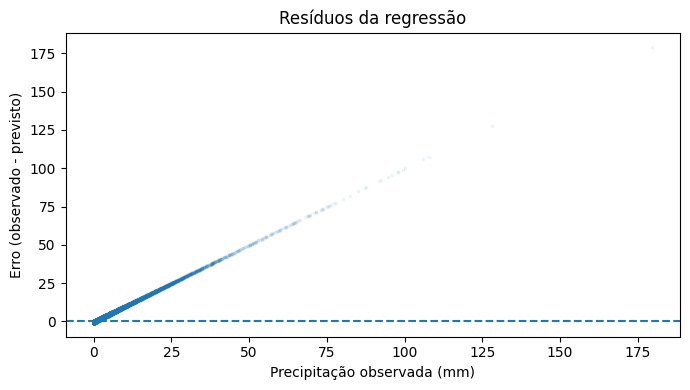

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

erro = y_test_b - y_test_pred_b

plt.figure(figsize=(7,4))

plt.scatter(
    y_test_b,
    erro,
    alpha=0.05,
    s=3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Precipitação observada (mm)")
plt.ylabel("Erro (observado - previsto)")
plt.title("Resíduos da regressão")

plt.tight_layout()
plt.show()

## Modelo com os 2

### DATASET WEBSIRENE limpo

In [ ]:
import pandas as pd

df_d = pd.read_parquet("data/datasets/dataset_D_WEBSIRENE.parquet.gzip")

surface_cols = ["id", "observation_datetime", "h04", "h24", "h96", "latitude", "longitude", "mes"]
surface_feat = df_d[surface_cols].copy()


### Juntar com UOW

In [ ]:
df_b = pd.read_parquet("data/datasets/dataset_B_UOW_NOVAS_COLUNAS.parquet.gzip")

# garantir que datetime é igual (sem tz)
df_b["observation_datetime"] = pd.to_datetime(df_b["observation_datetime"]).dt.tz_localize(None)
surface_feat["observation_datetime"] = pd.to_datetime(surface_feat["observation_datetime"]).dt.tz_localize(None)

df_int = pd.merge(
    df_b,
    surface_feat,
    on=["id", "observation_datetime"],
    how="inner"
)

print(df_int.shape)
print(df_int.columns)


(5682129, 24)
Index(['id', 'observation_datetime', 'rain_mm', 'rain_next_1h_mm', 'rain_1h',
       'cape', 'cin', 'lifted_index', 'lcl_height', 'pwat', 'freezing_level',
       'shear_0_3km', 'shear_0_6km', 'rh_850', 'rh_700', 'rh_500',
       'target_intensidade', 'target_regressao', 'h04', 'h24', 'h96',
       'latitude', 'longitude', 'mes'],
      dtype='object')


In [ ]:
#print(df_int.head(40))


In [ ]:
df_int[["rain_1h", "cape", "h24"]].corr()


,rain_1h,cape,h24
rain_1h,1.000000,0.027174,0.077956
cape,0.027174,1.000000,-0.030793
h24,0.077956,-0.030793,1.000000


In [ ]:
df_int.duplicated(subset=["id", "observation_datetime"]).any()


np.False_

In [ ]:
#df_int[df_int["rain_mm"] > 0].sort_values("observation_datetime").head(30)


### Dividindo x e y

In [ ]:
y_binario = df_int["rain_1h"]
y_intensidade = df_int["target_intensidade"]
y_regressao = df_int["target_regressao"]

X = df_int.drop(columns=[
    "id",
    "rain_1h",
    "rain_next_1h_mm",
    "observation_datetime",
    "target_intensidade",
    "target_regressao",
    "latitude",
    "longitude"
])

print(X.head())

   rain_mm         cape  cin  lifted_index  lcl_height       pwat  \
0      0.0  1017.250361  0.0     -3.432958    0.714112  38.504602   
1      0.0  1017.250361  0.0     -3.432958    0.714112  38.504602   
2      0.0  1017.250361  0.0     -3.432958    0.714112  38.504602   
3      0.0  1017.250361  0.0     -3.432958    0.714112  38.504602   
4      0.0  1017.250361  0.0     -3.432958    0.714112  38.504602   

   freezing_level  shear_0_3km  shear_0_6km     rh_850     rh_700     rh_500  \
0          4263.5     1.567072    16.039549  55.283679  61.112956  86.036163   
1          4263.5     1.567072    16.039549  55.283679  61.112956  86.036163   
2          4263.5     1.567072    16.039549  55.283679  61.112956  86.036163   
3          4263.5     1.567072    16.039549  55.283679  61.112956  86.036163   
4          4263.5     1.567072    16.039549  55.283679  61.112956  86.036163   

   h04  h24  h96  mes  
0  0.0  0.0  0.0    1  
1  0.0  0.0  0.0    1  
2  0.0  0.0  0.0    1  
3  0.0  

In [ ]:
y = y_binario
#y = y_intensidade
#y = y_regressao

train_end = pd.to_datetime("2021-01-01")
test_start = pd.to_datetime("2023-01-01")

dates = df_int["observation_datetime"]

mask_train = dates < train_end
mask_val = (dates >= train_end) & (dates < test_start)
mask_test = dates >= test_start

X_train_b = X.loc[mask_train]
y_train_b = y.loc[mask_train]

X_val_b = X.loc[mask_val]
y_val_b = y.loc[mask_val]

X_test_b = X.loc[mask_test]
y_test_b = y.loc[mask_test]

print("Treino:", X_train_b.shape, y_train_b.shape)
print("Validação:", X_val_b.shape, y_val_b.shape)
print("Teste:", X_test_b.shape, y_test_b.shape)


Treino: (3829724, 16) (3829724,)
Validação: (922472, 16) (922472,)
Teste: (929933, 16) (929933,)


In [ ]:
#RandomForest

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss


rf_int = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)





In [ ]:
from sklearn.metrics import average_precision_score

# Treinar (binário)
rf_int.fit(X_train_b, y_train_b)

# Probabilidades
y_val_prob_b = rf_int.predict_proba(X_val_b)[:, 1]

# Decisão com threshold ajustado
y_val_pred_b = (y_val_prob_b >= 0.5).astype(int)

# Avaliação na validação
print(classification_report(y_val_b, y_val_pred_b))

print("AUC VAL:", roc_auc_score(y_val_b, y_val_prob_b))
print("Brier VAL:", brier_score_loss(y_val_b, y_val_prob_b))

print(
    "PR AUC:",
    average_precision_score(y_val_b, y_val_prob_b)
)


              precision    recall  f1-score   support

           0       1.00      0.92      0.96    916431
           1       0.06      0.72      0.10      6041

    accuracy                           0.92    922472
   macro avg       0.53      0.82      0.53    922472
weighted avg       0.99      0.92      0.95    922472

AUC VAL: 0.9103546950425375
Brier VAL: 0.07475314776772478
PR AUC: 0.13406960766667267


In [ ]:
best_threshold = 0.5

y_test_prob_b = rf_int.predict_proba(X_test_b)[:, 1]
y_test_pred_b = (y_test_prob_b >= best_threshold).astype(int)

print(classification_report(y_test_b, y_test_pred_b))

print("AUC TEST:", roc_auc_score(y_test_b, y_test_prob_b))
print("Brier TEST:", brier_score_loss(y_test_b, y_test_prob_b))
print(
    "PR AUC:",
    average_precision_score(y_val_b, y_val_prob_b)
)


              precision    recall  f1-score   support

           0       1.00      0.91      0.95    922757
           1       0.06      0.76      0.12      7176

    accuracy                           0.91    929933
   macro avg       0.53      0.84      0.54    929933
weighted avg       0.99      0.91      0.95    929933

AUC TEST: 0.923475076317785
Brier TEST: 0.07569192246312009
PR AUC: 0.13406960766667267


In [ ]:
# Treinar (multiclasse)
rf_int.fit(X_train_b, y_train_b)

# Probabilidades na validação
y_val_prob_b = rf_int.predict_proba(X_val_b)

# Predição na validação
y_val_pred_b = rf_int.predict(X_val_b)

# Avaliação na validação
print("=== VALIDAÇÃO ===")
print(classification_report(y_val_b, y_val_pred_b, zero_division=0))

print(
    "AUC VAL:",
    roc_auc_score(
        y_val_b,
        y_val_prob_b,
        multi_class="ovr",
        average="macro"
    )
)


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    916431
           1       0.05      0.71      0.10      5632
           2       0.00      0.01      0.00       378
           3       0.00      0.00      0.00        31

    accuracy                           0.92    922472
   macro avg       0.26      0.41      0.27    922472
weighted avg       0.99      0.92      0.95    922472

AUC VAL: 0.8730536555096421


In [ ]:
y_test_prob_b = rf_int.predict_proba(X_test_b)
y_test_pred_b = rf_int.predict(X_test_b)

print("=== TESTE FINAL ===")
print(classification_report(y_test_b, y_test_pred_b, zero_division=0))

print(
    "AUC TEST:",
    roc_auc_score(
        y_test_b,
        y_test_prob_b,
        multi_class="ovr",
        average="macro"
    )
)


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    922757
           1       0.07      0.72      0.13      6585
           2       0.01      0.11      0.02       484
           3       0.00      0.00      0.00       107

    accuracy                           0.93    929933
   macro avg       0.27      0.44      0.28    929933
weighted avg       0.99      0.93      0.96    929933

AUC TEST: 0.9114261654581655


In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=15,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

# treino
rf_reg.fit(X_train_b, y_train_b)

# previsão na validação
y_val_pred_b = rf_reg.predict(X_val_b)

# métricas validação
mae = mean_absolute_error(y_val_b, y_val_pred_b)
rmse = np.sqrt(mean_squared_error(y_val_b, y_val_pred_b))
r2 = r2_score(y_val_b, y_val_pred_b)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


=== VALIDAÇÃO ===
MAE: 0.23516226996414674
RMSE: 1.172809488956666
R²: 0.13714180993002767


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred_b = rf_reg.predict(X_test_b)

# métricas TESTE
mae_test = mean_absolute_error(y_test_b, y_test_pred_b)

rmse_test = np.sqrt(
    mean_squared_error(y_test_b, y_test_pred_b)
)

r2_test = r2_score(y_test_b, y_test_pred_b)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
MAE TEST: 0.2375906641057764
RMSE TEST: 1.33594938430737
R² TEST: 0.1537578272152098


###CatBoost

In [ ]:
#Catboost (binario)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

model_b = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    # auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model_b.fit(
    X_train_b,
    y_train_b,
    eval_set=(X_val_b, y_val_b)
)

y_prob_val_b = model_b.predict_proba(X_val_b)[:, 1]


0:	test: 0.8994203	best: 0.8994203 (0)	total: 2.81s	remaining: 9m 19s
50:	test: 0.9189254	best: 0.9191908 (35)	total: 1m 11s	remaining: 3m 29s
100:	test: 0.9158117	best: 0.9191908 (35)	total: 2m 13s	remaining: 2m 10s
150:	test: 0.9123606	best: 0.9191908 (35)	total: 3m 10s	remaining: 1m 1s
199:	test: 0.9096701	best: 0.9191908 (35)	total: 4m 7s	remaining: 0us

bestTest = 0.9191907593
bestIteration = 35

Shrink model to first 36 iterations.


In [ ]:
y_pred_val_b = (y_prob_val_b >= 0.5).astype(int)

print("=== INTEGRADO (UOW + SUPERFÍCIE (CatBoost)) VALIDAÇAO===")
print(classification_report(y_val_b, y_pred_val_b))
print("AUC:", roc_auc_score(y_val_b, y_prob_val_b))
print("F1 Macro:", f1_score(y_val_b, y_pred_val_b, average="macro"))

=== INTEGRADO (UOW + SUPERFÍCIE (CatBoost)) VALIDAÇAO===
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    916431
           1       0.07      0.72      0.13      6041

    accuracy                           0.94    922472
   macro avg       0.54      0.83      0.55    922472
weighted avg       0.99      0.94      0.96    922472

AUC: 0.9191907592832866
F1 Macro: 0.5512571187835806


In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)

print("PR AUC TEST:", average_precision_score(y_val_b, y_prob_val_b))

PR AUC TEST: 0.15602465326533388


In [ ]:
prob_test_b = model_b.predict_proba(X_test_b)[:, 1]
pred_test_b = (prob_test_b >= 0.5).astype(int)

print("=== INTEGRADO (UOW + SUPERFÍCIE (CatBoost)) TESTE===")
print(classification_report(y_test_b, pred_test_b))
print("AUC TEST:", roc_auc_score(y_test_b, prob_test_b))
print("Brier TEST:", brier_score_loss(y_test_b, prob_test_b))
print("PR AUC TEST:", average_precision_score(y_test_b, prob_test_b))



=== INTEGRADO (UOW + SUPERFÍCIE (CatBoost)) TESTE===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    922757
           1       0.10      0.75      0.17      7176

    accuracy                           0.94    929933
   macro avg       0.55      0.85      0.57    929933
weighted avg       0.99      0.94      0.96    929933

AUC TEST: 0.9272988986470334
Brier TEST: 0.07285068447849216
PR AUC TEST: 0.22544067186289965


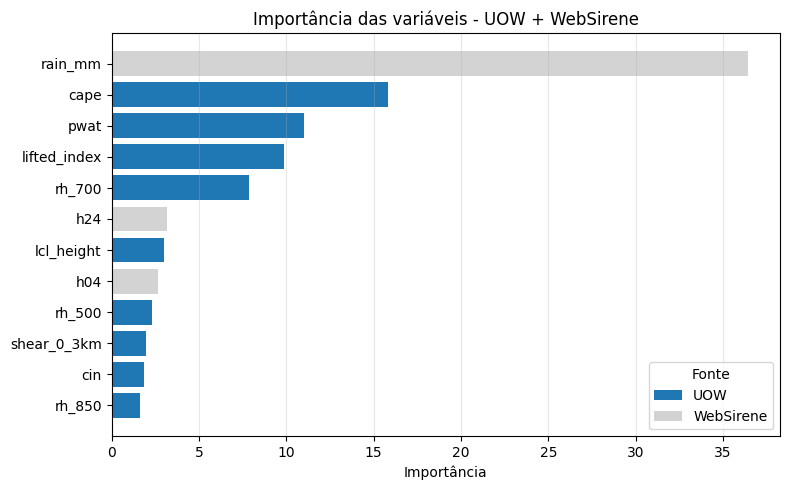

categoria
Radiossonda    56.783365
WebSirene      43.216635
Name: importance, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==================================================
# IMPORTÂNCIA DAS VARIÁVEIS - CATBOOST
# CENÁRIO: UOW + WEBSIRENE
# ==================================================

importances = model_b.get_feature_importance()
feature_names = X_train_b.columns

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

category = {
    # WebSirene
    "rain_mm": "WebSirene",
    "h04": "WebSirene",
    "h24": "WebSirene",
    "h96": "WebSirene",
    "mes": "WebSirene",

    # UOW / radiossonda
    "cape": "Radiossonda",
    "cin": "Radiossonda",
    "lifted_index": "Radiossonda",
    "lcl_height": "Radiossonda",
    "pwat": "Radiossonda",
    "freezing_level": "Radiossonda",
    "shear_0_3km": "Radiossonda",
    "shear_0_6km": "Radiossonda",
    "rh_850": "Radiossonda",
    "rh_700": "Radiossonda",
    "rh_500": "Radiossonda",
}

colors = {
    "WebSirene": "lightgray",
    "Radiossonda": "tab:blue",
}

df_importance["categoria"] = (
    df_importance["feature"]
    .map(category)
    .fillna("Outras")
)

df_top = df_importance.head(12)

plt.figure(figsize=(8, 5))

plt.barh(
    df_top["feature"],
    df_top["importance"],
    color=df_top["categoria"].map(colors)
)

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.title("Importância das variáveis - UOW + WebSirene")
plt.grid(axis="x", alpha=0.3)

legend_elements = [
    Patch(facecolor=colors["Radiossonda"], label="UOW"),
    Patch(facecolor=colors["WebSirene"], label="WebSirene"),
]

plt.legend(
    handles=legend_elements,
    title="Fonte",
    loc="lower right"
)

plt.tight_layout()
plt.savefig("importance_uow_websirene_catboost.png", dpi=300)
plt.show()

print(
    df_importance
    .groupby("categoria")["importance"]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from catboost import Pool

# ==================================================
# SHAP VALUES - CATBOOST
# CENÁRIO: UOW + WEBSIRENE
# CONJUNTO DE TESTE
# ==================================================

pool_test = Pool(X_test_b, y_test_b)

shap_values = model_b.get_feature_importance(
    data=pool_test,
    type="ShapValues"
)

# Para classificação binária:
# shap_values tem formato (n_amostras, n_features + 1)
# A última coluna é o valor base do modelo
shap_contrib = shap_values[:, :-1]
base_values = shap_values[:, -1]

shap_df = pd.DataFrame(
    shap_contrib,
    columns=X_test_b.columns,
    index=X_test_b.index
)

# ==================================================
# IMPORTÂNCIA MÉDIA DAS VARIÁVEIS NAS PREVISÕES DO TESTE
# ==================================================

df_shap_importance = (
    shap_df.abs()
    .mean()
    .reset_index()
)

df_shap_importance.columns = ["feature", "importance"]
df_shap_importance = df_shap_importance.sort_values(
    "importance",
    ascending=False
)

# Normalização opcional para ficar em percentual relativo
df_shap_importance["importance_percent"] = (
    df_shap_importance["importance"] /
    df_shap_importance["importance"].sum()
) * 100

# ==================================================
# CATEGORIAS DAS VARIÁVEIS
# ==================================================

category = {
    # WebSirene
    "rain_mm": "WebSirene",
    "h04": "WebSirene",
    "h24": "WebSirene",
    "h96": "WebSirene",
    "mes": "WebSirene",

    # UOW / radiossonda
    "cape": "Radiossonda",
    "cin": "Radiossonda",
    "lifted_index": "Radiossonda",
    "lcl_height": "Radiossonda",
    "pwat": "Radiossonda",
    "freezing_level": "Radiossonda",
    "shear_0_3km": "Radiossonda",
    "shear_0_6km": "Radiossonda",
    "rh_850": "Radiossonda",
    "rh_700": "Radiossonda",
    "rh_500": "Radiossonda",
}

colors = {
    "WebSirene": "lightgray",
    "Radiossonda": "tab:blue",
    "Outras": "tab:gray",
}

df_shap_importance["categoria"] = (
    df_shap_importance["feature"]
    .map(category)
    .fillna("Outras")
)

# ==================================================
# GRÁFICO - TOP 12 VARIÁVEIS
# ==================================================

df_top = df_shap_importance.head(12)

plt.figure(figsize=(8, 5))

plt.barh(
    df_top["feature"],
    df_top["importance_percent"],
    color=df_top["categoria"].map(colors)
)

plt.gca().invert_yaxis()

plt.xlabel("Importância média absoluta SHAP (%)")
plt.title("Importância das variáveis nas previsões - UOW + WebSirene")
plt.grid(axis="x", alpha=0.3)

legend_elements = [
    Patch(facecolor=colors["Radiossonda"], label="UOW"),
    Patch(facecolor=colors["WebSirene"], label="WebSirene"),
]

plt.legend(
    handles=legend_elements,
    title="Fonte",
    loc="lower right"
)

plt.tight_layout()
plt.savefig("shap_importance_test_uow_websirene_catboost.png", dpi=300)
plt.show()

# ==================================================
# TABELA FINAL
# ==================================================

print(df_shap_importance)

print("\nImportância por categoria:")
print(
    df_shap_importance
    .groupby("categoria")["importance_percent"]
    .sum()
    .sort_values(ascending=False)
)

KeyboardInterrupt: 

In [ ]:
#CatBoost (multiclasse)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=150,
    depth=6,
    learning_rate=0.03,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(
    X_train_b, y_train_b,
    eval_set=(X_val_b, y_val_b)
)

y_pred_b = model.predict(X_test_b).ravel()
y_prob_b = model.predict_proba(X_test_b)

print(classification_report(y_test_b, y_pred_b))

print(
    "AUC:",
    roc_auc_score(
        y_test_b,
        y_prob_b,
        multi_class="ovr",
        average="macro"
    )
)


0:	learn: 0.5672189	test: 0.5021297	best: 0.5021297 (0)	total: 7.01s	remaining: 17m 24s
50:	learn: 0.6708523	test: 0.4818445	best: 0.5191476 (8)	total: 2m 48s	remaining: 5m 26s
100:	learn: 0.7032943	test: 0.5073004	best: 0.5191476 (8)	total: 5m 26s	remaining: 2m 38s
149:	learn: 0.7221691	test: 0.4929608	best: 0.5191476 (8)	total: 7m 58s	remaining: 0us

bestTest = 0.5191475971
bestIteration = 8

Shrink model to first 9 iterations.
              precision    recall  f1-score   support

           0       1.00      0.78      0.88    922757
           1       0.06      0.47      0.10      6585
           2       0.00      0.54      0.00       484
           3       0.00      0.12      0.00       107

    accuracy                           0.78    929933
   macro avg       0.26      0.48      0.25    929933
weighted avg       0.99      0.78      0.87    929933

AUC: 0.8838221022779286


In [ ]:
#CatBoost (regressao)
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model = CatBoostRegressor(
    iterations=100,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# treino + validação
model.fit(
    X_train_b,
    y_train_b,
    eval_set=(X_val_b, y_val_b)
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred_b = model.predict(X_val_b)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val_b,
        y_val_pred_b
    )
)

mae_val = mean_absolute_error(
    y_val_b,
    y_val_pred_b
)

r2_val = r2_score(
    y_val_b,
    y_val_pred_b
)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)


0:	learn: 1.3026969	test: 1.2606971	best: 1.2606971 (0)	total: 1.83s	remaining: 3m
50:	learn: 1.2423156	test: 1.1945895	best: 1.1945895 (50)	total: 34s	remaining: 32.6s
99:	learn: 1.2140168	test: 1.1654862	best: 1.1654862 (99)	total: 1m	remaining: 0us

bestTest = 1.16548623
bestIteration = 99

=== VALIDAÇÃO ===
RMSE VAL: 1.1654862291710957
MAE VAL: 0.2202703035479582
R² VAL: 0.14788388933823848


In [ ]:
# =========================================
# TESTE FINAL
# =========================================

y_test_pred_b = model.predict(X_test_b)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_b,
        y_test_pred_b
    )
)

mae_test = mean_absolute_error(
    y_test_b,
    y_test_pred_b
)

r2_test = r2_score(
    y_test_b,
    y_test_pred_b
)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
RMSE TEST: 1.3504463761245042
MAE TEST: 0.22770498677405207
R² TEST: 0.13529226463347066


In [ ]:
# chuva real em mm no conjunto de teste
rain_mm_test = df_int.loc[
    df_int["observation_datetime"] >= split_date,
    "rain_mm"
]

faixas = {
    "0–5 mm":  (rain_mm_test > 0.1) & (rain_mm_test <= 5.0),
    "5–25 mm": (rain_mm_test > 5.0) & (rain_mm_test <= 25.0),
    "25–50 mm": (rain_mm_test > 25.0) & (rain_mm_test <= 50.0),
    ">50 mm":  (rain_mm_test > 50.0),
}

for nome, mask in faixas.items():
    if mask.sum() < 50:
        continue  # evita estatística lixo

    print(f"\n=== Faixa {nome} ===")
    print(classification_report(
        y_test_b[mask],
        y_pred[mask],
        zero_division=0
    ))



=== Faixa 0–5 mm ===
              precision    recall  f1-score   support

           0       0.97      0.37      0.53     96220
           1       0.05      0.76      0.10      4528

    accuracy                           0.39    100748
   macro avg       0.51      0.56      0.32    100748
weighted avg       0.93      0.39      0.52    100748


=== Faixa 5–25 mm ===
              precision    recall  f1-score   support

           0       0.77      0.15      0.26      6606
           1       0.33      0.90      0.48      3035

    accuracy                           0.39      9641
   macro avg       0.55      0.53      0.37      9641
weighted avg       0.63      0.39      0.33      9641


=== Faixa 25–50 mm ===
              precision    recall  f1-score   support

           0       0.88      0.14      0.24       324
           1       0.53      0.98      0.69       327

    accuracy                           0.56       651
   macro avg       0.71      0.56      0.46       651
weigh

### Comparaçao direta ablaçao

In [ ]:
from sklearn.metrics import f1_score

f1_surface_b = f1_score(y_test_b, y_pred_surface_b, pos_label=1)
f1_radio_b    = f1_score(y_test_b, y_pred_radio_b, pos_label=1)
f1_combined_b = f1_score(y_test_b, y_pred_combined_b, pos_label=1)

f1_surface_b, f1_radio_b, f1_combined_b



results_b = pd.DataFrame({
    "Modelo": ["Superfície", "Radiossonda (UOW)", "Integrado"],
    "F1 (chuva)": [f1_surface_b, f1_radio_b, f1_combined_b],
    "AUC": [
        roc_auc_score(y_test_b, y_prob_surface_b),
        roc_auc_score(y_test_b, y_prob_radio_b),
        roc_auc_score(y_test_b, y_prob_combined_b),
    ],
    "Brier": [
        brier_score_loss(y_test_b, y_prob_surface_b),
        brier_score_loss(y_test_b, y_prob_radio_b),
        brier_score_loss(y_test_b, y_prob_combined_b),
    ]
})

results_b



,Modelo,F1 (chuva),AUC,Brier
0,Superfície,0.066733,0.918649,0.071964
1,Radiossonda (UOW),0.066733,0.882184,0.019336
2,Integrado,0.066733,0.872705,0.009767


### Quantificação do ganho proporcionado pela integração

In [ ]:
ganho_auc_b = results_b.loc[results_b["Modelo"] == "Integrado", "AUC"].values[0] - \
            results_b.loc[results_b["Modelo"] == "Superfície", "AUC"].values[0]

ganho_f1_b = results_b.loc[results_b["Modelo"] == "Integrado", "F1 (chuva)"].values[0] - \
           results_b.loc[results_b["Modelo"] == "Superfície", "F1 (chuva)"].values[0]

ganho_brier_b = results_b.loc[results_b["Modelo"] == "Superfície", "Brier"].values[0] - \
              results_b.loc[results_b["Modelo"] == "Integrado", "Brier"].values[0]

print("\nGanho da Integração (Superfície + Radiossonda) sobre Superfície:")
print(f"Ganho AUC: {ganho_auc_b:.4f}")
print(f"Ganho F1 (chuva): {ganho_f1_b:.4f}")
print(f"Ganho Brier: {ganho_brier_b:.4f}")



Ganho da Integração (Superfície + Radiossonda) sobre Superfície:
Ganho AUC: -0.0459
Ganho F1 (chuva): 0.0000
Ganho Brier: 0.0622


# IGRA + UOW

## Voltando...

In [ ]:
!pip install duckdb pyarrow

In [ ]:
!python src/sounding/dataset_C.py

Traceback (most recent call last):
  File "/content/drive/MyDrive/atmoseer/src/sounding/dataset_C.py", line 92, in <module>
    con.execute(sql)
duckdb.duckdb.BinderException: Binder Error: Referenced column "latitude" not found in FROM clause!
Candidate bindings: "pwat", "target_intensidade", "lifted_index", "id", "__index_level_0__"

LINE 8: ...", "rain_1h", "target_intensidade", "target_regressao", "latitude", "longitude",
                                                                   ^


In [ ]:
import pandas as pd
data_c = pd.read_parquet("data/datasets/dataset_C_IGRA_UOW_NOVAS_COLUNAS.parquet")

print("Colunas do data set C:", data_c.columns.tolist())

print(data_c[["rain_1h", "target_intensidade", "target_regressao"]].head())
print(data_c.shape)
print(data_c.head(10))





Colunas do data set C: ['id', 'observation_datetime', 'rain_mm', 'rain_next_1h_mm', 'rain_1h', 'target_intensidade', 'target_regressao', 'igra_cape', 'igra_cin', 'igra_lifted_index', 'igra_lcl_height', 'igra_pwat', 'igra_freezing_level', 'igra_shear_0_3km', 'igra_shear_0_6km', 'igra_rh_850', 'igra_rh_700', 'igra_rh_500', 'igra___index_level_0__', 'uow_cape', 'uow_cin', 'uow_lifted_index', 'uow_lcl_height', 'uow_pwat', 'uow_freezing_level', 'uow_shear_0_3km', 'uow_shear_0_6km', 'uow_rh_850', 'uow_rh_700', 'uow_rh_500', 'uow___index_level_0__']
   rain_1h  target_intensidade  target_regressao
0        0                   0               0.0
1        0                   0               0.0
2        0                   0               0.0
3        0                   0               0.0
4        0                   0               0.0
(8203743, 31)
   id observation_datetime  rain_mm  rain_next_1h_mm  rain_1h  \
0  42  2015-06-11 15:00:00      0.0              0.0        0   
1  82  2015-0

In [ ]:
data_c["rain_1h_x"].value_counts()


,count
rain_1h_x,
0,8166459
1,37284


In [ ]:
data_c.columns
# data_c["rain_1h"].value_counts()
# data_c.isna().sum()


Index(['id', 'observation_datetime', 'rain_mm_x', 'rain_1h_x', 'igra_cape',
       'igra_cin', 'igra_lifted_index', 'igra_lcl_height', 'igra_pwat',
       'igra_freezing_level', 'igra_shear_0_3km', 'igra_shear_0_6km',
       'igra_rh_850', 'igra_rh_700', 'igra_rh_500', 'rain_mm_y', 'rain_1h_y',
       'uow_cape', 'uow_cin', 'uow_lifted_index', 'uow_lcl_height', 'uow_pwat',
       'uow_freezing_level', 'uow_shear_0_3km', 'uow_shear_0_6km',
       'uow_rh_850', 'uow_rh_700', 'uow_rh_500'],
      dtype='object')

In [ ]:
(data_c["rain_1h_x"] == data_c["rain_1h_y"]).mean()


np.float64(1.0)

### Separando X e y

In [ ]:
import pandas as pd

data_c = pd.read_parquet(
    "data/datasets/dataset_C_IGRA_UOW_NOVAS_COLUNAS.parquet"
)

y_binario = data_c["rain_1h"]
y_intensidade = data_c["target_intensidade"]
y_regressao = data_c["target_regressao"]

X_c = data_c.drop(columns=[
    "id",
    "observation_datetime",
    "rain_next_1h_mm",
    "rain_1h",
    "target_intensidade",
    "target_regressao",
    "igra___index_level_0__",
    "uow___index_level_0__",
    "latitude",
    "longitude"
], errors="ignore")

print(X_c.head())

## Formando o vetor final de entrada IGRA + UOW + websirene

### Dividindo treino e teste

In [ ]:
data_c["observation_datetime"].min(), data_c["observation_datetime"].max()


(Timestamp('2012-01-01 00:00:00'), Timestamp('2024-11-27 12:00:00'))

In [ ]:
#INCLUINDO OS DADOS DE VALIDAÇAO

y = y_binario
#y = y_intensidade
#y = y_regressao

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = data_c["observation_datetime"] < train_end
mask_val = (data_c["observation_datetime"] >= train_end) & (data_c["observation_datetime"] < val_end)
mask_test = data_c["observation_datetime"] >= val_end

X_train = X_c.loc[mask_train]
y_train = y.loc[mask_train]

X_val = X_c.loc[mask_val]
y_val = y.loc[mask_val]

X_test = X_c.loc[mask_test]
y_test = y.loc[mask_test]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


## Treinando o modelo Random Forest

### Hiperparâmetros iniciais

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss
)


In [ ]:

from sklearn.model_selection import train_test_split

#binario

rf_radio = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    #class_weight="balanced_subsample",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)




### Avaliando o modelo (Só radiossonda)

random forest

In [ ]:
from sklearn.metrics import average_precision_score

# Treinar (binário)
rf_radio.fit(X_train, y_train)

# Probabilidades
y_val_prob = rf_radio.predict_proba(X_val)[:, 1]

# Decisão com threshold ajustado
y_val_pred = (y_val_prob >= 0.5).astype(int)

# Avaliação na validação
print(classification_report(y_val, y_val_pred))

print("AUC VAL:", roc_auc_score(y_val, y_val_prob))
print("Brier VAL:", brier_score_loss(y_val, y_val_prob))

print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)





              precision    recall  f1-score   support

           0       1.00      0.87      0.93   1285622
           1       0.02      0.45      0.03      6273

    accuracy                           0.86   1291895
   macro avg       0.51      0.66      0.48   1291895
weighted avg       0.99      0.86      0.92   1291895

AUC VAL: 0.7863200306032305
Brier VAL: 0.09582761660941182
PR AUC: 0.014916424868229548


In [ ]:
best_threshold = 0.5

y_test_prob = rf_radio.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred))

print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)


              precision    recall  f1-score   support

           0       1.00      0.86      0.93   1317406
           1       0.03      0.64      0.05      7440

    accuracy                           0.86   1324846
   macro avg       0.51      0.75      0.49   1324846
weighted avg       0.99      0.86      0.92   1324846

AUC TEST: 0.8636420209936343
Brier TEST: 0.09324865425438686
PR AUC: 0.014916424868229548


In [ ]:
# # chuva real em mm no conjunto de teste
# rain_mm_test = data_c.loc[
#     data_c["observation_datetime"] >= split_date,
#     "rain_mm_x"
# ]

# faixas = {
#     "0–5 mm":  (rain_mm_test > 0.0) & (rain_mm_test <= 5.0),
#     "5–25 mm": (rain_mm_test > 5.0) & (rain_mm_test <= 25.0),
#     "25–50 mm": (rain_mm_test > 25.0) & (rain_mm_test <= 50.0),
#     ">50 mm":  (rain_mm_test > 50.0),
# }

# for nome, mask in faixas.items():
#     if mask.sum() < 50:
#         continue  # evita estatística lixo

#     print(f"\n=== Faixa {nome} ===")
#     print(classification_report(
#         y_test[mask],
#         y_pred[mask],
#         zero_division=0
#     ))



=== Faixa 0–5 mm ===
              precision    recall  f1-score   support

           0       0.97      0.31      0.47     99217
           1       0.05      0.77      0.09      4719

    accuracy                           0.33    103936
   macro avg       0.51      0.54      0.28    103936
weighted avg       0.92      0.33      0.45    103936


=== Faixa 5–25 mm ===
              precision    recall  f1-score   support

           0       0.67      0.20      0.31      6788
           1       0.31      0.78      0.45      3153

    accuracy                           0.39      9941
   macro avg       0.49      0.49      0.38      9941
weighted avg       0.55      0.39      0.35      9941


=== Faixa 25–50 mm ===
              precision    recall  f1-score   support

           0       0.63      0.31      0.41       337
           1       0.55      0.82      0.66       344

    accuracy                           0.57       681
   macro avg       0.59      0.57      0.54       681
weigh

In [ ]:
# Treinar (multiclasse)
rf_radio.fit(X_train, y_train)

# Probabilidades na validação
y_val_prob = rf_radio.predict_proba(X_val)

# Predição na validação
y_val_pred = rf_radio.predict(X_val)

# Avaliação na validação
print("=== VALIDAÇÃO ===")
print(classification_report(y_val, y_val_pred, zero_division=0))

print(
    "AUC VAL:",
    roc_auc_score(
        y_val,
        y_val_prob,
        multi_class="ovr",
        average="macro"
    )
)


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.90      0.95   1285622
           1       0.01      0.31      0.03      5843
           2       0.00      0.00      0.00       393
           3       0.00      0.00      0.00        37

    accuracy                           0.90   1291895
   macro avg       0.25      0.30      0.24   1291895
weighted avg       0.99      0.90      0.94   1291895

AUC VAL: 0.7886595323679133


In [ ]:
y_test_prob = rf_radio.predict_proba(X_test)
y_test_pred = rf_radio.predict(X_test)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))

print(
    "AUC TEST:",
    roc_auc_score(
        y_test,
        y_test_prob,
        multi_class="ovr",
        average="macro"
    )
)


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.89      0.94   1317406
           1       0.02      0.45      0.04      6819
           2       0.01      0.19      0.01       509
           3       0.00      0.00      0.00       112

    accuracy                           0.89   1324846
   macro avg       0.26      0.38      0.25   1324846
weighted avg       0.99      0.89      0.94   1324846

AUC TEST: 0.8454686188835858


In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# treino
rf_reg.fit(X_train, y_train)

# previsão na validação
y_val_pred = rf_reg.predict(X_val)

# métricas validação
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


=== VALIDAÇÃO ===
MAE: 0.22979867257079037
RMSE: 1.3525448356461884
R²: -0.03640385110500777


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred = rf_reg.predict(X_test)

# métricas TESTE
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
MAE TEST: 0.2548037903743467
RMSE TEST: 1.2743309600056365
R² TEST: -0.05549148622565436


CatBoost

In [ ]:
#CatBoost (binário)
#posso rodar varias vezes esse
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, average_precision_score

model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    # auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(X_train, y_train, eval_set=(X_val, y_val))


# validação
prob_val = model.predict_proba(X_val)[:, 1]

threshold = 0.5
pred_val = (prob_val >= threshold).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val, pred_val))
print("AUC VAL:", roc_auc_score(y_val, prob_val))
print("Brier VAL:", brier_score_loss(y_val, prob_val))
print("PR AUC VAL:", average_precision_score(y_val, prob_val))


0:	test: 0.7809450	best: 0.7809450 (0)	total: 1.7s	remaining: 5m 38s
50:	test: 0.7898403	best: 0.7903215 (36)	total: 1m 28s	remaining: 4m 19s
100:	test: 0.7858904	best: 0.7907020 (52)	total: 2m 51s	remaining: 2m 48s
150:	test: 0.7736612	best: 0.7907020 (52)	total: 4m 16s	remaining: 1m 23s
199:	test: 0.7708664	best: 0.7907020 (52)	total: 5m 40s	remaining: 0us

bestTest = 0.7907019621
bestIteration = 52

Shrink model to first 53 iterations.
=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1285622
           1       0.02      0.27      0.03      6273

    accuracy                           0.92   1291895
   macro avg       0.51      0.60      0.49   1291895
weighted avg       0.99      0.92      0.95   1291895

AUC VAL: 0.7907019621290866
Brier VAL: 0.0664393071485257
PR AUC VAL: 0.015145645121235521


In [ ]:
prob_test = model.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, pred_test))
print("AUC TEST:", roc_auc_score(y_test, prob_test))
print("Brier TEST:", brier_score_loss(y_test, prob_test))
print("PR AUC TEST:", average_precision_score(y_test, prob_test))


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1317406
           1       0.03      0.48      0.06      7440

    accuracy                           0.92   1324846
   macro avg       0.51      0.70      0.51   1324846
weighted avg       0.99      0.92      0.95   1324846

AUC TEST: 0.8722280979721488
Brier TEST: 0.06865718459252378
PR AUC TEST: 0.04086778856023349


In [ ]:
#CatBoost (multiclasse)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import f1_score, recall_score

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=150,
    depth=6,
    learning_rate=0.03,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred = model.predict(X_test).ravel()
y_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))


print("F1 Macro:",
      f1_score(y_test, y_pred, average="macro"))

print("Recall Macro:",
      recall_score(y_test, y_pred, average="macro"))

print("AUC:",
      roc_auc_score(
          y_test,
          y_prob,
          multi_class="ovr",
          average="macro"
      ))




0:	learn: 0.5283028	test: 0.4352112	best: 0.4352112 (0)	total: 6.77s	remaining: 16m 48s
50:	learn: 0.6268682	test: 0.3949036	best: 0.4365183 (21)	total: 4m 14s	remaining: 8m 14s
100:	learn: 0.6620743	test: 0.3832221	best: 0.4365183 (21)	total: 8m 20s	remaining: 4m 2s
149:	learn: 0.6804738	test: 0.3872019	best: 0.4365183 (21)	total: 12m 11s	remaining: 0us

bestTest = 0.4365183216
bestIteration = 21

Shrink model to first 22 iterations.
              precision    recall  f1-score   support

           0       1.00      0.62      0.77   1317406
           1       0.01      0.55      0.03      6819
           2       0.00      0.66      0.00       509
           3       0.00      0.02      0.00       112

    accuracy                           0.62   1324846
   macro avg       0.25      0.46      0.20   1324846
weighted avg       0.99      0.62      0.76   1324846

F1 Macro: 0.19914067005844513
Recall Macro: 0.46317253147393256
AUC: 0.8517696689068321


In [ ]:
#CatBoost (regressao)
from catboost import CatBoostRegressor
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# treino + validação
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred = model.predict(X_val)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)

mae_val = mean_absolute_error(
    y_val,
    y_val_pred
)

r2_val = r2_score(
    y_val,
    y_val_pred
)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)



0:	learn: 1.4331209	test: 1.3285644	best: 1.3285644 (0)	total: 1.58s	remaining: 3m 54s
50:	learn: 1.4271106	test: 1.3251284	best: 1.3251269 (49)	total: 40.7s	remaining: 1m 18s
100:	learn: 1.4236380	test: 1.3248272	best: 1.3246911 (90)	total: 1m 21s	remaining: 39.5s
149:	learn: 1.4213924	test: 1.3253432	best: 1.3246911 (90)	total: 2m 2s	remaining: 0us

bestTest = 1.324691059
bestIteration = 90

Shrink model to first 91 iterations.
=== VALIDAÇÃO ===
RMSE VAL: 1.3246910698448444
MAE VAL: 0.2088729981485546
R² VAL: 0.005843184198985996


In [ ]:
# =========================================
# TESTE FINAL
# =========================================

y_test_pred = model.predict(X_test)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

mae_test = mean_absolute_error(
    y_test,
    y_test_pred
)

r2_test = r2_score(
    y_test,
    y_test_pred
)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
RMSE TEST: 1.2278973096020989
MAE TEST: 0.2170782230396899
R² TEST: 0.020026433709818048


### Experimentos de ablaçao

### Modelo com os 2

### Juntando os 3

In [ ]:
import pandas as pd

df_c = pd.read_parquet(
    "data/datasets/dataset_C_IGRA_UOW_NOVAS_COLUNAS.parquet"
)

df_c["observation_datetime"] = (
    pd.to_datetime(df_c["observation_datetime"])
    .dt.tz_localize(None)
    .dt.floor("h")
)

print(df_c.shape)
print(df_c.head())


(8203743, 31)
   id observation_datetime  rain_mm  rain_next_1h_mm  rain_1h  \
0  42  2015-06-11 15:00:00      0.0              0.0        0   
1  82  2015-06-11 15:00:00      0.0              0.0        0   
2  43  2015-06-11 15:00:00      0.0              0.0        0   
3  32  2015-06-11 15:00:00      0.0              0.0        0   
4  70  2015-06-11 15:00:00      0.0              0.0        0   

   target_intensidade  target_regressao  igra_cape  igra_cin  \
0                   0               0.0        0.0       0.0   
1                   0               0.0        0.0       0.0   
2                   0               0.0        0.0       0.0   
3                   0               0.0        0.0       0.0   
4                   0               0.0        0.0       0.0   

   igra_lifted_index  ...  uow_lifted_index  uow_lcl_height   uow_pwat  \
0           7.045131  ...          6.681288        0.971116  22.137664   
1           7.045131  ...          6.681288        0.971116  2

In [ ]:
df_surface = pd.read_parquet(
    "data/datasets/dataset_D_WEBSIRENE.parquet.gzip"
)

df_surface["observation_datetime"] = (
    pd.to_datetime(df_surface["observation_datetime"])
    .dt.tz_localize(None)
    .dt.floor("h")
)

print(df_surface.shape)


(6893274, 12)


In [ ]:
df_int = pd.merge(
    df_c,
    df_surface,
    on=["id", "observation_datetime"],
    how="inner"
)

print("Integrado IGRA + UOW + superfície:", df_int.shape)


In [ ]:
print(df_int.shape)

print(df_int.columns.tolist())

In [ ]:
print(
    [c for c in df_int.columns
     if "target" in c or "rain_next" in c]
)

['rain_next_1h_mm', 'target_intensidade', 'target_regressao']


In [ ]:
na_rows = df_int.isna().any(axis=1).sum()

print("Linhas com algum NaN:", na_rows)
print("Percentual:", na_rows / len(df_int) * 100)

Linhas com algum NaN: 102874
Percentual: 1.8205512727082245


In [ ]:
df_int = df_int.dropna()
df_int = df_int.sort_values(["id", "observation_datetime"])

assert not df_int.duplicated(["id", "observation_datetime"]).any()


In [ ]:
df_int.columns

Index(['id', 'observation_datetime', 'rain_mm_x', 'rain_next_1h_mm',
       'rain_1h_x', 'target_intensidade', 'target_regressao', 'igra_cape',
       'igra_cin', 'igra_lifted_index', 'igra_lcl_height', 'igra_pwat',
       'igra_freezing_level', 'igra_shear_0_3km', 'igra_shear_0_6km',
       'igra_rh_850', 'igra_rh_700', 'igra_rh_500', 'igra___index_level_0__',
       'uow_cape', 'uow_cin', 'uow_lifted_index', 'uow_lcl_height', 'uow_pwat',
       'uow_freezing_level', 'uow_shear_0_3km', 'uow_shear_0_6km',
       'uow_rh_850', 'uow_rh_700', 'uow_rh_500', 'uow___index_level_0__',
       'index', 'rain_mm_y', 'rain_1h_y', 'latitude', 'longitude', 'm5', 'h04',
       'h24', 'h96', 'mes'],
      dtype='object')

### Dividindo x e y

In [ ]:
# Alvo
y_binario = df_int["rain_1h_x"]
y_intensidade = df_int["target_intensidade"]
y_regressao = df_int["target_regressao"]

# Criar rain_mm única
df_int["rain_mm"] = df_int["rain_mm_x"].combine_first(df_int["rain_mm_y"])

# Features
X = df_int.drop(columns=[
    "id",
    "observation_datetime",
    "index",

    "rain_mm_x",
    "rain_mm_y",
    "rain_next_1h_mm",
    "rain_1h_x",
    "rain_1h_y",

    "target_intensidade",
    "target_regressao",
    "latitude",
    "longitude",

    "m5",

    "igra___index_level_0__",
    "uow___index_level_0__"
], errors="ignore")

print(X.columns.tolist())
print(X.shape)



In [ ]:
import pandas as pd

y = y_binario
#y = y_intensidade
#y = y_regressao

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = df_int["observation_datetime"] < train_end
mask_val = (df_int["observation_datetime"] >= train_end) & (df_int["observation_datetime"] < val_end)
mask_test = df_int["observation_datetime"] >= val_end

X_train = X[mask_train]
y_train = y[mask_train]

X_val = X[mask_val]
y_val = y[mask_val]

X_test = X[mask_test]
y_test = y[mask_test]

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)



In [ ]:
#random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss

rf_int = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)




In [ ]:
from sklearn.metrics import average_precision_score

# Treinar (binário)
rf_int.fit(X_train, y_train)

# Probabilidades
y_val_prob = rf_int.predict_proba(X_val)[:, 1]

# Decisão com threshold ajustado
y_val_pred = (y_val_prob >= 0.5).astype(int)

# Avaliação na validação
print("=== INTEGRADO (IGRA + UOW + SUPERFÍCIE) ===")
print(classification_report(y_val, y_val_pred))

print("AUC VAL:", roc_auc_score(y_val, y_val_prob))
print("Brier VAL:", brier_score_loss(y_val, y_val_prob))

print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)


KeyboardInterrupt: 

In [ ]:
best_threshold = 0.5

y_test_prob = rf_int.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred))

print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)


              precision    recall  f1-score   support

           0       1.00      0.92      0.96    897785
           1       0.07      0.75      0.13      7053

    accuracy                           0.92    904838
   macro avg       0.54      0.84      0.55    904838
weighted avg       0.99      0.92      0.95    904838

AUC TEST: 0.9241254158634085
Brier TEST: 0.07285019186600997
PR AUC: 0.10248147229899217


In [ ]:
# Treinar (multiclasse)
rf_int.fit(X_train, y_train)

# Probabilidades na validação
y_val_prob = rf_int.predict_proba(X_val)

# Predição na validação
y_val_pred = rf_int.predict(X_val)

# Avaliação na validação
print("=== VALIDAÇÃO ===")
print(classification_report(y_val, y_val_pred, zero_division=0))

print(
    "AUC VAL:",
    roc_auc_score(
        y_val,
        y_val_prob,
        multi_class="ovr",
        average="macro"
    )
)


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    912890
           1       0.05      0.64      0.10      5615
           2       0.00      0.00      0.00       378
           3       0.00      0.00      0.00        31

    accuracy                           0.93    918914
   macro avg       0.26      0.39      0.26    918914
weighted avg       0.99      0.93      0.96    918914

AUC VAL: 0.8863446707932865


In [ ]:
y_test_prob = rf_int.predict_proba(X_test)
y_test_pred = rf_int.predict(X_test)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))

print(
    "AUC TEST:",
    roc_auc_score(
        y_test,
        y_test_prob,
        multi_class="ovr",
        average="macro"
    )
)


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    897785
           1       0.08      0.68      0.14      6465
           2       0.01      0.11      0.03       483
           3       0.00      0.00      0.00       105

    accuracy                           0.93    904838
   macro avg       0.27      0.43      0.28    904838
weighted avg       0.99      0.93      0.96    904838

AUC TEST: 0.9160790592215435


In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1

)

# treino
rf_reg.fit(X_train, y_train)

# previsão na validação
y_val_pred = rf_reg.predict(X_val)

# métricas validação
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


=== VALIDAÇÃO ===
MAE: 0.2129060513940756
RMSE: 1.1693236680248038
R²: 0.1441010340437845


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred = rf_reg.predict(X_test)

# métricas TESTE
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
MAE TEST: 0.22165813581816374
RMSE TEST: 1.333773544501715
R² TEST: 0.16398177605129693


In [ ]:
#CatBoost

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    iterations=80,
    depth=4,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    # auto_class_weights="Balanced",
    random_seed=42,
    verbose=20,
    thread_count=2
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=10
)


In [ ]:
# validação
prob_val = model.predict_proba(X_val)[:, 1]

threshold = 0.5
pred_val = (prob_val >= threshold).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val, pred_val))




In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, average_precision_score
print("AUC VAL:", roc_auc_score(y_val, prob_val))
print("Brier VAL:", brier_score_loss(y_val, prob_val))
print("PR AUC VAL:", average_precision_score(y_val, prob_val))

In [ ]:
# grafico aq
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

importances = model.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

category = {
    "cape": "Instabilidade",
    "cin": "Instabilidade",
    "lifted_index": "Instabilidade",
    "lcl_height": "Instabilidade",

    "pwat": "Outras",
    "rh_850": "Outras",
    "rh_700": "Outras",
    "rh_500": "Outras",
    "freezing_level": "Outras",
    "shear_0_3km": "Outras",
    "shear_0_6km": "Outras",
}

colors = {
    "Instabilidade": "tab:orange",
    "Outras": "lightgray",
}

df_importance["categoria"] = (
    df_importance["feature"]
    .map(category)
    .fillna("Outras")
)

top_n = 9
df_top = df_importance.head(top_n)

plt.figure(figsize=(7, 4))

plt.barh(
    df_top["feature"],
    df_top["importance"],
    color=df_top["categoria"].map(colors)
)

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.title("Importância das variáveis atmosféricas - IGRA")
plt.grid(axis="x", alpha=0.3)

legend_elements = [
    Patch(facecolor=colors["Instabilidade"], label="Instabilidade"),
    Patch(facecolor=colors["Outras"], label="Outras")
]

plt.legend(
    handles=legend_elements,
    title="Grupo físico",
    loc="lower right"
)

plt.tight_layout()
plt.savefig("importance_igra_catboost_categorias.png", dpi=300)
plt.show()

In [ ]:
prob_test = model.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, pred_test))
print("AUC TEST:", roc_auc_score(y_test, prob_test))
print("Brier TEST:", brier_score_loss(y_test, prob_test))
print("PR AUC TEST:", average_precision_score(y_test, prob_test))


=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    897785
           1       0.10      0.75      0.18      7053

    accuracy                           0.95    904838
   macro avg       0.55      0.85      0.57    904838
weighted avg       0.99      0.95      0.97    904838

AUC TEST: 0.9305708317357237
Brier TEST: 0.061702426525191235
PR AUC TEST: 0.21776191411000453


In [ ]:
#CatBoost (multiclasse)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=150,
    depth=6,
    learning_rate=0.03,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred = model.predict(X_test).ravel()
y_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))

print(
    "AUC:",
    roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="macro"

    )
)


0:	learn: 0.5083122	test: 0.3433965	best: 0.3433965 (0)	total: 7.74s	remaining: 19m 13s
50:	learn: 0.6712012	test: 0.4719893	best: 0.4933080 (47)	total: 3m 40s	remaining: 7m 7s
100:	learn: 0.7057831	test: 0.4718399	best: 0.4933080 (47)	total: 7m 12s	remaining: 3m 29s
149:	learn: 0.7241148	test: 0.4832000	best: 0.4933080 (47)	total: 10m 34s	remaining: 0us

bestTest = 0.4933079943
bestIteration = 47

Shrink model to first 48 iterations.
              precision    recall  f1-score   support

           0       1.00      0.78      0.87    897785
           1       0.05      0.57      0.10      6465
           2       0.00      0.59      0.00       483
           3       0.00      0.07      0.00       105

    accuracy                           0.77    904838
   macro avg       0.26      0.50      0.24    904838
weighted avg       0.99      0.77      0.87    904838

AUC: 0.899694123727327


In [ ]:
#CatBoost (regressao)
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# treino + validação
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred = model.predict(X_val)



0:	learn: 1.3030908	test: 1.2620310	best: 1.2620310 (0)	total: 636ms	remaining: 1m 34s
50:	learn: 1.2419187	test: 1.1959246	best: 1.1959246 (50)	total: 26.2s	remaining: 50.8s
100:	learn: 1.2130887	test: 1.1673805	best: 1.1673805 (100)	total: 49.9s	remaining: 24.2s
149:	learn: 1.1978213	test: 1.1543412	best: 1.1543412 (149)	total: 1m 16s	remaining: 0us

bestTest = 1.154341219
bestIteration = 149



In [ ]:
import numpy as np
rmse_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)

mae_val = mean_absolute_error(
    y_val,
    y_val_pred
)

r2_val = r2_score(
    y_val,
    y_val_pred
)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)


=== VALIDAÇÃO ===
RMSE VAL: 1.154341218146816
MAE VAL: 0.21257085544451854
R² VAL: 0.1658936492202917


In [ ]:
# =========================================
# TESTE FINAL
# =========================================

y_test_pred = model.predict(X_test)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

mae_test = mean_absolute_error(
    y_test,
    y_test_pred
)

r2_test = r2_score(
    y_test,
    y_test_pred
)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
RMSE TEST: 1.3404424828029928
MAE TEST: 0.2201204061533988
R² TEST: 0.1556006044353223


##CatBoost

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.01,
    eval_metric="AUC",
    auto_class_weights="Balanced",
    verbose=50
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))
print("AUC:", roc_auc_score(y_test, prob))


0:	test: 0.8314035	best: 0.8314035 (0)	total: 2.19s	remaining: 3m 37s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.8314034515
bestIteration = 0

Shrink model to first 1 iterations.
              precision    recall  f1-score   support

           0       1.00      0.62      0.77   1912935
           1       0.01      0.90      0.03     10756

    accuracy                           0.63   1923691
   macro avg       0.51      0.76      0.40   1923691
weighted avg       0.99      0.63      0.76   1923691

AUC: 0.8352585085873706


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       1.00      0.62      0.77   1912935
           1       0.01      0.90      0.03     10756

    accuracy                           0.63   1923691
   macro avg       0.51      0.76      0.40   1923691
weighted avg       0.99      0.63      0.76   1923691

AUC: 0.8352585085873706


# SÓ WEBSIRENE

In [ ]:
# Preciso só das colunas do websirene, então precisei separar as colunas dele:
# a tabela só com o id, observation, rain_mm e rain_1h já existe, certo: websirene_labels_1h_full.parquet.gzip
# agora preciso de outra só com as outras colunas: websirene_SURFACE_FEATURES_restantes.parquet.gzip

In [ ]:
!python src/sounding/juntar_websirene_colunas_restantes.py


Total de arquivos encontrados: 1158
Lendo: data/ws/full\station_id=1\year=2012\data.parquet
Lendo: data/ws/full\station_id=1\year=2013\data.parquet
Lendo: data/ws/full\station_id=1\year=2014\data.parquet
Lendo: data/ws/full\station_id=1\year=2015\data.parquet
Lendo: data/ws/full\station_id=1\year=2016\data.parquet
Lendo: data/ws/full\station_id=1\year=2017\data.parquet
Lendo: data/ws/full\station_id=1\year=2018\data.parquet
Lendo: data/ws/full\station_id=1\year=2019\data.parquet
Lendo: data/ws/full\station_id=1\year=2020\data.parquet
Lendo: data/ws/full\station_id=1\year=2021\data.parquet
Lendo: data/ws/full\station_id=1\year=2022\data.parquet
Lendo: data/ws/full\station_id=1\year=2023\data.parquet
Lendo: data/ws/full\station_id=1\year=2024\data.parquet
Lendo: data/ws/full\station_id=1\year=2025\data.parquet
Lendo: data/ws/full\station_id=10\year=2012\data.parquet
Lendo: data/ws/full\station_id=10\year=2013\data.parquet
Lendo: data/ws/full\station_id=10\year=2014\data.parquet
Lendo: da

In [ ]:
#agora só preciso juntar aquele dataset reduzido com esse com as outras colunas

In [ ]:
!python src/sounding/dataset_D.py

Dataset D: (6893191, 15)
   index  id observation_datetime  ...  mes  target_intensidade  target_regressao
0    278   1  2012-01-12 14:00:00  ...    1                   0               0.0
1    279   1  2012-01-12 15:00:00  ...    1                   0               0.0
2    280   1  2012-01-12 16:00:00  ...    1                   0               0.0
3    281   1  2012-01-12 17:00:00  ...    1                   0               0.0
4    282   1  2012-01-12 18:00:00  ...    1                   0               0.0

[5 rows x 15 columns]
✔ Dataset D salvo em: data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS.parquet.gzip


In [ ]:
!python src/sounding/dataset_D.py

Dataset D: (6893191, 15)
   index  id observation_datetime  ...  mes  target_intensidade  target_regressao
0    278   1  2012-01-12 14:00:00  ...    1                   0               0.0
1    279   1  2012-01-12 15:00:00  ...    1                   0               0.0
2    280   1  2012-01-12 16:00:00  ...    1                   0               0.0
3    281   1  2012-01-12 17:00:00  ...    1                   0               0.0
4    282   1  2012-01-12 18:00:00  ...    1                   0               0.0

[5 rows x 15 columns]
✔ Dataset D salvo em: data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip


In [ ]:
import pandas as pd

df = pd.read_parquet("data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip")

df.shape
df.columns
# df["rain_1h"].value_counts(normalize=True)


Index(['index', 'id', 'observation_datetime', 'rain_mm', 'rain_next_1h_mm',
       'rain_1h', 'latitude', 'longitude', 'm5', 'h04', 'h24', 'h96', 'mes',
       'target_intensidade', 'target_regressao'],
      dtype='object')

In [ ]:
df[df["rain_next_1h_mm"] > 0][[
    "id",
    "observation_datetime",
    "rain_mm",
    "rain_next_1h_mm",
    "rain_1h",
    "target_intensidade",
    "target_regressao"
]].head(20)

,id,observation_datetime,rain_mm,rain_next_1h_mm,rain_1h,target_intensidade,target_regressao
57,1,2012-01-14 23:00:00,0.0,1.4,0,1,1.4
58,1,2012-01-15 00:00:00,1.4,0.4,0,1,0.4
75,1,2012-01-15 17:00:00,0.0,3.6,0,1,3.6
76,1,2012-01-15 18:00:00,3.6,1.0,0,1,1.0
77,1,2012-01-15 19:00:00,1.0,0.8,0,1,0.8
78,1,2012-01-15 20:00:00,0.8,0.2,0,1,0.2
85,1,2012-01-16 03:00:00,0.0,1.0,0,1,1.0
88,1,2012-01-16 06:00:00,0.0,0.2,0,1,0.2
98,1,2012-01-16 16:00:00,0.0,0.2,0,1,0.2
99,1,2012-01-16 17:00:00,0.2,1.4,0,1,1.4


### Definindo x e y

In [ ]:

y_binario = df["rain_1h"]
y_intensidade = df["target_intensidade"]
y_regressao = df["target_regressao"]

#usa só as outras colunas como entrada
X= df.drop(columns=[
    "id",
    "rain_1h",
    "rain_next_1h_mm",
    "observation_datetime",
    "target_intensidade",
    "target_regressao",
    "latitude",
    "longitude"
])


In [ ]:
X.head()

,index,rain_mm,m5,h04,h24,h96,mes
0,278,0.0,0.0,0.0,0.0,0.0,1
1,279,0.0,0.0,0.0,0.0,0.0,1
2,280,0.0,0.0,0.0,0.0,0.0,1
3,281,0.0,0.0,0.0,0.0,0.0,1
4,282,0.0,0.0,0.0,0.0,0.0,1


### Split

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import pandas as pd

df["observation_datetime"] = pd.to_datetime(df["observation_datetime"])


#y = y_binario
#y = y_intensidade
y = y_regressao

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = df["observation_datetime"] < train_end
mask_val = (df["observation_datetime"] >= train_end) & (df["observation_datetime"] < val_end)
mask_test = df["observation_datetime"] >= val_end

X_train = X.loc[mask_train]
y_train = y.loc[mask_train]

X_val = X.loc[mask_val]
y_val = y.loc[mask_val]

X_test = X.loc[mask_test]
y_test = y.loc[mask_test]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (4409254, 7)
X_val: (1021213, 7)
X_test: (1446313, 7)


### Treinando o modelo

In [ ]:
#RandomForest

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss
)

rf_surface = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    #class_weight="balanced_subsample",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_surface.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=20, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import average_precision_score
#Binário
# Probabilidades
y_val_prob = rf_surface.predict_proba(X_val)[:, 1]

# Decisão com threshold ajustado
y_val_pred = (y_val_prob >= 0.5).astype(int)


# Avaliação na validação
print(classification_report(y_val, y_val_pred))

print("AUC VAL:", roc_auc_score(y_val, y_val_prob))
print("Brier VAL:", brier_score_loss(y_val, y_val_prob))

print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1014648
           1       0.05      0.76      0.10      6565

    accuracy                           0.91   1021213
   macro avg       0.53      0.84      0.53   1021213
weighted avg       0.99      0.91      0.95   1021213

AUC VAL: 0.8920679587609379
Brier VAL: 0.09573868255497803
PR AUC: 0.1691398840791997


In [ ]:

best_threshold = 0.5

y_test_prob = rf_surface.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("=== BASELINE SUPERFÍCIE (RandomForest) BINARIO TESTE ===")
print(classification_report(y_test, y_test_pred))

print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))

print(
    "PR AUC:",
    average_precision_score(y_val, y_val_prob)
)

=== BASELINE SUPERFÍCIE (RandomForest) BINARIO TESTE ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96   1434423
           1       0.08      0.75      0.14     11890

    accuracy                           0.92   1446313
   macro avg       0.54      0.84      0.55   1446313
weighted avg       0.99      0.92      0.95   1446313

AUC TEST: 0.8930236009356927
Brier TEST: 0.09065127894648439
PR AUC: 0.1691398840791997


In [ ]:

# Treinar (multiclasse)

# Probabilidades na validação
y_val_prob = rf_surface.predict_proba(X_val)

# Predição na validação
y_val_pred = rf_surface.predict(X_val)

# Avaliação na validação
print("=== VALIDAÇÃO ===")
print(classification_report(y_val, y_val_pred, zero_division=0))

print(
    "AUC VAL:",
    roc_auc_score(
        y_val,
        y_val_prob,
        multi_class="ovr",
        average="macro"
    )
)

=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93   1014648
           1       0.04      0.64      0.08      6125
           2       0.00      0.15      0.01       413
           3       0.00      0.00      0.00        27

    accuracy                           0.87   1021213
   macro avg       0.26      0.41      0.25   1021213
weighted avg       0.99      0.87      0.92   1021213

AUC VAL: 0.7449214429624829


In [ ]:
y_test_prob = rf_surface.predict_proba(X_test)
y_test_pred = rf_surface.predict(X_test)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))

print(
    "AUC TEST:",
    roc_auc_score(
        y_test,
        y_test_prob,
        multi_class="ovr",
        average="macro"
    )
)

=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93   1434423
           1       0.06      0.65      0.12     10870
           2       0.01      0.19      0.01       875
           3       0.00      0.06      0.00       145

    accuracy                           0.87   1446313
   macro avg       0.27      0.44      0.27   1446313
weighted avg       0.99      0.87      0.92   1446313

AUC TEST: 0.8258688814033331


In [ ]:
# limpa e reseta o índice
df_reg = df.dropna(subset=["target_regressao"]).copy().reset_index(drop=True)

X_reg = df_reg.drop(columns=[
    "index",
    "id",
    "rain_1h",
    "rain_mm",
    "rain_next_1h_mm",
    "observation_datetime",
    "target_intensidade",
    "target_regressao"
], errors="ignore")

y_reg = df_reg["target_regressao"]

train_end = "2021-01-01"
val_end = "2023-01-01"

mask_train = df_reg["observation_datetime"] < train_end
mask_val = (df_reg["observation_datetime"] >= train_end) & (df_reg["observation_datetime"] < val_end)
mask_test = df_reg["observation_datetime"] >= val_end

X_train = X_reg[mask_train]
y_train = y_reg[mask_train]

X_val = X_reg[mask_val]
y_val = y_reg[mask_val]

X_test = X_reg[mask_test]
y_test = y_reg[mask_test]

print("NaN y_train:", y_train.isna().sum())
print("NaN y_val:", y_val.isna().sum())
print("NaN y_test:", y_test.isna().sum())

NaN y_train: 0
NaN y_val: 0
NaN y_test: 0


In [ ]:

#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# treino
rf_reg.fit(X_train, y_train)

# previsão na validação
y_val_pred = rf_reg.predict(X_val)

# métricas validação
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

=== VALIDAÇÃO ===
MAE: 0.19273864730671791
RMSE: 1.077733030719231
R²: 0.19355899941265797


In [ ]:
print("NaN y_test:", y_test.isna().sum())

print(
    "NaN y_pred:",
    np.isnan(y_test_pred).sum()
)

NaN y_test: 83
NaN y_pred: 0


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred = rf_reg.predict(X_test)

# métricas TESTE
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)

=== TESTE FINAL ===
MAE TEST: 0.24778356334449303
RMSE TEST: 1.4496679640263235
R² TEST: 0.046618184514390815


In [ ]:
#CatBoost (binário)
#posso rodar varias vezes esse
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, average_precision_score

model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    # auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(X_train, y_train, eval_set=(X_val, y_val))



0:	test: 0.8622016	best: 0.8622016 (0)	total: 1.65s	remaining: 5m 27s
50:	test: 0.8891196	best: 0.8891196 (50)	total: 1m 39s	remaining: 4m 49s
100:	test: 0.8929681	best: 0.8929681 (100)	total: 2m 40s	remaining: 2m 36s
150:	test: 0.8944984	best: 0.8945149 (149)	total: 3m 42s	remaining: 1m 12s
199:	test: 0.8952939	best: 0.8952939 (199)	total: 4m 43s	remaining: 0us

bestTest = 0.8952938586
bestIteration = 199



CatBoostClassifier(depth=6, eval_metric='AUC', iterations=200, learning_rate=0.03, loss_function='Logloss', random_seed=42, scale_pos_weight=70, verbose=50)

In [ ]:
# validação
prob_val_baseline = model.predict_proba(X_val)[:, 1]

threshold = 0.5
pred_val = (prob_val_baseline >= threshold).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val, pred_val))
print("AUC VAL:", roc_auc_score(y_val, prob_val_baseline))
print("Brier VAL:", brier_score_loss(y_val, prob_val_baseline))
print("PR AUC VAL:", average_precision_score(y_val, prob_val_baseline))



=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1014648
           1       0.08      0.71      0.14      6565

    accuracy                           0.94   1021213
   macro avg       0.54      0.83      0.56   1021213
weighted avg       0.99      0.94      0.97   1021213

AUC VAL: 0.8952938586356284
Brier VAL: 0.05015787318151461
PR AUC VAL: 0.1995935008236996


In [ ]:
prob_test_baseline = model.predict_proba(X_test)[:, 1]
pred_test = (prob_test_baseline >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, pred_test))
print("AUC TEST:", roc_auc_score(y_test, prob_test_baseline))
print("Brier TEST:", brier_score_loss(y_test, prob_test_baseline))
print("PR AUC TEST:", average_precision_score(y_test, prob_test_baseline))




=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1434423
           1       0.10      0.71      0.18     11890

    accuracy                           0.95   1446313
   macro avg       0.55      0.83      0.58   1446313
weighted avg       0.99      0.95      0.97   1446313

AUC TEST: 0.8945602908608974
Brier TEST: 0.04782394712070771
PR AUC TEST: 0.2371891025882615


In [ ]:

#CatBoost (multiclasse)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=150,
    depth=6,
    learning_rate=0.03,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred = model.predict(X_test).ravel()
y_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.4622355	test: 0.3398242	best: 0.3398242 (0)	total: 2.9s	remaining: 7m 12s
50:	learn: 0.5756832	test: 0.3992306	best: 0.4032616 (41)	total: 2m 12s	remaining: 4m 16s
100:	learn: 0.5946823	test: 0.4126467	best: 0.4133507 (95)	total: 4m 24s	remaining: 2m 8s
149:	learn: 0.6137497	test: 0.4153972	best: 0.4174368 (141)	total: 6m 29s	remaining: 0us

bestTest = 0.4174368066
bestIteration = 141

Shrink model to first 142 iterations.
              precision    recall  f1-score   support

           0       1.00      0.73      0.85   1434423
           1       0.07      0.49      0.12     10870
           2       0.00      0.28      0.01       875
           3       0.00      0.31      0.00       145

    accuracy                           0.73   1446313
   macro avg       0.27      0.45      0.24   1446313
weighted avg       0.99      0.73      0.84   1446313



In [ ]:

from sklearn.metrics import f1_score, recall_score
print("F1 Macro:",
      f1_score(y_test, y_pred, average="macro"))

print("Recall Macro:",
      recall_score(y_test, y_pred, average="macro"))

print("AUC:",
      roc_auc_score(
          y_test,
          y_prob,
          multi_class="ovr",
          average="macro"
      ))



F1 Macro: 0.24331281439916935
Recall Macro: 0.45254542105777007
AUC: 0.8270939148612318


In [ ]:


#CatBoost (regressao)
from catboost import CatBoostRegressor
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# treino + validação
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred = model.predict(X_val)

rmse_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)

mae_val = mean_absolute_error(
    y_val,
    y_val_pred
)

r2_val = r2_score(
    y_val,
    y_val_pred
)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)


0:	learn: 1.1948452	test: 1.1981494	best: 1.1981494 (0)	total: 1.39s	remaining: 3m 27s
50:	learn: 1.1361169	test: 1.1292728	best: 1.1292728 (50)	total: 27.9s	remaining: 54.1s
100:	learn: 1.1117308	test: 1.1002210	best: 1.1002210 (100)	total: 55.2s	remaining: 26.8s
149:	learn: 1.1014501	test: 1.0877808	best: 1.0877808 (149)	total: 1m 22s	remaining: 0us

bestTest = 1.087780827
bestIteration = 149

=== VALIDAÇÃO ===
RMSE VAL: 1.0877808266277775
MAE VAL: 0.2048343938229598
R² VAL: 0.17845186876243624


In [ ]:

# =========================================
# TESTE FINAL
# =========================================

y_test_pred = model.predict(X_test)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

mae_test = mean_absolute_error(
    y_test,
    y_test_pred
)

r2_test = r2_score(
    y_test,
    y_test_pred
)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)


=== TESTE FINAL ===
RMSE TEST: 1.3479156015621476
MAE TEST: 0.21976583934285984
R² TEST: 0.15440264161638695


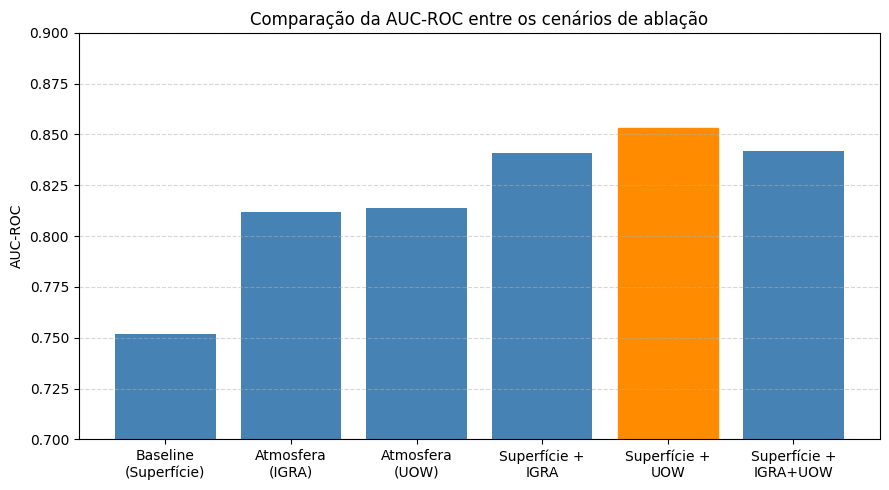

In [ ]:
import matplotlib.pyplot as plt

# Cenários e valores de AUC
cenarios = [
    "Baseline\n(Superfície)",
    "Atmosfera\n(IGRA)",
    "Atmosfera\n(UOW)",
    "Superfície +\nIGRA",
    "Superfície +\nUOW",
    "Superfície +\nIGRA+UOW"
]

auc = [
    0.752,
    0.812,
    0.814,
    0.841,
    0.853,
    0.842
]

plt.figure(figsize=(9, 5))
bars = plt.bar(cenarios, auc, color="steelblue")

# Destacar o melhor modelo
bars[4].set_color("darkorange")

plt.ylabel("AUC-ROC")
plt.ylim(0.70, 0.90)
plt.title("Comparação da AUC-ROC entre os cenários de ablação")

# Grid leve
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Ajuste de layout
plt.tight_layout()

plt.show()


In [ ]:
print(df.head())

   index  id observation_datetime  rain_mm  rain_1h  latitude  longitude   m5  \
0    278   1  2012-01-12 14:00:00      0.0        0  -22.8636   -43.2636  0.0   
1    279   1  2012-01-12 15:00:00      0.0        0  -22.8636   -43.2636  0.0   
2    280   1  2012-01-12 16:00:00      0.0        0  -22.8636   -43.2636  0.0   
3    281   1  2012-01-12 17:00:00      0.0        0  -22.8636   -43.2636  0.0   
4    282   1  2012-01-12 18:00:00      0.0        0  -22.8636   -43.2636  0.0   

   h04  h24  h96  mes  
0  0.0  0.0  0.0    1  
1  0.0  0.0  0.0    1  
2  0.0  0.0  0.0    1  
3  0.0  0.0  0.0    1  
4  0.0  0.0  0.0    1  


# SATELITE

### SÓ SATELITE

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# CARREGAR DATASET E
# ============================================================

path = Path("data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet")

df = pd.read_parquet(path)

df["observation_datetime"] = pd.to_datetime(
    df["observation_datetime"],
    errors="coerce"
)

df = df.sort_values(["observation_datetime", "id"]).reset_index(drop=True)

print(df.shape)
print(df.tail())
display(df.head())

(1296985, 23)


,id,observation_datetime,rain_mm,latitude,longitude,rain_next_1h_mm,rain_1h,sat_TPWF_goes_pixel_lat,sat_TPWF_goes_pixel_lon,sat_TPWF_TPW,...,sat_DSIF_goes_pixel_lon,sat_DSIF_CAPE,sat_DSIF_LI,sat_DSIF_KI,sat_DSIF_SI,sat_DSIF_TT,sat_DSIF_datetime,sat_DSIF_time_diff_minutes,target_intensidade,target_regressao
0,1,2019-12-07 21:00:00,0.0,-22.8636,-43.2636,0.0,0,-22.879545,-43.309921,17.680468,...,-43.309921,0.0,10.267071,-6.881508,17.722980,14.873676,2019-12-07 21:00:19,0.316667,0,0.0
1,2,2019-12-07 21:00:00,0.0,-22.8547,-43.2725,0.0,0,-22.879545,-43.309921,17.680468,...,-43.309921,0.0,10.267071,-6.881508,17.722980,14.873676,2019-12-07 21:00:19,0.316667,0,0.0
2,3,2019-12-07 21:00:00,0.0,-22.9327,-43.2567,0.0,0,-22.985749,-43.276217,17.411888,...,-43.276217,0.0,10.192297,-8.773159,17.928078,14.350266,2019-12-07 21:00:19,0.316667,0,0.0
3,4,2019-12-07 21:00:00,0.0,-22.8595,-43.2657,0.0,0,-22.879545,-43.309921,17.680468,...,-43.309921,0.0,10.267071,-6.881508,17.722980,14.873676,2019-12-07 21:00:19,0.316667,0,0.0
4,5,2019-12-07 21:00:00,0.0,-22.9023,-43.3434,0.0,0,-22.879545,-43.309921,17.680468,...,-43.309921,0.0,10.267071,-6.881508,17.722980,14.873676,2019-12-07 21:00:19,0.316667,0,0.0


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

DATASET_PATH = Path("data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet")

df = pd.read_parquet(DATASET_PATH)

df["observation_datetime"] = pd.to_datetime(
    df["observation_datetime"],
    errors="coerce"
)

print("Shape inicial:", df.shape)

print("\nColunas:")
print(df.columns.tolist())

print("\nNulos por coluna:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicatas id + observation_datetime:")
print(df.duplicated(subset=["id", "observation_datetime"]).sum())

print("\nResumo numérico:")
display(df.describe().T)

Shape inicial: (1296985, 23)

Colunas:
['id', 'observation_datetime', 'rain_mm', 'latitude', 'longitude', 'rain_next_1h_mm', 'rain_1h', 'sat_TPWF_goes_pixel_lat', 'sat_TPWF_goes_pixel_lon', 'sat_TPWF_TPW', 'sat_TPWF_datetime', 'sat_TPWF_time_diff_minutes', 'sat_DSIF_goes_pixel_lat', 'sat_DSIF_goes_pixel_lon', 'sat_DSIF_CAPE', 'sat_DSIF_LI', 'sat_DSIF_KI', 'sat_DSIF_SI', 'sat_DSIF_TT', 'sat_DSIF_datetime', 'sat_DSIF_time_diff_minutes', 'target_intensidade', 'target_regressao']

Nulos por coluna:
id                            0
observation_datetime          0
rain_mm                       0
latitude                      0
longitude                     0
rain_next_1h_mm               0
rain_1h                       0
sat_TPWF_goes_pixel_lat       0
sat_TPWF_goes_pixel_lon       0
sat_TPWF_TPW                  0
sat_TPWF_datetime             0
sat_TPWF_time_diff_minutes    0
sat_DSIF_goes_pixel_lat       0
sat_DSIF_goes_pixel_lon       0
sat_DSIF_CAPE                 0
sat_DSIF_LI         

,count,mean,min,25%,50%,75%,max,std
id,1296985.0,42.250195,1.0,22.0,42.0,63.0,83.0,23.919503
observation_datetime,1296985,2022-07-19 20:51:13.988673536,2019-12-07 21:00:00,2021-02-16 17:00:00,2022-05-06 06:00:00,2023-12-29 09:00:00,2025-04-07 17:00:00,NaN
rain_mm,1296985.0,0.009915,0.0,0.0,0.0,0.0,40.6,0.222248
latitude,1296985.0,-22.9086,-22.9974,-22.9315,-22.9142,-22.8652,-22.8344,0.0407
longitude,1296985.0,-43.260398,-43.3594,-43.2942,-43.2636,-43.2169,-43.1679,0.047494
rain_next_1h_mm,1296985.0,0.01365,0.0,0.0,0.0,0.0,60.0,0.321673
rain_1h,1296985.0,0.000507,0.0,0.0,0.0,0.0,1.0,0.022518
sat_TPWF_goes_pixel_lat,1296985.0,-22.90349,-22.990395,-22.88416,-22.879545,-22.879545,-22.879545,0.0433
sat_TPWF_goes_pixel_lon,1296985.0,-43.260019,-43.309921,-43.309921,-43.309921,-43.181594,-43.147695,0.061514
sat_TPWF_TPW,1296985.0,33.766003,10.041212,26.775547,33.317596,40.128223,68.278709,9.361695


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_parquet("data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE.parquet")

cape = df["sat_DSIF_CAPE"]

print("Total de linhas:", len(df))
print("CAPE nulo:", cape.isna().sum())
print("CAPE == 0:", (cape == 0).sum())
print("CAPE > 0:", (cape > 0).sum())

print("\nPercentuais:")
print("CAPE == 0:", round((cape == 0).mean() * 100, 2), "%")
print("CAPE > 0:", round((cape > 0).mean() * 100, 2), "%")

print("\nResumo CAPE:")
print(cape.describe())

print("\nQuantis CAPE:")
print(cape.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]))

print("CAPE em casos sem chuva:")
print(df[df["rain_next_1h_mm"] == 0]["sat_DSIF_CAPE"].describe())

print("\nCAPE em casos com qualquer chuva:")
print(df[df["rain_next_1h_mm"] > 0]["sat_DSIF_CAPE"].describe())

print("\nCAPE em casos com chuva > 5 mm:")
print(df[df["rain_next_1h_mm"] > 5]["sat_DSIF_CAPE"].describe())

print("\nCAPE em casos com chuva > 25 mm:")
print(df[df["rain_next_1h_mm"] > 25]["sat_DSIF_CAPE"].describe())


Total de linhas: 1204431
CAPE nulo: 0
CAPE == 0: 795775
CAPE > 0: 408656

Percentuais:
CAPE == 0: 66.07 %
CAPE > 0: 33.93 %

Resumo CAPE:
count    1.204431e+06
mean     3.808276e+01
std      9.562548e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.464978e+01
max      1.139936e+03
Name: sat_DSIF_CAPE, dtype: float64

Quantis CAPE:
0.00       0.000000
0.25       0.000000
0.50       0.000000
0.75      14.649778
0.90     137.952072
0.95     244.773376
0.99     468.182495
1.00    1139.935791
Name: sat_DSIF_CAPE, dtype: float64
CAPE em casos sem chuva:
count    1.189255e+06
mean     3.796214e+01
std      9.559575e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.426827e+01
max      1.139936e+03
Name: sat_DSIF_CAPE, dtype: float64

CAPE em casos com qualquer chuva:
count    15176.000000
mean        47.535040
std         97.466791
min          0.000000
25%          0.000000
50%          7.935297
75%         40.439491
max        91

In [ ]:
# ==================================================
# DEFINIR X E Y - DATASET E GOES
# ==================================================

import pandas as pd
import numpy as np

df = pd.read_parquet(
    "data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet"
)

y_binario = df["rain_1h"]
y_intensidade = df["target_intensidade"]
y_regressao = df["target_regressao"]

X_goes = df.drop(columns=[
    # identificadores
    "id",
    "observation_datetime",

    # chuva observada e alvos
    "rain_1h",
    "rain_mm",
    "rain_next_1h_mm",
    "target_intensidade",
    "target_regressao",

    # localização da estação
    "latitude",
    "longitude",

    # metadados técnicos do GOES
    "sat_TPWF_datetime",
    "sat_DSIF_datetime",
    "sat_TPWF_time_diff_minutes",
    "sat_DSIF_time_diff_minutes",
    "sat_TPWF_goes_pixel_lat",
    "sat_TPWF_goes_pixel_lon",
    "sat_DSIF_goes_pixel_lat",
    "sat_DSIF_goes_pixel_lon",
], errors="ignore")

print("Colunas usadas no X_goes:")
print(X_goes.columns.tolist())

print("\nShape X_goes:", X_goes.shape)
print("Shape y_binario:", y_binario.shape)
print("Shape y_intensidade:", y_intensidade.shape)
print("Shape y_regressao:", y_regressao.shape)

Colunas usadas no X_goes:
['sat_TPWF_TPW', 'sat_DSIF_CAPE', 'sat_DSIF_LI', 'sat_DSIF_KI', 'sat_DSIF_SI', 'sat_DSIF_TT']

Shape X_goes: (1296985, 6)
Shape y_binario: (1296985,)
Shape y_intensidade: (1296985,)
Shape y_regressao: (1296985,)


In [ ]:
# ==================================================
# 2. FUNÇÃO DE SPLIT TEMPORAL
# ==================================================

def split_temporal(df, X, y):
    train_end = "2023-01-01"
    val_end = "2024-01-01"

    df = df.copy()
    df["observation_datetime"] = pd.to_datetime(df["observation_datetime"])

    mask_train = df["observation_datetime"] < train_end

    mask_val = (
        (df["observation_datetime"] >= train_end) &
        (df["observation_datetime"] < val_end)
    )

    mask_test = df["observation_datetime"] >= val_end

    X_train = X.loc[mask_train].copy()
    y_train = y.loc[mask_train].copy()

    X_val = X.loc[mask_val].copy()
    y_val = y.loc[mask_val].copy()

    X_test = X.loc[mask_test].copy()
    y_test = y.loc[mask_test].copy()

    print("Treino:", X_train.shape)
    print("Validação:", X_val.shape)
    print("Teste:", X_test.shape)

    print("\nPeríodo treino:")
    print(df.loc[mask_train, "observation_datetime"].min(), "->", df.loc[mask_train, "observation_datetime"].max())

    print("\nPeríodo validação:")
    print(df.loc[mask_val, "observation_datetime"].min(), "->", df.loc[mask_val, "observation_datetime"].max())

    print("\nPeríodo teste:")
    print(df.loc[mask_test, "observation_datetime"].min(), "->", df.loc[mask_test, "observation_datetime"].max())

    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
#Random forest binario
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)

y = y_binario

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

Treino: (739436, 6)
Validação: (234236, 6)
Teste: (323313, 6)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
#Random forest binario
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)

y = y_binario

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

rf_bin = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train, y_train)

y_val_prob = rf_bin.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val, y_val_pred, zero_division=0))
print("AUC VAL:", roc_auc_score(y_val, y_val_prob))
print("Brier VAL:", brier_score_loss(y_val, y_val_prob))
print("PR AUC VAL:", average_precision_score(y_val, y_val_prob))

y_test_prob = rf_bin.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob))

Treino: (739436, 6)
Validação: (234236, 6)
Teste: (323313, 6)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00


TypeError: cannot unpack non-iterable NoneType object

In [ ]:

# ==================================================
# RANDOM FOREST MULTICLASSE - GOES
# ==================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# alvo multiclasse
y = y_intensidade

# split temporal
X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

# modelo multiclasse
rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# treino
rf_multi.fit(X_train, y_train)

print("Classes vistas pelo modelo:", rf_multi.classes_)


# ==================================================
# FUNÇÃO PARA AUC MULTICLASSE SEGURA
# ==================================================

def auc_multiclasse_seguro(y_true, y_prob, classes_modelo, labels=[0, 1, 2, 3]):
    """
    Garante que y_prob tenha uma coluna para cada classe esperada.
    Se o modelo não aprendeu alguma classe, a probabilidade dela fica 0.
    """

    prob_full = np.zeros((len(y_true), len(labels)))

    for i, classe in enumerate(classes_modelo):
        if classe in labels:
            idx = labels.index(classe)
            prob_full[:, idx] = y_prob[:, i]

    return roc_auc_score(
        y_true,
        prob_full,
        labels=labels,
        multi_class="ovr",
        average="macro"
    )


# ==================================================
# VALIDAÇÃO
# ==================================================

y_val_prob = rf_multi.predict_proba(X_val)
y_val_pred = rf_multi.predict(X_val)

print("=== VALIDAÇÃO ===")
print(
    classification_report(
        y_val,
        y_val_pred,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

print(
    "AUC VAL:",
    auc_multiclasse_seguro(
        y_val,
        y_val_prob,
        rf_multi.classes_,
        labels=[0, 1, 2, 3]
    )
)


# ==================================================
# TESTE FINAL
# ==================================================

y_test_prob = rf_multi.predict_proba(X_test)
y_test_pred = rf_multi.predict(X_test)

print("=== TESTE FINAL ===")
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

print(
    "AUC TEST:",
    auc_multiclasse_seguro(
        y_test,
        y_test_prob,
        rf_multi.classes_,
        labels=[0, 1, 2, 3]
    )
)

Treino: (739436, 6)
Validação: (234236, 6)
Teste: (323313, 6)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
Classes vistas pelo modelo: [0 1 2]
=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    234185
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         0

    accuracy                           0.99    234236
   macro avg       0.25      0.25      0.25    234236
weighted avg       1.00      0.99      1.00    234236



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


AUC VAL: nan
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323146
           1       0.01      0.08      0.02       149
           2       0.00      0.00      0.00        16
           3       0.00      0.00      0.00         2

    accuracy                           1.00    323313
   macro avg       0.25      0.27      0.25    323313
weighted avg       1.00      1.00      1.00    323313

AUC TEST: 0.6933587303492329


In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

y = y_regressao
X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# treino
rf_reg.fit(X_train, y_train)

# previsão na validação
y_val_pred = rf_reg.predict(X_val)

# métricas validação
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)



from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred = rf_reg.predict(X_test)

# métricas TESTE
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)


Treino: (739436, 6)
Validação: (234236, 6)
Teste: (323313, 6)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
=== VALIDAÇÃO ===
MAE: 0.020187874433082436
RMSE: 0.222364765330147
R²: -0.0951366952171302
=== TESTE FINAL ===
MAE TEST: 0.02566630823211883
RMSE TEST: 0.3929962528218447
R² TEST: -0.015828732821388636


In [ ]:
#Catboost binario
import numpy as np
from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)


y = y_binario

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)



cat_bin = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    random_seed=42,
    verbose=50
)

cat_bin.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

y_test_prob = cat_bin.predict_proba(X_test)[:, 1]
Path("resultados_roc").mkdir(parents=True, exist_ok=True)

np.savez(
    "resultados_roc/roc_goes16_catboost.npz",
    y_test=np.asarray(y_test),
    y_prob=np.asarray(y_test_prob)
)

y_test_pred = (y_test_prob >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob))

Treino: (739436, 6)
Validação: (234236, 6)
Teste: (323313, 6)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
0:	test: 0.5648876	best: 0.5648876 (0)	total: 505ms	remaining: 1m 15s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.7648055187
bestIteration = 28

Shrink model to first 29 iterations.
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323146
           1       0.00      0.00      0.00       167

    accuracy                           1.00    323313
   macro avg       0.50      0.50      0.50    323313
weighted avg       1.00      1.00      1.00    323313

AUC TEST: 0.8797991182569597
Brier TEST: 0.052032938806031534
PR AUC TEST: 0.006901176093548759


In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob))

=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227912
           1       0.00      0.00      0.00       112

    accuracy                           1.00    228024
   macro avg       0.50      0.50      0.50    228024
weighted avg       1.00      1.00      1.00    228024

AUC TEST: 0.8721626345130702
Brier TEST: 0.05622650197332941
PR AUC TEST: 0.009257874157895385


In [ ]:
# ==================================================
# CATBOOST MULTICLASSE - GOES
# ==================================================

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

# ==================================================
# FUNÇÃO PARA AUC MULTICLASSE SEGURA
# ==================================================

def auc_multiclasse_ovr_seguro(y_true, y_prob, classes_modelo, labels=[0, 1, 2, 3]):
    """
    Calcula AUC Macro OvR mesmo quando alguma classe aparece no teste,
    mas não apareceu no treino/modelo.
    """

    y_true = pd.Series(y_true).reset_index(drop=True)

    aucs = {}

    for classe in labels:
        y_bin = (y_true == classe).astype(int)

        # Se a classe não aparece no y_true, pula
        if y_bin.nunique() < 2:
            continue

        # Se o modelo aprendeu essa classe, pega a probabilidade dela
        if classe in classes_modelo:
            idx = list(classes_modelo).index(classe)
            prob_classe = y_prob[:, idx]
        else:
            # Se o modelo não aprendeu essa classe, probabilidade 0
            prob_classe = np.zeros(len(y_true))

        aucs[classe] = roc_auc_score(y_bin, prob_classe)

    auc_macro = np.mean(list(aucs.values()))

    return auc_macro, aucs


# ==================================================
# TREINO MULTICLASSE
# ==================================================

y = y_intensidade

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

cat_multi = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.03,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

cat_multi.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

print("Classes vistas pelo CatBoost:")
print(cat_multi.classes_)

print("\nClasses no teste:")
print(sorted(y_test.unique()))


# ==================================================
# AVALIAÇÃO NO TESTE
# ==================================================

y_test_pred = cat_multi.predict(X_test).ravel()
y_test_prob = cat_multi.predict_proba(X_test)

print("=== TESTE FINAL ===")
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

print("F1 Macro:", f1_score(y_test, y_test_pred, average="macro"))
print(
    "Precision Macro:",
    precision_score(y_test, y_test_pred, average="macro", zero_division=0)
)
print(
    "Recall Macro:",
    recall_score(y_test, y_test_pred, average="macro", zero_division=0)
)

auc_macro, auc_por_classe = auc_multiclasse_ovr_seguro(
    y_test,
    y_test_prob,
    cat_multi.classes_,
    labels=[0, 1, 2, 3]
)

print("AUC Macro:", auc_macro)
print("AUC por classe:", auc_por_classe)

Treino: (739436, 6)
Validação: (234236, 6)
Teste: (323313, 6)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
0:	learn: 0.5932139	test: 0.5090515	best: 0.5090515 (0)	total: 743ms	remaining: 1m 50s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.6477834583
bestIteration = 1

Shrink model to first 2 iterations.
Classes vistas pelo CatBoost:
[0 1 2]

Classes no teste:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.76      0.86    323146
           1       0.00      0.26      0.00       149
           2       0.00      1.00      0.00        16
           3       0.00      0.00      0.00         2

    accuracy                           0.76    323313
   macro avg       0.25      0.50      0.22    323313
weighted avg       1.00  

In [ ]:
# ==================================================
# CATBOOST REGRESSÃO - GOES
# ==================================================

from catboost import CatBoostRegressor
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y = y_regressao

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

cat_reg = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# Treina no treino e usa validação para acompanhar desempenho
cat_reg.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred = cat_reg.predict(X_val)

# Como chuva não pode ser negativa
y_val_pred = np.maximum(y_val_pred, 0)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)


# =========================================
# TESTE FINAL
# =========================================

y_test_pred = cat_reg.predict(X_test)

# Como chuva não pode ser negativa
y_test_pred = np.maximum(y_test_pred, 0)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)

Treino: (739436, 6)
Validação: (234236, 6)
Teste: (323313, 6)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
0:	learn: 0.3172585	test: 0.2126807	best: 0.2126807 (0)	total: 75.7ms	remaining: 11.3s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.2126733824
bestIteration = 10

Shrink model to first 11 iterations.
=== VALIDAÇÃO ===
RMSE VAL: 0.21267338118414658
MAE VAL: 0.022891433694178523
R² VAL: -0.0017576272915806879
=== TESTE FINAL ===
RMSE TEST: 0.38986024276853665
MAE TEST: 0.028374682231031324
R² TEST: 0.0003186923068826397


### WEBSINE + SATELITE

In [ ]:

df_d = pd.read_parquet(
    "data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip"
);
print(df_d.head());

   index  id observation_datetime  rain_mm  rain_next_1h_mm  rain_1h  \
0    278   1  2012-01-12 14:00:00      0.0              0.0        0   
1    279   1  2012-01-12 15:00:00      0.0              0.0        0   
2    280   1  2012-01-12 16:00:00      0.0              0.0        0   
3    281   1  2012-01-12 17:00:00      0.0              0.0        0   
4    282   1  2012-01-12 18:00:00      0.0              0.0        0   

   latitude  longitude   m5  h04  h24  h96  mes  target_intensidade  \
0  -22.8636   -43.2636  0.0  0.0  0.0  0.0    1                   0   
1  -22.8636   -43.2636  0.0  0.0  0.0  0.0    1                   0   
2  -22.8636   -43.2636  0.0  0.0  0.0  0.0    1                   0   
3  -22.8636   -43.2636  0.0  0.0  0.0  0.0    1                   0   
4  -22.8636   -43.2636  0.0  0.0  0.0  0.0    1                   0   

   target_regressao  
0               0.0  
1               0.0  
2               0.0  
3               0.0  
4               0.0  


In [ ]:
import pandas as pd

# ==================================================
# 1. LER DATASET E - GOES + LABELS WEBSIRENE
# ==================================================

df_e = pd.read_parquet(
    "data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet"
)

# ==================================================
# 2. LER DATASET D - WEBSIRENE SUPERFÍCIE
# ==================================================

df_d = pd.read_parquet(
    "data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip"
)

# Pegar só as features de superfície que você quer usar
surface_cols = [
    "id",
    "observation_datetime",
    "h04",
    "h24",
    "h96",
    "mes"
]

surface_feat = df_d[surface_cols].copy()

# ==================================================
# 3. AJUSTAR DATAS
# ==================================================

df_e["observation_datetime"] = (
    pd.to_datetime(df_e["observation_datetime"])
    .dt.tz_localize(None)
)

surface_feat["observation_datetime"] = (
    pd.to_datetime(surface_feat["observation_datetime"])
    .dt.tz_localize(None)
)

# ==================================================
# 4. MERGE: SATÉLITE + WEBSIRENE
# ==================================================

df = pd.merge(
    df_e,
    surface_feat,
    on=["id", "observation_datetime"],
    how="inner"
)

print("Dataset Satélite + WebSirene:", df.shape)
print(df.columns.tolist())

Dataset Satélite + WebSirene: (1252728, 27)
['id', 'observation_datetime', 'rain_mm', 'latitude', 'longitude', 'rain_next_1h_mm', 'rain_1h', 'sat_TPWF_goes_pixel_lat', 'sat_TPWF_goes_pixel_lon', 'sat_TPWF_TPW', 'sat_TPWF_datetime', 'sat_TPWF_time_diff_minutes', 'sat_DSIF_goes_pixel_lat', 'sat_DSIF_goes_pixel_lon', 'sat_DSIF_CAPE', 'sat_DSIF_LI', 'sat_DSIF_KI', 'sat_DSIF_SI', 'sat_DSIF_TT', 'sat_DSIF_datetime', 'sat_DSIF_time_diff_minutes', 'target_intensidade', 'target_regressao', 'h04', 'h24', 'h96', 'mes']


#### Entrada satelite + websirene

In [ ]:
# ==================================================
# 5. DEFINIR X E Y
# ==================================================

y_binario = df["rain_1h"]
y_intensidade = df["target_intensidade"]
y_regressao = df["target_regressao"]

X_goes = df.drop(columns=[
    # identificadores
    "id",
    "observation_datetime",

    # alvos e chuva futura
    "rain_1h",
    "rain_next_1h_mm",
    "target_intensidade",
    "target_regressao",

    # localização
    "latitude",
    "longitude",

    # metadados técnicos do GOES
    "sat_TPWF_datetime",
    "sat_DSIF_datetime",
    "sat_TPWF_time_diff_minutes",
    "sat_DSIF_time_diff_minutes",
    "sat_TPWF_goes_pixel_lat",
    "sat_TPWF_goes_pixel_lon",
    "sat_DSIF_goes_pixel_lat",
    "sat_DSIF_goes_pixel_lon",
], errors="ignore")

print("Features Satélite + WebSirene:")
print(X_goes.columns.tolist())
print("Shape X:", X_goes.shape)

Features Satélite + WebSirene:
['rain_mm', 'sat_TPWF_TPW', 'sat_DSIF_CAPE', 'sat_DSIF_LI', 'sat_DSIF_KI', 'sat_DSIF_SI', 'sat_DSIF_TT', 'h04', 'h24', 'h96', 'mes']
Shape X: (1252728, 11)


In [ ]:
# ==================================================
# 2. FUNÇÃO DE SPLIT TEMPORAL
# ==================================================

def split_temporal(df, X, y):
    train_end = "2023-01-01"
    val_end = "2024-01-01"

    df = df.copy()
    df["observation_datetime"] = pd.to_datetime(df["observation_datetime"])

    mask_train = df["observation_datetime"] < train_end

    mask_val = (
        (df["observation_datetime"] >= train_end) &
        (df["observation_datetime"] < val_end)
    )

    mask_test = df["observation_datetime"] >= val_end

    X_train = X.loc[mask_train].copy()
    y_train = y.loc[mask_train].copy()

    X_val = X.loc[mask_val].copy()
    y_val = y.loc[mask_val].copy()

    X_test = X.loc[mask_test].copy()
    y_test = y.loc[mask_test].copy()

    print("Treino:", X_train.shape)
    print("Validação:", X_val.shape)
    print("Teste:", X_test.shape)

    print("\nPeríodo treino:")
    print(df.loc[mask_train, "observation_datetime"].min(), "->", df.loc[mask_train, "observation_datetime"].max())

    print("\nPeríodo validação:")
    print(df.loc[mask_val, "observation_datetime"].min(), "->", df.loc[mask_val, "observation_datetime"].max())

    print("\nPeríodo teste:")
    print(df.loc[mask_test, "observation_datetime"].min(), "->", df.loc[mask_test, "observation_datetime"].max())

    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
#Random forest binario
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)

y = y_binario

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

rf_bin = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train, y_train)

y_val_prob = rf_bin.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("=== VALIDAÇÃO ===")
print(classification_report(y_val, y_val_pred, zero_division=0))
print("AUC VAL:", roc_auc_score(y_val, y_val_prob))
print("Brier VAL:", brier_score_loss(y_val, y_val_prob))
print("PR AUC VAL:", average_precision_score(y_val, y_val_prob))

y_test_prob = rf_bin.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob))


Treino: (721689, 11)
Validação: (226193, 11)
Teste: (304846, 11)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    226145
           1       0.00      0.04      0.00        48

    accuracy                           0.98    226193
   macro avg       0.50      0.51      0.50    226193
weighted avg       1.00      0.98      0.99    226193

AUC VAL: 0.7734842873672496
Brier VAL: 0.013545606396063248
PR AUC VAL: 0.0007323883655143137
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    304692
           1       0.01      0.26      0.02       154

    accuracy                           0.99    304846
   macro avg       0.51      0.62      0.51    304846
weighted avg       1.0

In [ ]:

# ==================================================
# RANDOM FOREST MULTICLASSE - GOES
# ==================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# alvo multiclasse
y = y_intensidade

# split temporal
X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

# modelo multiclasse
rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# treino
rf_multi.fit(X_train, y_train)

print("Classes vistas pelo modelo:", rf_multi.classes_)

# ==================================================
# FUNÇÃO PARA AUC MULTICLASSE SEGURA
# ==================================================

def auc_multiclasse_seguro(y_true, y_prob, classes_modelo, labels=[0, 1, 2, 3]):
    """
    Garante que y_prob tenha uma coluna para cada classe esperada.
    Se o modelo não aprendeu alguma classe, a probabilidade dela fica 0.
    """

    prob_full = np.zeros((len(y_true), len(labels)))

    for i, classe in enumerate(classes_modelo):
        if classe in labels:
            idx = labels.index(classe)
            prob_full[:, idx] = y_prob[:, i]

    return roc_auc_score(
        y_true,
        prob_full,
        labels=labels,
        multi_class="ovr",
        average="macro"
    )

# ==================================================
# VALIDAÇÃO
# ==================================================

y_val_prob = rf_multi.predict_proba(X_val)
y_val_pred = rf_multi.predict(X_val)

print("=== VALIDAÇÃO ===")
print(
    classification_report(
        y_val,
        y_val_pred,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

print(
    "AUC VAL:",
    auc_multiclasse_seguro(
        y_val,
        y_val_prob,
        rf_multi.classes_,
        labels=[0, 1, 2, 3]
    )
)

# ==================================================
# TESTE FINAL
# ==================================================

y_test_prob = rf_multi.predict_proba(X_test)
y_test_pred = rf_multi.predict(X_test)

print("=== TESTE FINAL ===")
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

print(
    "AUC TEST:",
    auc_multiclasse_seguro(
        y_test,
        y_test_prob,
        rf_multi.classes_,
        labels=[0, 1, 2, 3]
    )
)


Treino: (721689, 11)
Validação: (226193, 11)
Teste: (304846, 11)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
Classes vistas pelo modelo: [0 1 2]
=== VALIDAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226145
           1       0.00      0.00      0.00        47
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         0

    accuracy                           1.00    226193
   macro avg       0.25      0.25      0.25    226193
weighted avg       1.00      1.00      1.00    226193



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


AUC VAL: nan
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    304692
           1       0.00      0.00      0.00       137
           2       0.00      0.00      0.00        15
           3       0.00      0.00      0.00         2

    accuracy                           1.00    304846
   macro avg       0.25      0.25      0.25    304846
weighted avg       1.00      1.00      1.00    304846

AUC TEST: 0.7067918480318713


In [ ]:
print("=== DISTRIBUIÇÃO TREINO ===")
print(y_train.value_counts().sort_index())

print("\n=== DISTRIBUIÇÃO VALIDAÇÃO ===")
print(y_val.value_counts().sort_index())

print("\n=== DISTRIBUIÇÃO TESTE ===")
print(y_test.value_counts().sort_index())

print(X_train.columns.tolist())
print(X_train.shape)

=== DISTRIBUIÇÃO TREINO ===
target_intensidade
0    721261
1       421
2         7
Name: count, dtype: int64

=== DISTRIBUIÇÃO VALIDAÇÃO ===
target_intensidade
0    226145
1        47
2         1
Name: count, dtype: int64

=== DISTRIBUIÇÃO TESTE ===
target_intensidade
0    304692
1       137
2        15
3         2
Name: count, dtype: int64
['rain_mm', 'sat_TPWF_TPW', 'sat_DSIF_CAPE', 'sat_DSIF_LI', 'sat_DSIF_KI', 'sat_DSIF_SI', 'sat_DSIF_TT', 'h04', 'h24', 'h96', 'mes']
(721689, 11)


In [ ]:
#Random Forest (regressao - é mais diferente)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

y = y_regressao
X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

# modelo
rf_reg = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# treino
rf_reg.fit(X_train, y_train)

# previsão na validação
y_val_pred = rf_reg.predict(X_val)

# métricas validação
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# previsão no TESTE
y_test_pred = rf_reg.predict(X_test)

# métricas TESTE
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("MAE TEST:", mae_test)
print("RMSE TEST:", rmse_test)
print("R² TEST:", r2_test)


Treino: (721689, 11)
Validação: (226193, 11)
Teste: (304846, 11)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
=== VALIDAÇÃO ===
MAE: 0.016407656112514265
RMSE: 0.21546050216490284
R²: -0.03810604537333662
=== TESTE FINAL ===
MAE TEST: 0.02034886370228323
RMSE TEST: 0.38604699647127827
R² TEST: 0.004003789710251393


In [ ]:
#Catboost binario

from catboost import CatBoostClassifier
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)

y = y_binario

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

cat_bin = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    random_seed=42,
    verbose=50
)

cat_bin.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

y_test_prob = cat_bin.predict_proba(X_test)[:, 1]
Path("resultados_roc").mkdir(parents=True, exist_ok=True)

np.savez(
    "resultados_roc/roc_goes16_websirene_catboost.npz",
    y_test=np.asarray(y_test),
    y_prob=np.asarray(y_test_prob)
)
y_test_pred = (y_test_prob >= 0.5).astype(int)



print("=== TESTE FINAL ===")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("AUC TEST:", roc_auc_score(y_test, y_test_prob))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob))
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob))



Treino: (721689, 11)
Validação: (226193, 11)
Teste: (304846, 11)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
0:	test: 0.7115157	best: 0.7115157 (0)	total: 183ms	remaining: 27.2s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.8197031127
bestIteration = 11

Shrink model to first 12 iterations.
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    304692
           1       0.05      0.14      0.07       154

    accuracy                           1.00    304846
   macro avg       0.52      0.57      0.53    304846
weighted avg       1.00      1.00      1.00    304846

AUC TEST: 0.9404512344678152
Brier TEST: 0.1259801226560624
PR AUC TEST: 0.04555552766200582


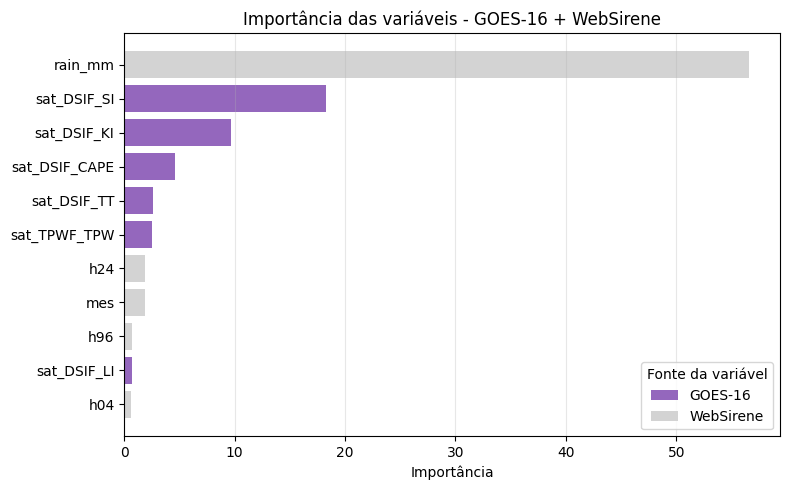

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==================================================
# IMPORTÂNCIA DAS VARIÁVEIS - CATBOOST
# CENÁRIO: GOES-16 + WEBSIRENE
# ==================================================

importances = cat_bin.get_feature_importance()
feature_names = X_train.columns

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

category = {
    # GOES-16
    "sat_TPWF_TPW": "GOES-16",
    "sat_DSIF_CAPE": "GOES-16",
    "sat_DSIF_LI": "GOES-16",
    "sat_DSIF_KI": "GOES-16",
    "sat_DSIF_SI": "GOES-16",
    "sat_DSIF_TT": "GOES-16",

    # WebSirene
    "rain_mm": "WebSirene",
    "h04": "WebSirene",
    "h24": "WebSirene",
    "h96": "WebSirene",
    "mes": "WebSirene",
}

colors = {
    "GOES-16": "tab:purple",
    "WebSirene": "lightgray",
}

df_importance["categoria"] = (
    df_importance["feature"]
    .map(category)
    .fillna("Outras")
)

df_top = df_importance.head(12)

plt.figure(figsize=(8, 5))

plt.barh(
    df_top["feature"],
    df_top["importance"],
    color=df_top["categoria"].map(colors)
)

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.title("Importância das variáveis - GOES-16 + WebSirene")
plt.grid(axis="x", alpha=0.3)

legend_elements = [
    Patch(facecolor=colors["GOES-16"], label="GOES-16"),
    Patch(facecolor=colors["WebSirene"], label="WebSirene"),
]

plt.legend(
    handles=legend_elements,
    title="Fonte da variável",
    loc="lower right"
)

plt.tight_layout()
plt.savefig("importance_goes_websirene_catboost.png", dpi=300)
plt.show()

In [ ]:
# ==================================================
# CATBOOST MULTICLASSE - GOES
# ==================================================

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

# ==================================================
# FUNÇÃO PARA AUC MULTICLASSE SEGURA
# ==================================================

def auc_multiclasse_ovr_seguro(y_true, y_prob, classes_modelo, labels=[0, 1, 2, 3]):
    """
    Calcula AUC Macro OvR mesmo quando alguma classe aparece no teste,
    mas não apareceu no treino/modelo.
    """

    y_true = pd.Series(y_true).reset_index(drop=True)

    aucs = {}

    for classe in labels:
        y_bin = (y_true == classe).astype(int)

        # Se a classe não aparece no y_true, pula
        if y_bin.nunique() < 2:
            continue

        # Se o modelo aprendeu essa classe, pega a probabilidade dela
        if classe in classes_modelo:
            idx = list(classes_modelo).index(classe)
            prob_classe = y_prob[:, idx]
        else:
            # Se o modelo não aprendeu essa classe, probabilidade 0
            prob_classe = np.zeros(len(y_true))

        aucs[classe] = roc_auc_score(y_bin, prob_classe)

    auc_macro = np.mean(list(aucs.values()))

    return auc_macro, aucs

# ==================================================
# TREINO MULTICLASSE
# ==================================================

y = y_intensidade

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

cat_multi = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.03,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

cat_multi.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

print("Classes vistas pelo CatBoost:")
print(cat_multi.classes_)

print("\nClasses no teste:")
print(sorted(y_test.unique()))

# ==================================================
# AVALIAÇÃO NO TESTE
# ==================================================

y_test_pred = cat_multi.predict(X_test).ravel()
y_test_prob = cat_multi.predict_proba(X_test)

print("=== TESTE FINAL ===")
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

print("F1 Macro:", f1_score(y_test, y_test_pred, average="macro"))
print(
    "Precision Macro:",
    precision_score(y_test, y_test_pred, average="macro", zero_division=0)
)
print(
    "Recall Macro:",
    recall_score(y_test, y_test_pred, average="macro", zero_division=0)
)

auc_macro, auc_por_classe = auc_multiclasse_ovr_seguro(
    y_test,
    y_test_prob,
    cat_multi.classes_,
    labels=[0, 1, 2, 3]
)

print("AUC Macro:", auc_macro)
print("AUC por classe:", auc_por_classe)



Treino: (721689, 11)
Validação: (226193, 11)
Teste: (304846, 11)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
0:	learn: 0.7705129	test: 0.5475268	best: 0.5475268 (0)	total: 433ms	remaining: 1m 4s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.5520982097
bestIteration = 1

Shrink model to first 2 iterations.
Classes vistas pelo CatBoost:
[0 1 2]

Classes no teste:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
=== TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    304692
           1       0.00      0.64      0.00       137
           2       0.00      0.00      0.00        15
           3       0.00      0.00      0.00         2

    accuracy                           0.84    304846
   macro avg       0.25      0.37      0.23    304846
weighted avg       1.00

In [ ]:
# ==================================================
# CATBOOST REGRESSÃO - GOES
# ==================================================

from catboost import CatBoostRegressor
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y = y_regressao

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(df, X_goes, y)

cat_reg = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

# Treina no treino e usa validação para acompanhar desempenho
cat_reg.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

# =========================================
# VALIDAÇÃO
# =========================================

y_val_pred = cat_reg.predict(X_val)

# Como chuva não pode ser negativa
y_val_pred = np.maximum(y_val_pred, 0)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

print("=== VALIDAÇÃO ===")
print("RMSE VAL:", rmse_val)
print("MAE VAL:", mae_val)
print("R² VAL:", r2_val)

# =========================================
# TESTE FINAL
# =========================================

y_test_pred = cat_reg.predict(X_test)

# Como chuva não pode ser negativa
y_test_pred = np.maximum(y_test_pred, 0)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("=== TESTE FINAL ===")
print("RMSE TEST:", rmse_test)
print("MAE TEST:", mae_test)
print("R² TEST:", r2_test)



Treino: (721689, 11)
Validação: (226193, 11)
Teste: (304846, 11)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00
0:	learn: 0.3103934	test: 0.2116287	best: 0.2116287 (0)	total: 89.4ms	remaining: 13.3s
50:	learn: 0.2964462	test: 0.2105691	best: 0.2105691 (50)	total: 5.43s	remaining: 10.5s
100:	learn: 0.2884828	test: 0.2103392	best: 0.2103269 (87)	total: 8.88s	remaining: 4.31s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.2103269241
bestIteration = 87

Shrink model to first 88 iterations.
=== VALIDAÇÃO ===
RMSE VAL: 0.21032692285666557
MAE VAL: 0.02000499386922064
R² VAL: 0.010772637171221122
=== TESTE FINAL ===
RMSE TEST: 0.38378205383299496
MAE TEST: 0.02512518326909672
R² TEST: 0.015656550556753746


#### Só websirene

In [ ]:
#binario
from pathlib import Path

import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    brier_score_loss,
    average_precision_score
)

from catboost import CatBoostClassifier


# ==================================================
# 1. LER DATASET E - GOES + LABELS WEBSIRENE
# ==================================================

df_e = pd.read_parquet(
    "data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet"
)

# ==================================================
# 2. LER DATASET D - WEBSIRENE SUPERFÍCIE
# ==================================================

df_d = pd.read_parquet(
    "data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip"
)

surface_cols = [
    "id",
    "observation_datetime",
    "h04",
    "h24",
    "h96",
    "mes"
]

surface_feat = df_d[surface_cols].copy()


# ==================================================
# 3. AJUSTAR DATAS
# ==================================================

df_e["observation_datetime"] = (
    pd.to_datetime(df_e["observation_datetime"])
    .dt.tz_localize(None)
)

surface_feat["observation_datetime"] = (
    pd.to_datetime(surface_feat["observation_datetime"])
    .dt.tz_localize(None)
)


# ==================================================
# 4. MERGE IGUAL AO CENÁRIO GOES + WEBSIRENE
# ==================================================

df = pd.merge(
    df_e,
    surface_feat,
    on=["id", "observation_datetime"],
    how="inner"
)

print("Dataset WebSirene no mesmo recorte do GOES:", df.shape)
print("Período:", df["observation_datetime"].min(), "->", df["observation_datetime"].max())
print(df.columns.tolist())


# ==================================================
# 5. X E Y - SOMENTE WEBSIRENE
# ==================================================

y_binario = df["rain_1h"]

X_websirene_recorte = df[
    [
        "rain_mm",
        "h04",
        "h24",
        "h96",
        "mes"
    ]
].copy()

print("Features WebSirene:")
print(X_websirene_recorte.columns.tolist())
print("Shape X:", X_websirene_recorte.shape)


# ==================================================
# 6. SPLIT TEMPORAL
# ==================================================

def split_temporal(df, X, y):
    train_end = "2023-01-01"
    val_end = "2024-01-01"

    df = df.copy()
    df["observation_datetime"] = pd.to_datetime(df["observation_datetime"])

    mask_train = df["observation_datetime"] < train_end

    mask_val = (
        (df["observation_datetime"] >= train_end) &
        (df["observation_datetime"] < val_end)
    )

    mask_test = df["observation_datetime"] >= val_end

    X_train = X.loc[mask_train].copy()
    y_train = y.loc[mask_train].copy()

    X_val = X.loc[mask_val].copy()
    y_val = y.loc[mask_val].copy()

    X_test = X.loc[mask_test].copy()
    y_test = y.loc[mask_test].copy()

    print("Treino:", X_train.shape)
    print("Validação:", X_val.shape)
    print("Teste:", X_test.shape)

    print("\nDistribuição teste:")
    print(y_test.value_counts())

    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(
    df,
    X_websirene_recorte,
    y_binario
)


# ==================================================
# 7. RANDOM FOREST - BINÁRIO
# ==================================================

rf_bin_ws_recorte = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin_ws_recorte.fit(X_train, y_train)

y_test_prob_rf = rf_bin_ws_recorte.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_prob_rf >= 0.5).astype(int)

print("\n=== WEBSIRENE RECORTE GOES - RANDOM FOREST - TESTE FINAL ===")
print(classification_report(y_test, y_test_pred_rf, zero_division=0))
print("AUC TEST:", roc_auc_score(y_test, y_test_prob_rf))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob_rf))
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob_rf))


# ==================================================
# 8. CATBOOST - BINÁRIO
# ==================================================

cat_bin_ws_recorte = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=70,
    random_seed=42,
    verbose=50
)

cat_bin_ws_recorte.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

y_test_prob_cat = cat_bin_ws_recorte.predict_proba(X_test)[:, 1]
Path("resultados_roc").mkdir(parents=True, exist_ok=True)

np.savez(
    "resultados_roc/roc_websirene_recorte_goes_catboost.npz",
    y_test=np.asarray(y_test),
    y_prob=np.asarray(y_test_prob_cat)
)
y_test_pred_cat = (y_test_prob_cat >= 0.5).astype(int)

print("\n=== WEBSIRENE RECORTE GOES - CATBOOST - TESTE FINAL ===")
print(classification_report(y_test, y_test_pred_cat, zero_division=0))
print("AUC TEST:", roc_auc_score(y_test, y_test_prob_cat))
print("Brier TEST:", brier_score_loss(y_test, y_test_prob_cat))
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob_cat))

Dataset WebSirene no mesmo recorte do GOES: (1252728, 27)
Período: 2019-12-07 21:00:00 -> 2025-04-07 17:00:00
['id', 'observation_datetime', 'rain_mm', 'latitude', 'longitude', 'rain_next_1h_mm', 'rain_1h', 'sat_TPWF_goes_pixel_lat', 'sat_TPWF_goes_pixel_lon', 'sat_TPWF_TPW', 'sat_TPWF_datetime', 'sat_TPWF_time_diff_minutes', 'sat_DSIF_goes_pixel_lat', 'sat_DSIF_goes_pixel_lon', 'sat_DSIF_CAPE', 'sat_DSIF_LI', 'sat_DSIF_KI', 'sat_DSIF_SI', 'sat_DSIF_TT', 'sat_DSIF_datetime', 'sat_DSIF_time_diff_minutes', 'target_intensidade', 'target_regressao', 'h04', 'h24', 'h96', 'mes']
Features WebSirene:
['rain_mm', 'h04', 'h24', 'h96', 'mes']
Shape X: (1252728, 5)
Treino: (721689, 5)
Validação: (226193, 5)
Teste: (304846, 5)

Distribuição teste:
rain_1h
0    304692
1       154
Name: count, dtype: int64

=== WEBSIRENE RECORTE GOES - RANDOM FOREST - TESTE FINAL ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    304692
           1       0.00   

In [ ]:
print("PR AUC TEST:", average_precision_score(y_test, y_test_prob_cat))

PR AUC TEST: 0.014411981729353965


In [ ]:
#multiclasse
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

from catboost import CatBoostClassifier


# ==================================================
# 1. LER DATASET E - GOES + LABELS WEBSIRENE
# ==================================================

df_e = pd.read_parquet(
    "data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet"
)

# ==================================================
# 2. LER DATASET D - WEBSIRENE SUPERFÍCIE
# ==================================================

df_d = pd.read_parquet(
    "data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip"
)

surface_cols = [
    "id",
    "observation_datetime",
    "h04",
    "h24",
    "h96",
    "mes"
]

surface_feat = df_d[surface_cols].copy()


# ==================================================
# 3. AJUSTAR DATAS
# ==================================================

df_e["observation_datetime"] = (
    pd.to_datetime(df_e["observation_datetime"])
    .dt.tz_localize(None)
)

surface_feat["observation_datetime"] = (
    pd.to_datetime(surface_feat["observation_datetime"])
    .dt.tz_localize(None)
)


# ==================================================
# 4. MERGE IGUAL AO CENÁRIO GOES + WEBSIRENE
# ==================================================

df = pd.merge(
    df_e,
    surface_feat,
    on=["id", "observation_datetime"],
    how="inner"
)

print("Dataset WebSirene no mesmo recorte do GOES:", df.shape)
print("Período:", df["observation_datetime"].min(), "->", df["observation_datetime"].max())
print(df.columns.tolist())


# ==================================================
# 5. X E Y - SOMENTE WEBSIRENE
# ==================================================

y_multiclasse = df["target_intensidade"]

X_websirene_recorte = df[
    [
        "rain_mm",
        "h04",
        "h24",
        "h96",
        "mes"
    ]
].copy()

print("Features WebSirene:")
print(X_websirene_recorte.columns.tolist())
print("Shape X:", X_websirene_recorte.shape)

print("\nDistribuição do alvo multiclasse:")
print(y_multiclasse.value_counts().sort_index())


# ==================================================
# 6. SPLIT TEMPORAL
# ==================================================

def split_temporal(df, X, y):
    train_end = "2023-01-01"
    val_end = "2024-01-01"

    df = df.copy()
    df["observation_datetime"] = pd.to_datetime(df["observation_datetime"])

    mask_train = df["observation_datetime"] < train_end

    mask_val = (
        (df["observation_datetime"] >= train_end) &
        (df["observation_datetime"] < val_end)
    )

    mask_test = df["observation_datetime"] >= val_end

    X_train = X.loc[mask_train].copy()
    y_train = y.loc[mask_train].copy()

    X_val = X.loc[mask_val].copy()
    y_val = y.loc[mask_val].copy()

    X_test = X.loc[mask_test].copy()
    y_test = y.loc[mask_test].copy()

    print("\nTreino:", X_train.shape)
    print("Validação:", X_val.shape)
    print("Teste:", X_test.shape)

    print("\nDistribuição treino:")
    print(y_train.value_counts().sort_index())

    print("\nDistribuição validação:")
    print(y_val.value_counts().sort_index())

    print("\nDistribuição teste:")
    print(y_test.value_counts().sort_index())

    return X_train, y_train, X_val, y_val, X_test, y_test


# ==================================================
# 7. FUNÇÃO PARA AUC MULTICLASSE SEGURA
# ==================================================

def auc_multiclasse_ovr_seguro(y_true, y_prob, classes_modelo, labels=[0, 1, 2, 3]):
    """
    Calcula AUC Macro OvR mesmo quando alguma classe aparece no teste,
    mas não apareceu no treino/modelo.
    """

    y_true = pd.Series(y_true).reset_index(drop=True)

    aucs = {}

    for classe in labels:
        y_bin = (y_true == classe).astype(int)

        # Se a classe não aparece no y_true, pula
        if y_bin.nunique() < 2:
            continue

        # Se o modelo aprendeu essa classe, pega a probabilidade dela
        if classe in classes_modelo:
            idx = list(classes_modelo).index(classe)
            prob_classe = y_prob[:, idx]
        else:
            # Se o modelo não aprendeu essa classe, probabilidade 0
            prob_classe = np.zeros(len(y_true))

        aucs[classe] = roc_auc_score(y_bin, prob_classe)

    auc_macro = np.mean(list(aucs.values()))

    return auc_macro, aucs


# ==================================================
# 8. SPLIT TEMPORAL
# ==================================================

X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(
    df,
    X_websirene_recorte,
    y_multiclasse
)


# ==================================================
# 9. RANDOM FOREST - MULTICLASSE
# ==================================================

rf_multi_ws_recorte = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_multi_ws_recorte.fit(X_train, y_train)

print("\nClasses vistas pelo Random Forest:")
print(rf_multi_ws_recorte.classes_)

y_test_pred_rf = rf_multi_ws_recorte.predict(X_test)
y_test_prob_rf = rf_multi_ws_recorte.predict_proba(X_test)

print("\n=== WEBSIRENE RECORTE GOES - RANDOM FOREST - MULTICLASSE - TESTE FINAL ===")
print(
    classification_report(
        y_test,
        y_test_pred_rf,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

f1_rf = f1_score(y_test, y_test_pred_rf, average="macro", zero_division=0)
precision_rf = precision_score(y_test, y_test_pred_rf, average="macro", zero_division=0)
recall_rf = recall_score(y_test, y_test_pred_rf, average="macro", zero_division=0)

auc_rf, auc_por_classe_rf = auc_multiclasse_ovr_seguro(
    y_test,
    y_test_prob_rf,
    rf_multi_ws_recorte.classes_,
    labels=[0, 1, 2, 3]
)

print("F1 Macro:", f1_rf)
print("Precision Macro:", precision_rf)
print("Recall Macro:", recall_rf)
print("AUC Macro:", auc_rf)
print("AUC por classe:", auc_por_classe_rf)


# ==================================================
# 10. CATBOOST - MULTICLASSE
# ==================================================

cat_multi_ws_recorte = CatBoostClassifier(
    iterations=150,
    depth=6,
    learning_rate=0.03,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

cat_multi_ws_recorte.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)

print("\nClasses vistas pelo CatBoost:")
print(cat_multi_ws_recorte.classes_)

y_test_pred_cat = cat_multi_ws_recorte.predict(X_test).ravel()
y_test_prob_cat = cat_multi_ws_recorte.predict_proba(X_test)

print("\n=== WEBSIRENE RECORTE GOES - CATBOOST - MULTICLASSE - TESTE FINAL ===")
print(
    classification_report(
        y_test,
        y_test_pred_cat,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

f1_cat = f1_score(y_test, y_test_pred_cat, average="macro", zero_division=0)
precision_cat = precision_score(y_test, y_test_pred_cat, average="macro", zero_division=0)
recall_cat = recall_score(y_test, y_test_pred_cat, average="macro", zero_division=0)

auc_cat, auc_por_classe_cat = auc_multiclasse_ovr_seguro(
    y_test,
    y_test_prob_cat,
    cat_multi_ws_recorte.classes_,
    labels=[0, 1, 2, 3]
)

print("F1 Macro:", f1_cat)
print("Precision Macro:", precision_cat)
print("Recall Macro:", recall_cat)
print("AUC Macro:", auc_cat)
print("AUC por classe:", auc_por_classe_cat)


# ==================================================
# 11. RESUMO FINAL EM TABELA
# ==================================================

resultados_multiclasse_ws_recorte = pd.DataFrame([
    {
        "cenario": "WebSirene recorte GOES",
        "modelo": "Random Forest",
        "f1_macro": f1_rf,
        "precision_macro": precision_rf,
        "recall_macro": recall_rf,
        "auc_macro": auc_rf
    },
    {
        "cenario": "WebSirene recorte GOES",
        "modelo": "CatBoost",
        "f1_macro": f1_cat,
        "precision_macro": precision_cat,
        "recall_macro": recall_cat,
        "auc_macro": auc_cat
    }
])

print("\n=== RESUMO FINAL - MULTICLASSE ===")
display(resultados_multiclasse_ws_recorte)

resultados_multiclasse_ws_recorte.to_csv(
    "resultados_websirene_recorte_goes_multiclasse.csv",
    index=False
)

Dataset WebSirene no mesmo recorte do GOES: (1252728, 27)
Período: 2019-12-07 21:00:00 -> 2025-04-07 17:00:00
['id', 'observation_datetime', 'rain_mm', 'latitude', 'longitude', 'rain_next_1h_mm', 'rain_1h', 'sat_TPWF_goes_pixel_lat', 'sat_TPWF_goes_pixel_lon', 'sat_TPWF_TPW', 'sat_TPWF_datetime', 'sat_TPWF_time_diff_minutes', 'sat_DSIF_goes_pixel_lat', 'sat_DSIF_goes_pixel_lon', 'sat_DSIF_CAPE', 'sat_DSIF_LI', 'sat_DSIF_KI', 'sat_DSIF_SI', 'sat_DSIF_TT', 'sat_DSIF_datetime', 'sat_DSIF_time_diff_minutes', 'target_intensidade', 'target_regressao', 'h04', 'h24', 'h96', 'mes']
Features WebSirene:
['rain_mm', 'h04', 'h24', 'h96', 'mes']
Shape X: (1252728, 5)

Distribuição do alvo multiclasse:
target_intensidade
0    1252098
1        605
2         23
3          2
Name: count, dtype: int64

Treino: (721689, 5)
Validação: (226193, 5)
Teste: (304846, 5)

Distribuição treino:
target_intensidade
0    721261
1       421
2         7
Name: count, dtype: int64

Distribuição validação:
target_intensid

,cenario,modelo,f1_macro,precision_macro,recall_macro,auc_macro
0,WebSirene recorte GOES,Random Forest,0.243557,0.250129,0.265816,0.578126
1,WebSirene recorte GOES,CatBoost,0.239561,0.250389,0.306762,0.654539


In [ ]:
#regressao

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor


# ==================================================
# 1. LER DATASET E - GOES + LABELS WEBSIRENE
# ==================================================

df_e = pd.read_parquet(
    "data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet"
)


# ==================================================
# 2. LER DATASET D - WEBSIRENE SUPERFÍCIE
# ==================================================

df_d = pd.read_parquet(
    "data/datasets/dataset_D_WEBSIRENE_NOVAS_COLUNAS_ESSE.parquet.gzip"
)

surface_cols = [
    "id",
    "observation_datetime",
    "h04",
    "h24",
    "h96",
    "mes"
]

surface_feat = df_d[surface_cols].copy()


# ==================================================
# 3. AJUSTAR DATAS
# ==================================================

df_e["observation_datetime"] = (
    pd.to_datetime(df_e["observation_datetime"])
    .dt.tz_localize(None)
)

surface_feat["observation_datetime"] = (
    pd.to_datetime(surface_feat["observation_datetime"])
    .dt.tz_localize(None)
)


# ==================================================
# 4. MERGE IGUAL AO CENÁRIO GOES + WEBSIRENE
# ==================================================

df = pd.merge(
    df_e,
    surface_feat,
    on=["id", "observation_datetime"],
    how="inner"
)

print("Dataset WebSirene no mesmo recorte do GOES:", df.shape)
print("Período:", df["observation_datetime"].min(), "->", df["observation_datetime"].max())


# ==================================================
# 5. X E Y - SOMENTE WEBSIRENE
# ==================================================

y_regressao = df["target_regressao"]

X_websirene_recorte = df[
    [
        "rain_mm",
        "h04",
        "h24",
        "h96",
        "mes"
    ]
].copy()

print("Features WebSirene:")
print(X_websirene_recorte.columns.tolist())
print("Shape X:", X_websirene_recorte.shape)

print("\nValores ausentes em X:")
print(X_websirene_recorte.isna().sum())

print("\nValores ausentes em y:")
print(y_regressao.isna().sum())


# ==================================================
# 6. SPLIT TEMPORAL
# ==================================================

def split_temporal(df, X, y):
    train_end = "2023-01-01"
    val_end = "2024-01-01"

    df = df.copy()
    df["observation_datetime"] = pd.to_datetime(df["observation_datetime"])

    mask_train = df["observation_datetime"] < train_end

    mask_val = (
        (df["observation_datetime"] >= train_end) &
        (df["observation_datetime"] < val_end)
    )

    mask_test = df["observation_datetime"] >= val_end

    X_train = X.loc[mask_train].copy()
    y_train = y.loc[mask_train].copy()

    X_val = X.loc[mask_val].copy()
    y_val = y.loc[mask_val].copy()

    X_test = X.loc[mask_test].copy()
    y_test = y.loc[mask_test].copy()

    print("\nTreino:", X_train.shape)
    print("Validação:", X_val.shape)
    print("Teste:", X_test.shape)

    print("\nPeríodo treino:")
    print(df.loc[mask_train, "observation_datetime"].min(), "->", df.loc[mask_train, "observation_datetime"].max())

    print("\nPeríodo validação:")
    print(df.loc[mask_val, "observation_datetime"].min(), "->", df.loc[mask_val, "observation_datetime"].max())

    print("\nPeríodo teste:")
    print(df.loc[mask_test, "observation_datetime"].min(), "->", df.loc[mask_test, "observation_datetime"].max())

    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = split_temporal(
    df,
    X_websirene_recorte,
    y_regressao
)


# ==================================================
# 7. RANDOM FOREST - REGRESSÃO
# ==================================================

rf_reg_ws_recorte = RandomForestRegressor(
    n_estimators=70,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_reg_ws_recorte.fit(X_train, y_train)


# --------------------------
# Validação
# --------------------------

y_val_pred_rf = rf_reg_ws_recorte.predict(X_val)
y_val_pred_rf = np.maximum(y_val_pred_rf, 0)

mae_val_rf = mean_absolute_error(y_val, y_val_pred_rf)
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2_val_rf = r2_score(y_val, y_val_pred_rf)

print("\n=== WEBSIRENE RECORTE GOES - RANDOM FOREST - VALIDAÇÃO ===")
print("MAE VAL:", mae_val_rf)
print("RMSE VAL:", rmse_val_rf)
print("R² VAL:", r2_val_rf)


# --------------------------
# Teste final
# --------------------------

y_test_pred_rf = rf_reg_ws_recorte.predict(X_test)
y_test_pred_rf = np.maximum(y_test_pred_rf, 0)

mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("\n=== WEBSIRENE RECORTE GOES - RANDOM FOREST - TESTE FINAL ===")
print("MAE TEST:", mae_test_rf)
print("RMSE TEST:", rmse_test_rf)
print("R² TEST:", r2_test_rf)


# ==================================================
# 8. CATBOOST - REGRESSÃO
# ==================================================

cat_reg_ws_recorte = CatBoostRegressor(
    iterations=150,
    depth=4,
    learning_rate=0.01,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=50,
    random_seed=42
)

cat_reg_ws_recorte.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)


# --------------------------
# Validação
# --------------------------

y_val_pred_cat = cat_reg_ws_recorte.predict(X_val)
y_val_pred_cat = np.maximum(y_val_pred_cat, 0)

mae_val_cat = mean_absolute_error(y_val, y_val_pred_cat)
rmse_val_cat = np.sqrt(mean_squared_error(y_val, y_val_pred_cat))
r2_val_cat = r2_score(y_val, y_val_pred_cat)

print("\n=== WEBSIRENE RECORTE GOES - CATBOOST - VALIDAÇÃO ===")
print("MAE VAL:", mae_val_cat)
print("RMSE VAL:", rmse_val_cat)
print("R² VAL:", r2_val_cat)


# --------------------------
# Teste final
# --------------------------

y_test_pred_cat = cat_reg_ws_recorte.predict(X_test)
y_test_pred_cat = np.maximum(y_test_pred_cat, 0)

mae_test_cat = mean_absolute_error(y_test, y_test_pred_cat)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))
r2_test_cat = r2_score(y_test, y_test_pred_cat)

print("\n=== WEBSIRENE RECORTE GOES - CATBOOST - TESTE FINAL ===")
print("MAE TEST:", mae_test_cat)
print("RMSE TEST:", rmse_test_cat)
print("R² TEST:", r2_test_cat)


# ==================================================
# 9. RESUMO FINAL EM TABELA
# ==================================================

resultados_regressao_ws_recorte = pd.DataFrame([
    {
        "cenario": "WebSirene recorte GOES",
        "modelo": "Random Forest",
        "MAE": mae_test_rf,
        "RMSE": rmse_test_rf,
        "R2": r2_test_rf
    },
    {
        "cenario": "WebSirene recorte GOES",
        "modelo": "CatBoost",
        "MAE": mae_test_cat,
        "RMSE": rmse_test_cat,
        "R2": r2_test_cat
    }
])

print("\n=== RESUMO FINAL - REGRESSÃO ===")
display(resultados_regressao_ws_recorte)

resultados_regressao_ws_recorte.to_csv(
    "resultados_websirene_recorte_goes_regressao.csv",
    index=False
)

Dataset WebSirene no mesmo recorte do GOES: (1252728, 27)
Período: 2019-12-07 21:00:00 -> 2025-04-07 17:00:00
Features WebSirene:
['rain_mm', 'h04', 'h24', 'h96', 'mes']
Shape X: (1252728, 5)

Valores ausentes em X:
rain_mm        0
h04            0
h24            0
h96        29017
mes            0
dtype: int64

Valores ausentes em y:
0

Treino: (721689, 5)
Validação: (226193, 5)
Teste: (304846, 5)

Período treino:
2019-12-07 21:00:00 -> 2022-12-31 19:00:00

Período validação:
2023-01-01 03:00:00 -> 2023-12-30 09:00:00

Período teste:
2024-01-01 00:00:00 -> 2025-04-07 17:00:00

=== WEBSIRENE RECORTE GOES - RANDOM FOREST - VALIDAÇÃO ===
MAE VAL: 0.018619101468798065
RMSE VAL: 0.21508983273881266
R² VAL: -0.034537287516309245

=== WEBSIRENE RECORTE GOES - RANDOM FOREST - TESTE FINAL ===
MAE TEST: 0.020542350819818464
RMSE TEST: 0.38235332889406504
R² TEST: 0.02297183934715974
0:	learn: 0.3104651	test: 0.2116286	best: 0.2116286 (0)	total: 73.5ms	remaining: 11s
50:	learn: 0.2997236	test: 

,cenario,modelo,MAE,RMSE,R2
0,WebSirene recorte GOES,Random Forest,0.020542,0.382353,0.022972
1,WebSirene recorte GOES,CatBoost,0.024837,0.383146,0.018918


/tmp/ipykernel_62829/1231686195.py:88: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("1H")


Pares válidos: 1511
                  time        cape  lifted_index      lat    lon  \
14 2019-12-08 00:00:00    0.000000      8.526789 -22.8167 -43.25   
15 2019-12-08 12:00:00    0.000000      6.263590 -22.8167 -43.25   
16 2019-12-09 00:00:00    0.000000      3.863560 -22.8167 -43.25   
28 2019-12-15 00:00:00  306.518100     -0.968879 -22.8167 -43.25   
29 2019-12-15 12:00:00  158.850706     -0.774842 -22.8167 -43.25   

   observation_datetime  sat_DSIF_CAPE  sat_DSIF_LI  
14  2019-12-08 00:00:00       0.000000    10.053708  
15  2019-12-08 12:00:00       0.000000     8.968522  
16  2019-12-09 00:00:00       0.000000     4.936833  
28  2019-12-15 01:00:00     132.961429    -1.627426  
29  2019-12-15 12:00:00       0.000000     0.775562  
         Índice     n  Viés médio         MAE        RMSE  Correlação
0          CAPE  1511 -448.043334  453.179659  758.850515    0.440640
1  Lifted Index  1511    1.730229    1.965239    2.420621    0.867112


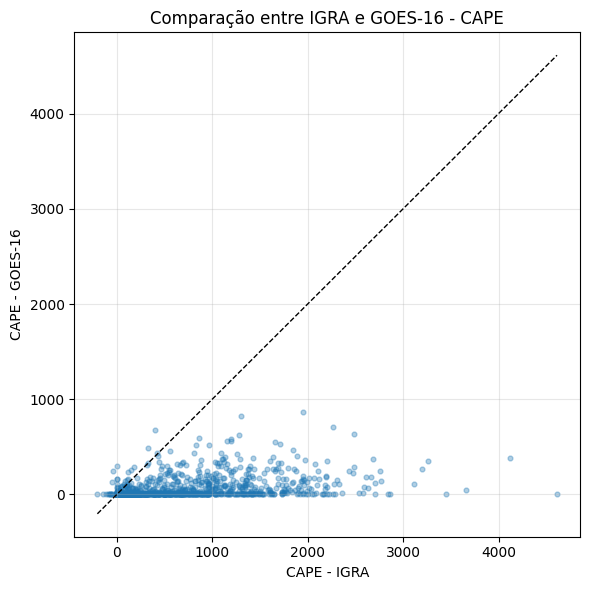

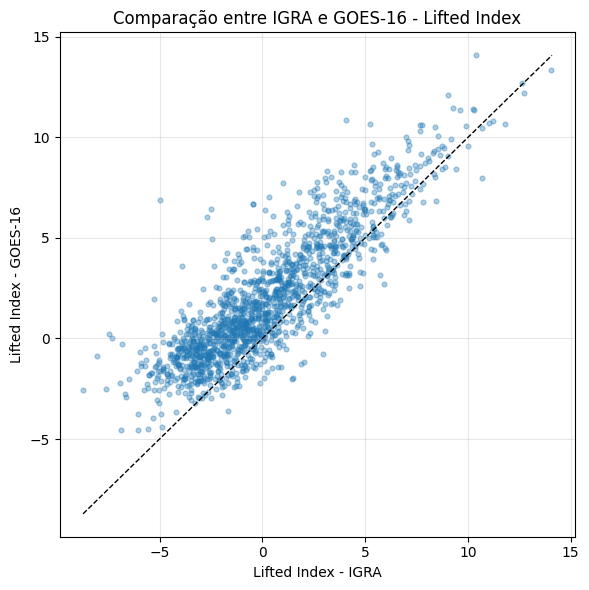

         mes        cape  sat_DSIF_CAPE  lifted_index  sat_DSIF_LI
0 2019-12-01  667.661605      80.653758     -0.653824     0.951902
1 2020-01-01  496.552048      27.184838      0.095418     0.939855
2 2020-02-01  450.891636      38.659439     -0.487141     0.740574
3 2020-03-01  270.313602       4.458603      0.787673     2.450960
4 2020-04-01   50.840445       2.123855      2.930127     4.047177


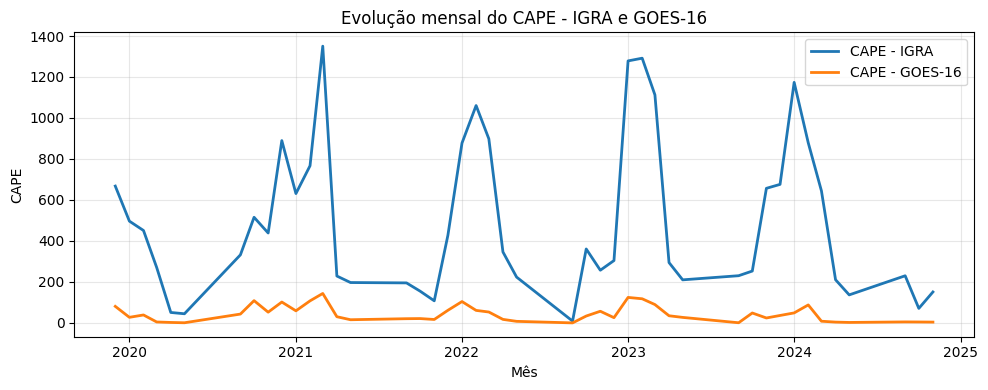

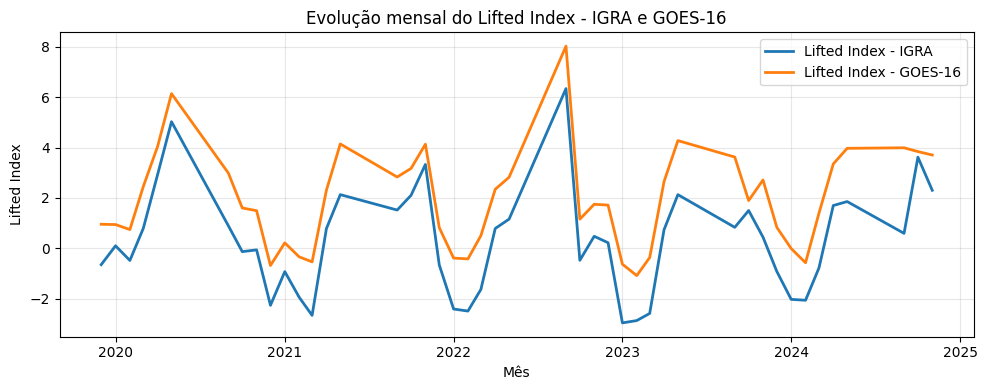

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

Path("figures").mkdir(exist_ok=True)

# ==================================================
# 1. LER IGRA ORIGINAL
# ==================================================

df_igra = pd.read_parquet(
    "data/as/BRM00083746_2012-01-01_2024-12-31_IGRA_LIMPO_INDICES.parquet.gzip"
)

df_igra["time"] = (
    pd.to_datetime(df_igra["time"])
    .dt.tz_localize(None)
)

# Uma linha por radiossondagem
igra_radio = (
    df_igra
    .groupby("time", as_index=False)
    [["cape", "lifted_index", "lat", "lon"]]
    .first()
)

# ==================================================
# 2. LER GOES-16 INTEGRADO COM WEBSIRENE
# ==================================================

df_goes = pd.read_parquet(
    "data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet"
)

df_goes["observation_datetime"] = (
    pd.to_datetime(df_goes["observation_datetime"])
    .dt.tz_localize(None)
)

# ==================================================
# 3. AGREGAR GOES POR HORÁRIO
# ==================================================
# Como o GOES está repetido por estação WebSirene,
# aqui usamos a média espacial dos pontos disponíveis no RJ.

goes_time = (
    df_goes
    .groupby("observation_datetime", as_index=False)
    [["sat_DSIF_CAPE", "sat_DSIF_LI"]]
    .mean()
)

# ==================================================
# 4. FILTRAR PERÍODO COMUM
# ==================================================

inicio = "2019-12-01"
fim = "2024-11-27"

igra_radio = igra_radio[
    (igra_radio["time"] >= inicio) &
    (igra_radio["time"] <= fim)
].copy()

goes_time = goes_time[
    (goes_time["observation_datetime"] >= inicio) &
    (goes_time["observation_datetime"] <= fim)
].copy()

# ==================================================
# 5. ALINHAR IGRA E GOES-16
# ==================================================
# Como o IGRA é 00/12 UTC e o GOES é horário,
# usamos merge_asof para pegar o GOES mais próximo.

igra_radio = igra_radio.sort_values("time")
goes_time = goes_time.sort_values("observation_datetime")

df_comp = pd.merge_asof(
    igra_radio,
    goes_time,
    left_on="time",
    right_on="observation_datetime",
    direction="nearest",
    tolerance=pd.Timedelta("1H")
)

df_comp = df_comp.dropna(
    subset=[
        "cape",
        "lifted_index",
        "sat_DSIF_CAPE",
        "sat_DSIF_LI"
    ]
).copy()

print("Pares válidos:", len(df_comp))
print(df_comp.head())

# ==================================================
# 6. MÉTRICAS DE CONCORDÂNCIA
# ==================================================

def metricas_concordancia(df, col_radio, col_sat, nome):
    erro = df[col_sat] - df[col_radio]

    return {
        "Índice": nome,
        "n": len(df),
        "Viés médio": erro.mean(),
        "MAE": mean_absolute_error(df[col_radio], df[col_sat]),
        "RMSE": np.sqrt(mean_squared_error(df[col_radio], df[col_sat])),
        "Correlação": df[[col_radio, col_sat]].corr().iloc[0, 1]
    }

resultados = pd.DataFrame([
    metricas_concordancia(
        df_comp,
        "cape",
        "sat_DSIF_CAPE",
        "CAPE"
    ),
    metricas_concordancia(
        df_comp,
        "lifted_index",
        "sat_DSIF_LI",
        "Lifted Index"
    )
])

print(resultados)

resultados.to_csv(
    "figures/concordancia_igra_goes_cape_li.csv",
    index=False
)

# ==================================================
# 7. GRÁFICOS DE DISPERSÃO
# ==================================================

def plot_dispersao(df, col_radio, col_sat, nome, arquivo):
    plt.figure(figsize=(6, 6))

    plt.scatter(
        df[col_radio],
        df[col_sat],
        alpha=0.35,
        s=12
    )

    minimo = min(df[col_radio].min(), df[col_sat].min())
    maximo = max(df[col_radio].max(), df[col_sat].max())

    plt.plot(
        [minimo, maximo],
        [minimo, maximo],
        linestyle="--",
        color="black",
        linewidth=1
    )

    plt.xlabel(f"{nome} - IGRA")
    plt.ylabel(f"{nome} - GOES-16")
    plt.title(f"Comparação entre IGRA e GOES-16 - {nome}")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"figures/{arquivo}", dpi=300)
    plt.show()

plot_dispersao(
    df_comp,
    "cape",
    "sat_DSIF_CAPE",
    "CAPE",
    "cape_igra_goes.png"
)

plot_dispersao(
    df_comp,
    "lifted_index",
    "sat_DSIF_LI",
    "Lifted Index",
    "li_igra_goes.png"
)

# ==================================================
# 8. EVOLUÇÃO MENSAL - CAPE E LIFTED INDEX
# ==================================================

df_mensal = df_comp.copy()

df_mensal["mes"] = df_mensal["time"].dt.to_period("M").dt.to_timestamp()

mensal = (
    df_mensal
    .groupby("mes", as_index=False)
    .agg({
        "cape": "mean",
        "sat_DSIF_CAPE": "mean",
        "lifted_index": "mean",
        "sat_DSIF_LI": "mean"
    })
)

print(mensal.head())

plt.figure(figsize=(10, 4))

plt.plot(
    mensal["mes"],
    mensal["cape"],
    label="CAPE - IGRA",
    linewidth=2
)

plt.plot(
    mensal["mes"],
    mensal["sat_DSIF_CAPE"],
    label="CAPE - GOES-16",
    linewidth=2
)

plt.xlabel("Mês")
plt.ylabel("CAPE")
plt.title("Evolução mensal do CAPE - IGRA e GOES-16")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("figures/cape_mensal_igra_goes.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(
    mensal["mes"],
    mensal["lifted_index"],
    label="Lifted Index - IGRA",
    linewidth=2
)

plt.plot(
    mensal["mes"],
    mensal["sat_DSIF_LI"],
    label="Lifted Index - GOES-16",
    linewidth=2
)

plt.xlabel("Mês")
plt.ylabel("Lifted Index")
plt.title("Evolução mensal do Lifted Index - IGRA e GOES-16")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("figures/li_mensal_igra_goes.png", dpi=300)
plt.show()

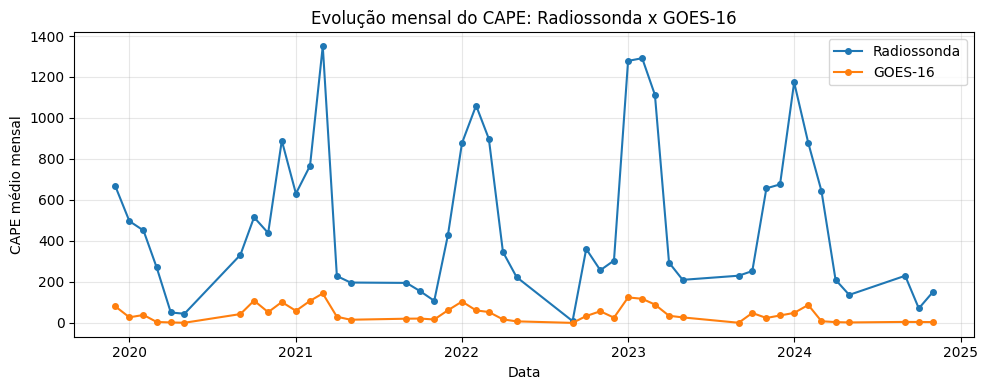

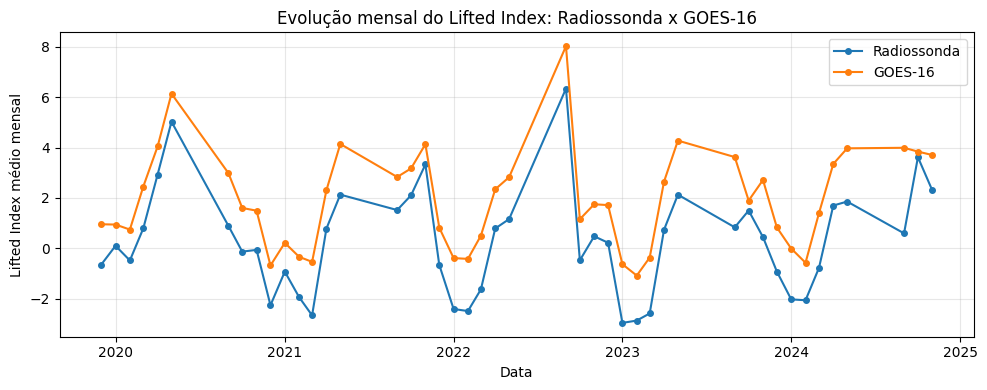

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# df_comp já deve existir com colunas:
# time, cape, sat_DSIF_CAPE, lifted_index, sat_DSIF_LI
# ============================================

# Garantir datetime
df_comp["time"] = pd.to_datetime(df_comp["time"])

# Criar coluna de mês
df_mensal = df_comp.copy()
df_mensal["mes"] = df_mensal["time"].dt.to_period("M").dt.to_timestamp()

# Agregar média mensal
mensal = (
    df_mensal
    .groupby("mes", as_index=False)
    .agg({
        "cape": "mean",
        "sat_DSIF_CAPE": "mean",
        "lifted_index": "mean",
        "sat_DSIF_LI": "mean"
    })
)

# ============================================
# GRÁFICO 1 - CAPE com pontos
# ============================================
plt.figure(figsize=(10, 4))

plt.plot(
    mensal["mes"],
    mensal["cape"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Radiossonda"
)

plt.plot(
    mensal["mes"],
    mensal["sat_DSIF_CAPE"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="GOES-16"
)

plt.title("Evolução mensal do CAPE: Radiossonda x GOES-16")
plt.xlabel("Data")
plt.ylabel("CAPE médio mensal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures/cape_mensal_pontos.png", dpi=300)
plt.show()

# ============================================
# GRÁFICO 2 - Lifted Index com pontos
# ============================================
plt.figure(figsize=(10, 4))

plt.plot(
    mensal["mes"],
    mensal["lifted_index"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Radiossonda"
)

plt.plot(
    mensal["mes"],
    mensal["sat_DSIF_LI"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="GOES-16"
)

plt.title("Evolução mensal do Lifted Index: Radiossonda x GOES-16")
plt.xlabel("Data")
plt.ylabel("Lifted Index médio mensal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures/li_mensal_pontos.png", dpi=300)
plt.show()

WebSirene (recorte GOES-16)
AUC calculada pela curva: 0.6992889754030512
AUC da tabela:           0.6992889754030512
Diferença:               0.0

GOES-16
AUC calculada pela curva: 0.8797991182569597
AUC da tabela:           0.8797991182569597
Diferença:               0.0

GOES-16 + WebSirene
AUC calculada pela curva: 0.9404512344678152
AUC da tabela:           0.9404512344678152
Diferença:               0.0



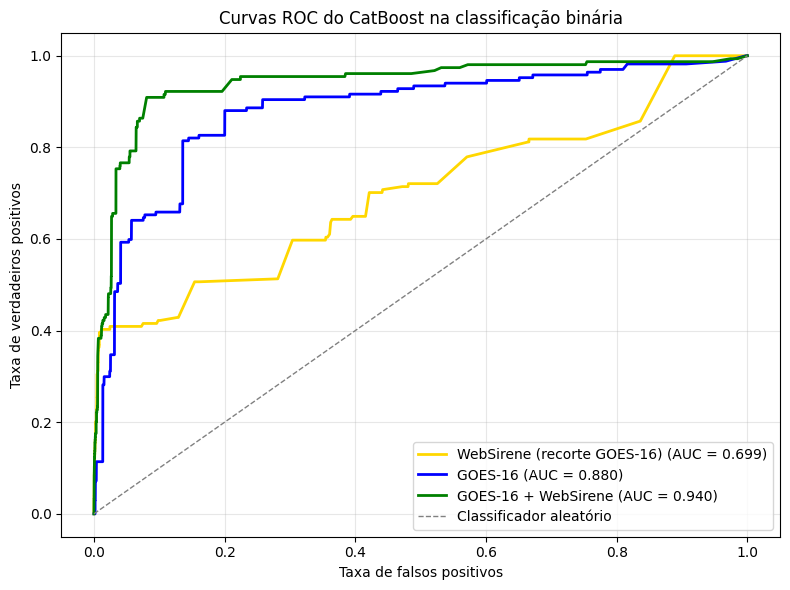

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score

Path("figures").mkdir(parents=True, exist_ok=True)

arquivos = {
    "WebSirene (recorte GOES-16)": {
        "caminho": "resultados_roc/roc_websirene_recorte_goes_catboost.npz",
        "auc_tabela": 0.6992889754030512
    },
    "GOES-16": {
        "caminho": "resultados_roc/roc_goes16_catboost.npz",
        "auc_tabela": 0.8797991182569597
    },
    "GOES-16 + WebSirene": {
        "caminho": "resultados_roc/roc_goes16_websirene_catboost.npz",
        "auc_tabela": 0.9404512344678152
    }
}

cores = {
    "WebSirene (recorte GOES-16)": "gold",
    "GOES-16": "blue",
    "GOES-16 + WebSirene": "green"
}

plt.figure(figsize=(8, 6))

for nome, info in arquivos.items():
    dados = np.load(info["caminho"])

    y_test = dados["y_test"]
    y_prob = dados["y_prob"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_real = roc_auc_score(y_test, y_prob)
    auc_tabela = info["auc_tabela"]

    print(f"{nome}")
    print(f"AUC calculada pela curva: {auc_real}")
    print(f"AUC da tabela:           {auc_tabela}")
    print(f"Diferença:               {abs(auc_real - auc_tabela)}")
    print()

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        color=cores[nome],
        label=f"{nome} (AUC = {auc_tabela:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    color="gray",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curvas ROC do CatBoost na classificação binária")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/roc_catboost_goes16_binario.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()